### Laboratorio 1 -- Series de Tiempo
**Análisis exploratorio — incisos d, e, f**

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# El archivo .xlsx es realmente un CSV
df = pd.read_csv("./df/Base_Migracion_2009-2026jun.csv")
df['Viajero'] = pd.to_numeric(df['Viajero'], errors='coerce')

# Subconjunto consistente para todo el período 2009-2026
# entre 2022-2023 la categoría 'Viajero' excluyó viajeros no turísticos de alta frecuencia
# (comercio fronterizo, tránsito), por lo que solo Turista + Excursionista son comparables
df_te = df[df['Tipo de Viajero'].isin(['Turista', 'Excursionista'])].copy()

print(f"Total filas: {len(df)}, Turista+Excursionista: {len(df_te)}")
df.head(3)


Total filas: 161036, Turista+Excursionista: 137642


,Año,Mes cod,Mes,Vía,Frontera,País,Región,Región dos,Regiones OMT,MCEO,Agrupación Residencia,Tipo de Viajero,Viajero
0,2009,1,Ene,Aérea,01 La Aurora,Albania,OTROS EUROPEOS,Europa,EUROPA MERIDIONAL,08 OTROS,Europa,Turista,1.0
1,2009,1,Ene,Aérea,01 La Aurora,Alemania,EUROPA,Europa,EUROPA OCCIDENTAL,04 EUROPA,Europa,Turista,716.0
2,2009,1,Ene,Aérea,01 La Aurora,Angola,OTROS PAISES DEL MUNDO,Otros Paises Del Mundo,ÁFRICA CENTRAL,08 OTROS,Resto del Mundo,Turista,4.0


### a,b,c) comportamiento temporal del número de viajeros, países con mayor cantidad de viajeros. regiones con mayor cantidad de viajeros


=== INFORMACIÓN GENERAL ===
----------------------------------------------------------------------
Dimensiones: 161036 filas × 13 columnas
Años: 2009 - 2026
Tipos de viajero: ['Turista', 'Cruceristas', 'Viajero', 'Excursionista']

Tipos de df:
Año                        int64
Mes cod                    int64
Mes                          str
Vía                          str
Frontera                     str
País                         str
Región                       str
Región dos                   str
Regiones OMT                 str
MCEO                         str
Agrupación Residencia        str
Tipo de Viajero              str
Viajero                  float64
dtype: object

Valores nulos por columna:
Año                      0
Mes cod                  0
Mes                      0
Vía                      0
Frontera                 0
País                     0
Región                   0
Región dos               0
Regiones OMT             0
MCEO                     0
Agrupación Res

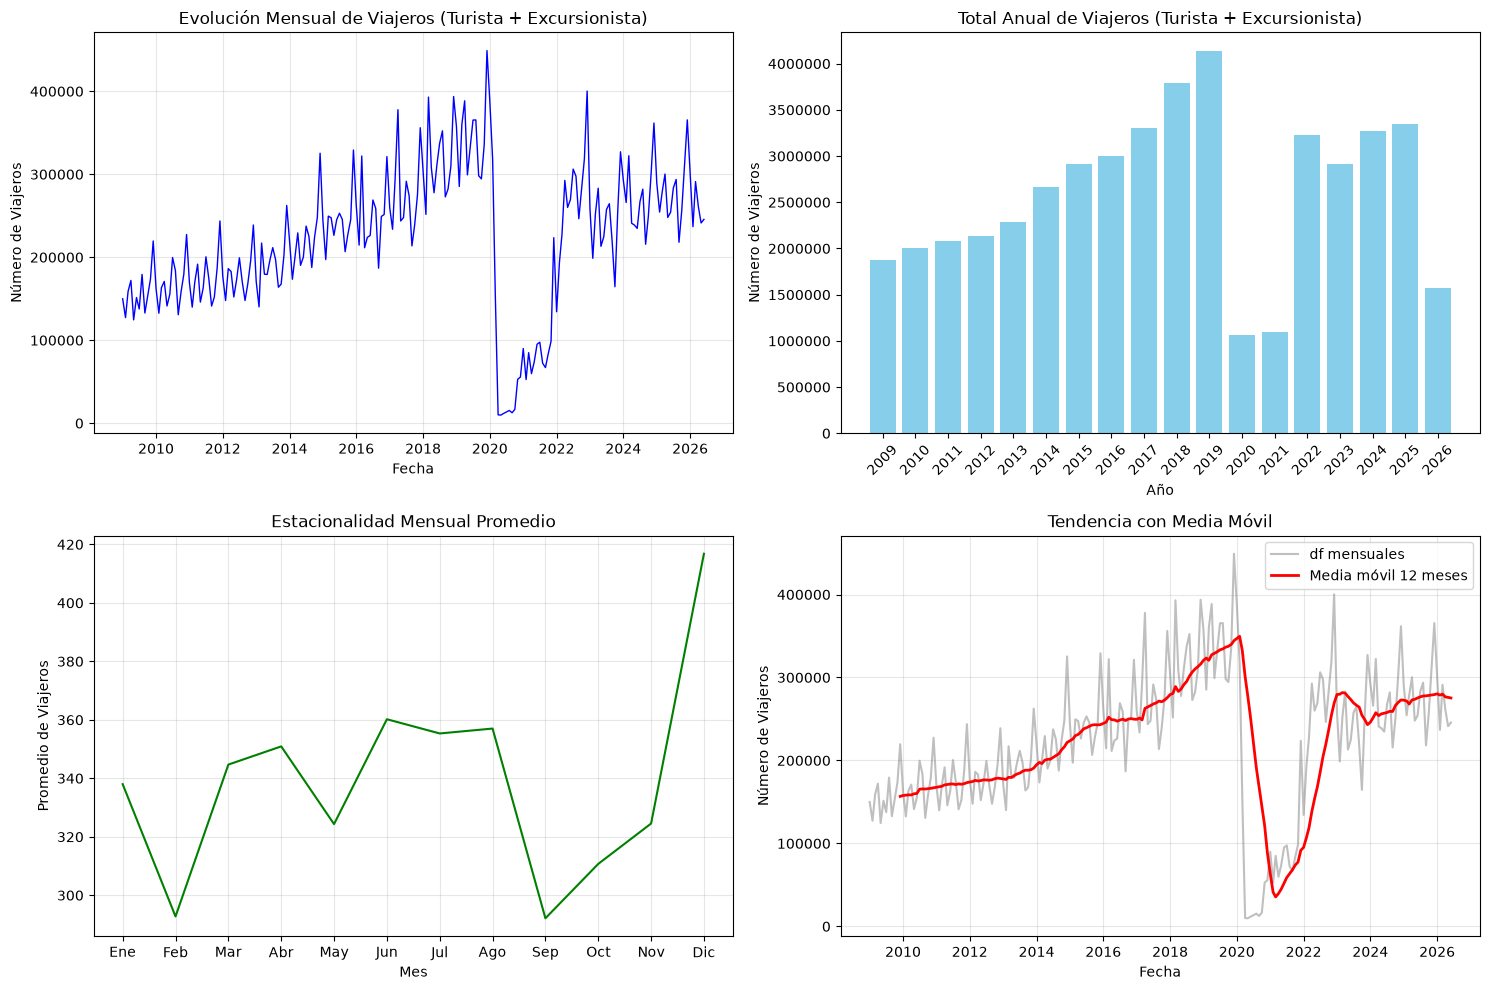

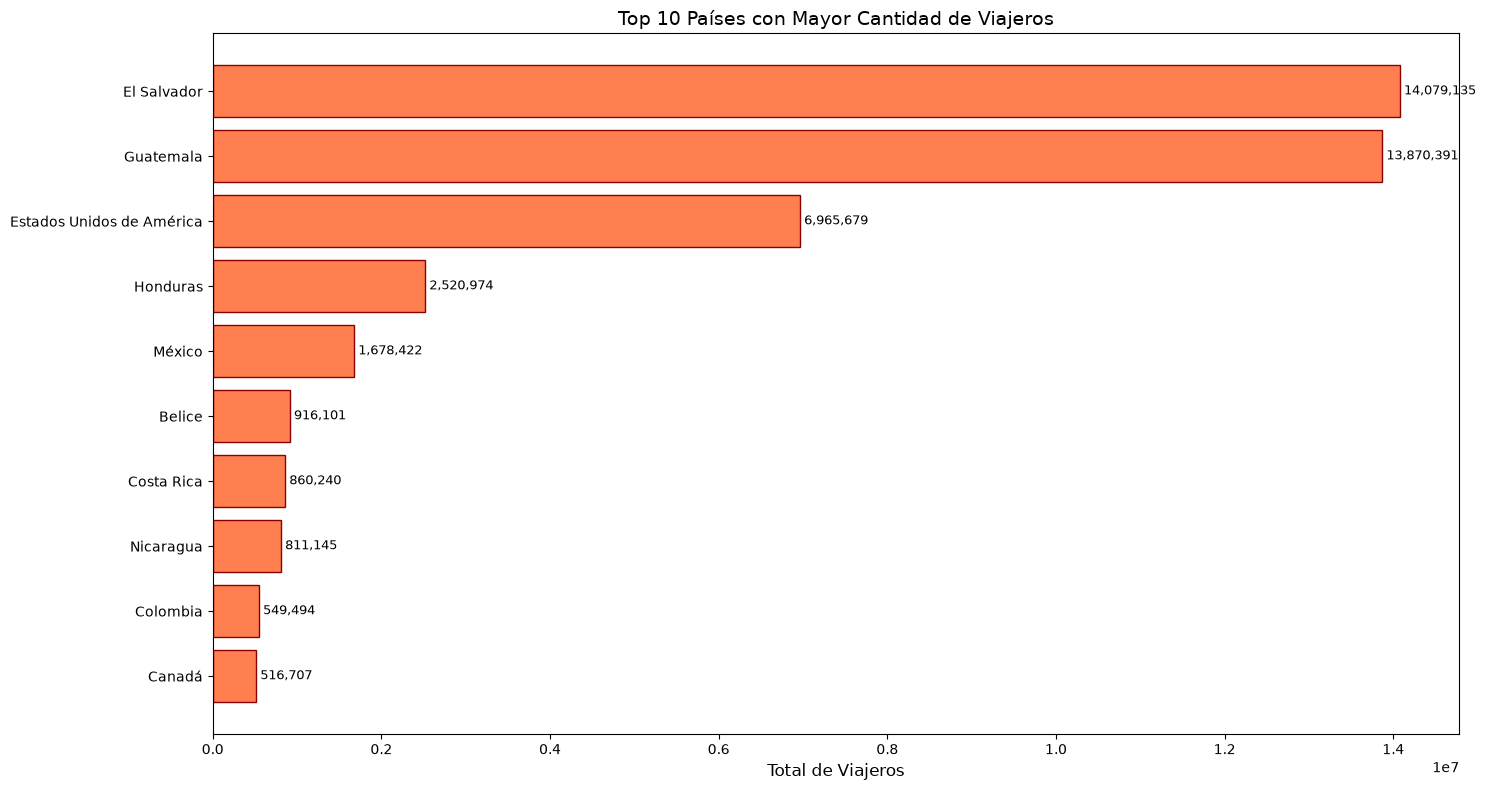

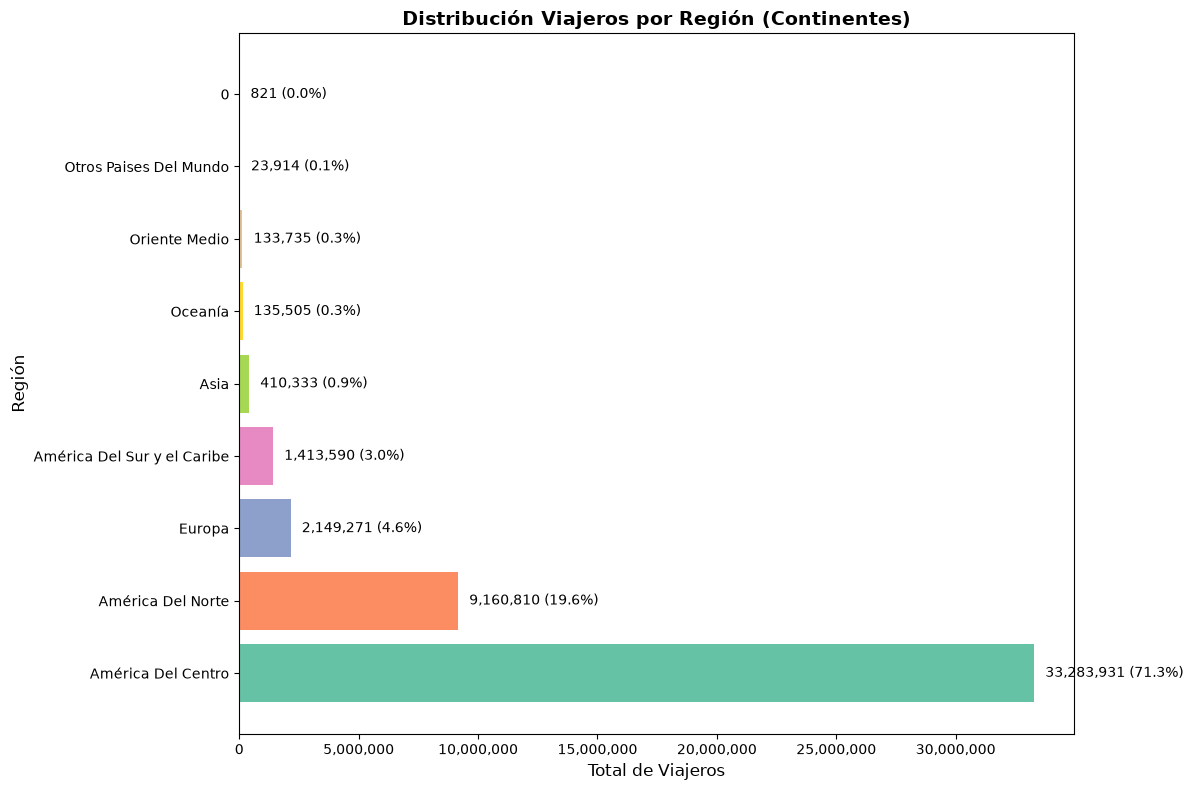

In [3]:
#EXPLORACION INICIAL

print("\n=== INFORMACIÓN GENERAL ===")
print("-"*70)
print(f"Dimensiones: {df.shape[0]} filas × {df.shape[1]} columnas")
print(f"Años: {df['Año'].min()} - {df['Año'].max()}")
print(f"Tipos de viajero: {df['Tipo de Viajero'].unique().tolist()}")

print("\nTipos de df:")
print(df.dtypes)

print("\nValores nulos por columna:")
print(df.isnull().sum())

print("Estadistica descriptiva viajeros:")
print(df['Viajero'].describe().apply(lambda x: f'{x:,.0f}'))

print("Categorías únicas:")
print(f"Vias: {df['Vía'].unique()}")
print(f"Tipos de viajero: {df['Tipo de Viajero'].unique()}")
print(f"Años: {df['Año'].unique()}")


#a. comportamiento temporal del número de viajeros
df_filtracion = df[df['Tipo de Viajero'].isin(['Turista', 'Excursionista'])].copy()
df_filtracion['Fecha'] = pd.to_datetime(df_filtracion['Año'].astype(str) + '-' + df_filtracion['Mes cod'].astype(str)+'-01')

#tendencias: mensual y anual
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

mensual = df_filtracion.groupby('Fecha')['Viajero'].sum()
axes[0, 0].plot(mensual.index, mensual.values, color='blue', linewidth=1)
axes[0, 0].set_title('Evolución Mensual de Viajeros (Turista + Excursionista)', fontsize=12)
axes[0, 0].set_xlabel('Fecha')
axes[0, 0].set_ylabel('Número de Viajeros')
axes[0, 0].grid(True, alpha=0.3)

anual = df_filtracion.groupby('Año')['Viajero'].sum()
anual.index = anual.index.astype(int)
axes[0, 1].bar(anual.index, anual.values, color='skyblue')
axes[0, 1].set_title('Total Anual de Viajeros (Turista + Excursionista)', fontsize=12)
axes[0, 1].set_xlabel('Año')
axes[0, 1].set_ylabel('Número de Viajeros')
axes[0, 1].set_xticks(anual.index)
axes[0, 1].set_xticklabels(anual.index, rotation=45)
axes[0, 1].ticklabel_format(style='plain', axis='y', useOffset=False)
axes[0, 1].yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: format(int(x))))

estacionalidad = df_filtracion.groupby('Mes')['Viajero'].mean()
meses_orden = ['Ene', 'Feb', 'Mar', 'Abr', 'May', 'Jun', 'Jul', 'Ago', 'Sep', 'Oct', 'Nov', 'Dic']
estacionalidad = estacionalidad.reindex(meses_orden)
axes[1, 0].plot(estacionalidad.index, estacionalidad.values, color='green')
axes[1, 0].set_title('Estacionalidad Mensual Promedio', fontsize=12)
axes[1, 0].set_xlabel('Mes')
axes[1, 0].set_ylabel('Promedio de Viajeros')
axes[1, 0].grid(True, alpha=0.3)

media_movil = mensual.rolling(window=12).mean()
axes[1, 1].plot(mensual.index, mensual.values, color='gray', alpha=0.5, label='df mensuales')
axes[1, 1].plot(media_movil.index, media_movil.values, color='red', linewidth=2, label='Media móvil 12 meses')
axes[1, 1].set_title('Tendencia con Media Móvil', fontsize=12)
axes[1, 1].set_xlabel('Fecha')
axes[1, 1].set_ylabel('Número de Viajeros')
axes[1, 1].legend()
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

#b. países con mayor cantidad de viajeros
top_paises = df_filtracion.groupby('País')['Viajero'].sum().sort_values(ascending=False).head(10)
fig, ax = plt.subplots(figsize=(15, 8))
bars = ax.barh(top_paises.index, top_paises.values, color='coral', edgecolor='darkred')
ax.set_title('Top 10 Países con Mayor Cantidad de Viajeros', fontsize=14)
ax.set_xlabel('Total de Viajeros', fontsize=12)
ax.invert_yaxis()

for i, (bar, value) in enumerate(zip(bars, top_paises.values)):
    ax.text(value, bar.get_y() + bar.get_height()/2, 
            f' {int(value):,}', va='center', ha='left', fontsize=9)

plt.tight_layout()
plt.show()

#c. regiones con mayor cantidad de viajeros
top_regiones = df_filtracion.groupby('Región dos')['Viajero'].sum().sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(12, 8))

bars = ax.barh(top_regiones.index, top_regiones.values, color=plt.cm.Set2(np.linspace(0, 1, len(top_regiones))))

total = top_regiones.sum()
for i, (bar, value) in enumerate(zip(bars, top_regiones.values)):
    pct = (value / total) * 100
    ax.text(value + (total * 0.01), bar.get_y() + bar.get_height()/2,
            f'{int(value):,} ({pct:.1f}%)',
            va='center', ha='left', fontsize=10)

ax.set_title('Distribución Viajeros por Región (Continentes)', fontsize=14, weight='bold')
ax.set_xlabel('Total de Viajeros', fontsize=12)
ax.set_ylabel('Región', fontsize=12)
ax.ticklabel_format(style='plain', axis='x')
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: format(int(x), ',')))

plt.tight_layout()
plt.show()

### d) Vías de ingreso y fronteras más utilizadas

=== VÍAS DE INGRESO ===
Vía
Terrestre    125873
Aérea         24999
Marítima      10164
Name: count, dtype: int64

Porcentajes:
Vía
Terrestre    78.16
Aérea        15.52
Marítima      6.31
Name: count, dtype: float64


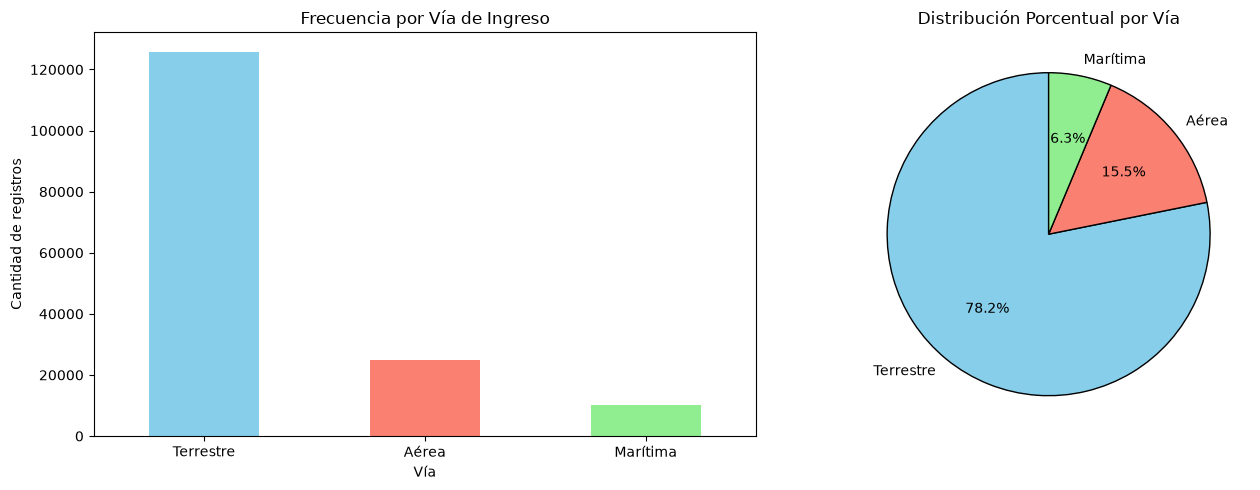

In [4]:
# Vías de ingreso
vias = df['Vía'].value_counts()
print("=== VÍAS DE INGRESO ===")
print(vias)
print(f"\nPorcentajes:\n{(vias / vias.sum() * 100).round(2)}")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

vias.plot(kind='bar', ax=axes[0], color=['skyblue', 'salmon', 'lightgreen'])
axes[0].set_title('Frecuencia por Vía de Ingreso')
axes[0].set_ylabel('Cantidad de registros')
axes[0].tick_params(axis='x', rotation=0)

vias.plot(kind='pie', ax=axes[1], autopct='%1.1f%%', startangle=90,
          colors=['skyblue', 'salmon', 'lightgreen'], wedgeprops={'edgecolor': 'black'})
axes[1].set_title('Distribución Porcentual por Vía')
axes[1].set_ylabel('')

plt.tight_layout()
plt.show()

=== TOP 10 FRONTERAS MÁS UTILIZADAS ===

Frontera
01 La Aurora                   21424
07 Valle Nuevo                 13737
20 Melchor de Mencos           12242
08 Pedro de Alvarado           11558
12 El Florido                  11207
15 El Carmen                   10380
13 El Cinchado / El Corinto    10377
16 La Mesilla                   9776
14 Tecún Umán                   9445
09 San Cristóbal                9067
Name: count, dtype: int64

Porcentaje acumulado top 5: 43.57%


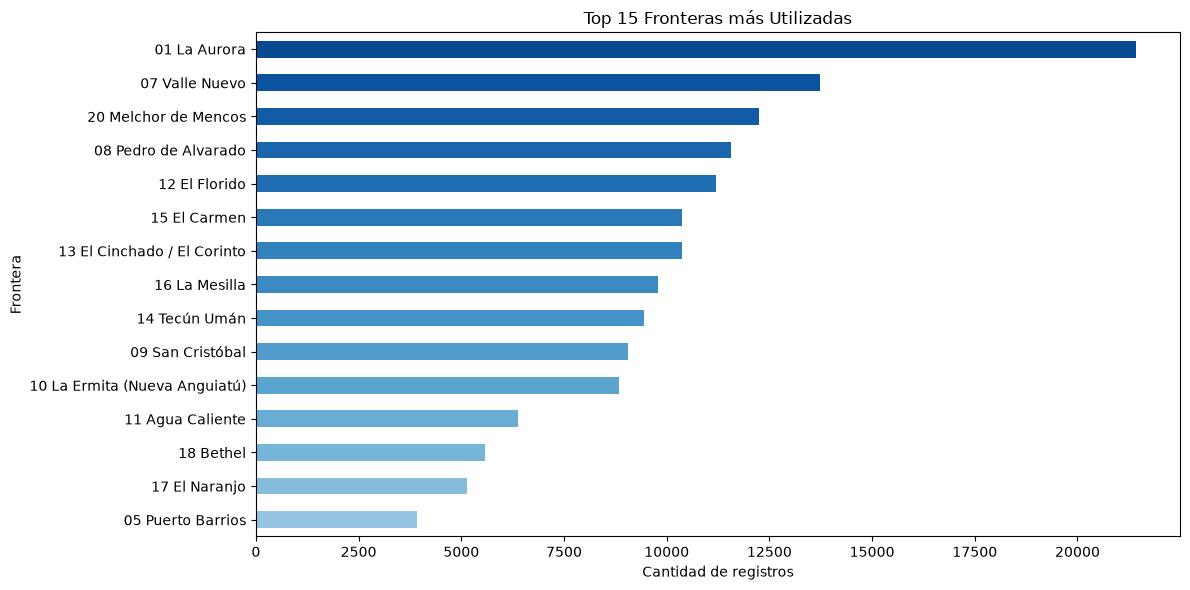

In [5]:
# Fronteras más utilizadas
fronteras = df['Frontera'].value_counts()
print("=== TOP 10 FRONTERAS MÁS UTILIZADAS ===\n")
print(fronteras.head(10))
print(f"\nPorcentaje acumulado top 5: {(fronteras.head(5).sum() / fronteras.sum() * 100).round(2)}%")

plt.figure(figsize=(12, 6))
top15 = fronteras.head(15)
colors = plt.cm.Blues(np.linspace(0.4, 0.9, 15))
top15.plot(kind='barh', color=colors[::-1])
plt.title('Top 15 Fronteras más Utilizadas')
plt.xlabel('Cantidad de registros')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()


**Interpretación:**

- La vía **terrestre** domina ampliamente (78.2% de los registros), seguida de aérea (15.5%) y marítima (6.3%).
- '01 La Aurora' (aeropuerto) es la frontera individual con más registros, pero las fronteras terrestres (Valle Nuevo, Melchor de Mencos, Pedro de Alvarado, El Florido) le siguen de cerca.
- Las 5 fronteras principales concentran ~46% del total de registros.


### e) Análisis de valores faltantes, duplicados y valores atípicos

=== VALORES FALTANTES ===
No hay valores faltantes en ninguna columna.

=== DUPLICADOS ===
Filas exactamente duplicadas: 0

=== VALORES ATÍPICOS (Viajero) ===
Q1 = 2.00, Q3 = 38.89, IQR = 36.89
Límite inferior = -53.34, Límite superior = 94.23
Registros atípicos: 26390 (16.39% del total)


C:\Users\abbyd\AppData\Local\Temp\ipykernel_20360\900652176.py:28: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  axes[0].boxplot(df['Viajero'].clip(upper=df['Viajero'].quantile(0.99)), vert=False)


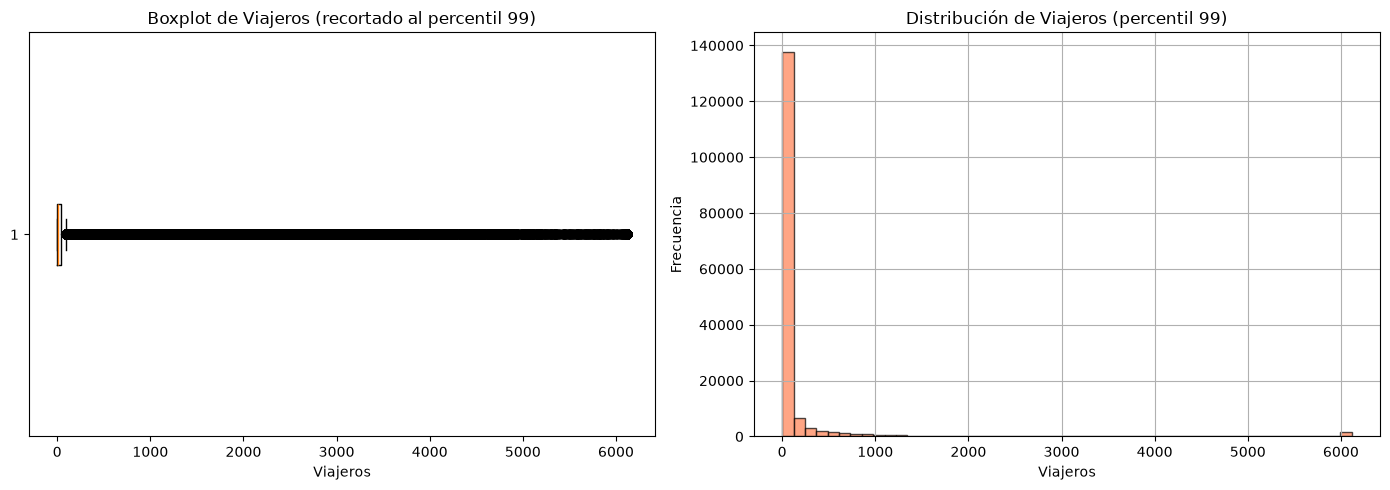

In [6]:
# Valores faltantes
print("=== VALORES FALTANTES ===")
missing = df.isnull().sum()
missing_pct = (df.isnull().sum() / len(df) * 100).round(4)
missing_info = pd.DataFrame({'Faltantes': missing, 'Porcentaje': missing_pct})
print(missing_info[missing_info['Faltantes'] > 0] if missing.sum() > 0 else "No hay valores faltantes en ninguna columna.")

# Duplicados
dups = df.duplicated().sum()
print(f"\n=== DUPLICADOS ===")
print(f"Filas exactamente duplicadas: {dups}")

# Valores atípicos en Viajero (IQR)
print(f"\n=== VALORES ATÍPICOS (Viajero) ===")
Q1 = df['Viajero'].quantile(0.25)
Q3 = df['Viajero'].quantile(0.75)
IQR = Q3 - Q1
lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR
outliers = df[(df['Viajero'] < lower) | (df['Viajero'] > upper)]
print(f"Q1 = {Q1:.2f}, Q3 = {Q3:.2f}, IQR = {IQR:.2f}")
print(f"Límite inferior = {lower:.2f}, Límite superior = {upper:.2f}")
print(f"Registros atípicos: {len(outliers)} ({len(outliers)/len(df)*100:.2f}% del total)")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Boxplot
axes[0].boxplot(df['Viajero'].clip(upper=df['Viajero'].quantile(0.99)), vert=False)
axes[0].set_title('Boxplot de Viajeros (recortado al percentil 99)')
axes[0].set_xlabel('Viajeros')

# Histograma
df['Viajero'].clip(upper=df['Viajero'].quantile(0.99)).hist(bins=50, ax=axes[1],
    color='coral', edgecolor='black', alpha=0.7)
axes[1].set_title('Distribución de Viajeros (percentil 99)')
axes[1].set_xlabel('Viajeros')
axes[1].set_ylabel('Frecuencia')

plt.tight_layout()
plt.show()

**Interpretación:**

- El conjunto de df **no presenta valores faltantes ni filas duplicadas**, indicando que la base está completa y limpia.
- Sin embargo, ~16.4% de los registros se identifican como **valores atípicos** en 'Viajero' según el criterio IQR. Esto es esperable en df de migración: ciertas rutas/fronteras concentran volúmenes muy superiores al promedio.
- La distribución está **fuertemente sesgada a la derecha**: la mayoría de observaciones tienen pocos viajeros (mediana = 7), pero existen picos muy altos que elevan la media a ~325.


### f) Estadísticas descriptivas y visualizaciones con interpretación

In [7]:
# Estadisticas descriptivas
print("=== ESTADÍSTICAS DESCRIPTIVAS (variable Viajero) ===")
desc = df['Viajero'].describe()
print(desc)
print(f"\nVarianza: {df['Viajero'].var():.2f}")
print(f"Sesgo (skewness): {df['Viajero'].skew():.2f}")
print(f"Curtosis: {df['Viajero'].kurtosis():.2f}")

# Estadísticas por vía de ingreso
print("\n=== ESTADÍSTICAS POR VÍA DE INGRESO ===")
print(df.groupby('Vía')['Viajero'].describe().round(2))

# Estadísticas por tipo de viajero
print("\n=== ESTADÍSTICAS POR TIPO DE VIAJERO ===")
print(df.groupby('Tipo de Viajero')['Viajero'].describe().round(2))

=== ESTADÍSTICAS DESCRIPTIVAS (variable Viajero) ===
count    161036.000000
mean        324.697193
std        2387.745140
min           0.000000
25%           2.000000
50%           7.000000
75%          38.891667
max       92336.035067
Name: Viajero, dtype: float64

Varianza: 5701326.85
Sesgo (skewness): 15.44
Curtosis: 298.01

=== ESTADÍSTICAS POR VÍA DE INGRESO ===
              count    mean      std  min  25%   50%     75%       max
Vía                                                                   
Aérea       24999.0  762.58  4589.39  0.0  2.0  7.00  125.00  83511.00
Marítima    10164.0  120.90   964.98  1.0  1.0  3.00   11.00  21680.93
Terrestre  125873.0  254.19  1729.00  0.0  2.0  7.44   36.85  92336.04

=== ESTADÍSTICAS POR TIPO DE VIAJERO ===
                    count     mean      std   min     25%      50%      75%  \
Tipo de Viajero                                                               
Cruceristas         204.0  5413.74  4225.76  85.0  2094.0  4454.91  7173.5

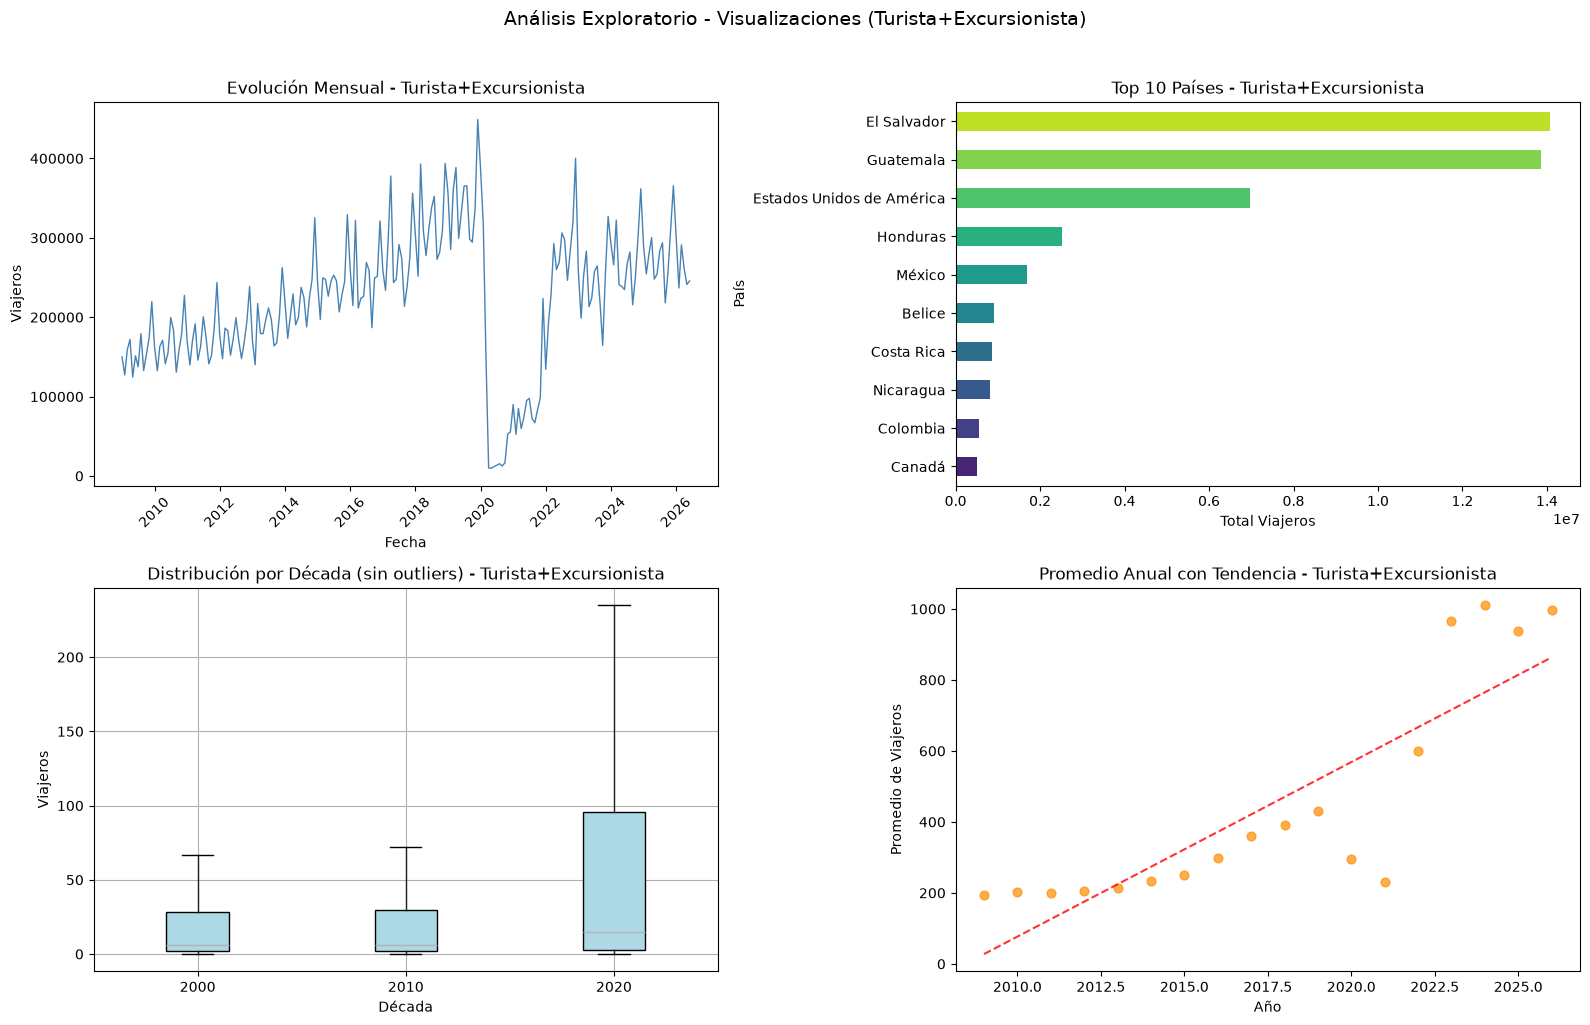

In [8]:
# Visualizaciones (usando Turista+Excursionista para consistencia longitudinal)
fig, axes = plt.subplots(2, 2, figsize=(16, 10))

# 1. Serie de tiempo mensual (Turista+Excursionista)
serie = df_te.groupby(['Año', 'Mes cod'])['Viajero'].sum().reset_index()
serie['fecha'] = pd.to_datetime(serie['Año'].astype(str) + '-' + serie['Mes cod'].astype(str))
serie = serie.sort_values('fecha')
axes[0, 0].plot(serie['fecha'], serie['Viajero'], color='steelblue', linewidth=1)
axes[0, 0].set_title('Evolución Mensual - Turista+Excursionista')
axes[0, 0].set_xlabel('Fecha')
axes[0, 0].set_ylabel('Viajeros')
axes[0, 0].tick_params(axis='x', rotation=45)

# 2. Top 10 países (Turista+Excursionista)
top_paises = df_te.groupby('País')['Viajero'].sum().sort_values(ascending=False).head(10)
colors = plt.cm.viridis(np.linspace(0.1, 0.9, 10))
top_paises.plot(kind='barh', ax=axes[0, 1], color=colors[::-1])
axes[0, 1].set_title('Top 10 Países - Turista+Excursionista')
axes[0, 1].set_xlabel('Total Viajeros')
axes[0, 1].invert_yaxis()

# 3. Distribución por década (Turista+Excursionista)
df_te['década'] = (df_te['Año'] // 10) * 10
df_te.boxplot(column='Viajero', by='década', ax=axes[1, 0],
              showfliers=False, patch_artist=True,
              boxprops=dict(facecolor='lightblue'))
axes[1, 0].set_title('Distribución por Década (sin outliers) - Turista+Excursionista')
axes[1, 0].set_xlabel('Década')
axes[1, 0].set_ylabel('Viajeros')

# 4. Promedio anual (Turista+Excursionista)
anual = df_te.groupby('Año')['Viajero'].mean()
axes[1, 1].scatter(anual.index, anual.values, color='darkorange', alpha=0.7, s=40)
z = np.polyfit(anual.index, anual.values, 1)
p = np.poly1d(z)
axes[1, 1].plot(anual.index, p(anual.index), 'r--', alpha=0.8)
axes[1, 1].set_title('Promedio Anual con Tendencia - Turista+Excursionista')
axes[1, 1].set_xlabel('Año')
axes[1, 1].set_ylabel('Promedio de Viajeros')

plt.suptitle('Análisis Exploratorio - Visualizaciones (Turista+Excursionista)', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()


**Interpretación general:**

1. La **serie de tiempo** (Turista+Excursionista) muestra una tendencia creciente sostenida entre 2009-2026, con una caída abrupta en 2020 (COVID-19) y recuperación posterior.
2. La distribución es altamente asimétrica (sesgo positivo): la mayoría de registros tienen valores bajos, con concentraciones masivas en ciertas rutas.
3. La **vía terrestre** es predominante (~78%), reflejando la geografía regional con fronteras porosas y alto tránsito vehicular.
4. '01 La Aurora' (aeropuerto) lidera en registros individuales, pero las fronteras terrestres en conjunto concentran el mayor volumen.
5. **Nota sobre la categoría 'Viajero':** Entre 2022-2023 se excluyó a viajeros no turísticos de alta frecuencia (comercio fronterizo, tránsito) de esta categoría. Por eso los totales que incluyen 'Viajero' muestran una caída artificial en 2023. Los análisis longitudinales usan **Turista + Excursionista**, que sí son consistentes en todo el período.


## Division entrenamiento y prueba

In [9]:
#ENTRENAMIENTO Y PRUEBA
df_filtracion = df_filtracion.sort_values('Fecha').reset_index(drop=True)

train_size = int(len(df_filtracion)*0.7)
train_df = df_filtracion.iloc[:train_size] #70%
test_df = df_filtracion.iloc[train_size:] #30%

print("=== DIVISION DE DATOS ===")
print(f"Datos entrenamiento: {len(train_df)} ({len(train_df)/len(df_filtracion)*100:.1f}%)")
print(f"Datos prueba: {len(test_df)} ({len(test_df)/len(df_filtracion)*100:.1f}%)")


=== DIVISION DE DATOS ===
Datos entrenamiento: 96349 (70.0%)
Datos prueba: 41293 (30.0%)


## SERIES DE TIEMPO

In [10]:
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.stattools import adfuller, acf, pacf
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.holtwinters import ExponentialSmoothing
from statsmodels.tsa.arima.model import ARIMAResults
from sklearn.metrics import mean_absolute_error, mean_squared_error
from pmdarima import auto_arima

=== PAISES CON MAYOR NUMERO ACUMULADO DE VIAJEROS ===
Top 3 paises con mas viajeros:
   1- El Salvador (14,079,136)
   2- Guatemala (13,870,391)
   3- Estados Unidos de América (6,965,680)

=== SERIES DE PAISES CON MAYOR NUMERO DE VIAJEROS ===

»» El Salvador
  + Rango: 2009-01-01 00:00:00 -- 2026-06-01 00:00:00
  + Frecuencia: <MonthBegin>
  + No. observaciones: 210
  + Observaciones completas: 210
  + Periodos sin datos: 5

»» Guatemala
  + Rango: 2009-01-01 00:00:00 -- 2026-06-01 00:00:00
  + Frecuencia: <MonthBegin>
  + No. observaciones: 210
  + Observaciones completas: 210
  + Periodos sin datos: 42

»» Estados Unidos de América
  + Rango: 2009-01-01 00:00:00 -- 2026-06-01 00:00:00
  + Frecuencia: <MonthBegin>
  + No. observaciones: 210
  + Observaciones completas: 210
  + Periodos sin datos: 5

ANALISIS DE SERIE DE TIEMPO: El Salvador
=== INICIO, FIN Y FRECUENCIA ===
 - Inicio: 2009-01-01 00:00:00
 - Fin: 2026-06-01 00:00:00
 - Frecuencia: <MonthBegin>
 - No. observaciones: 210


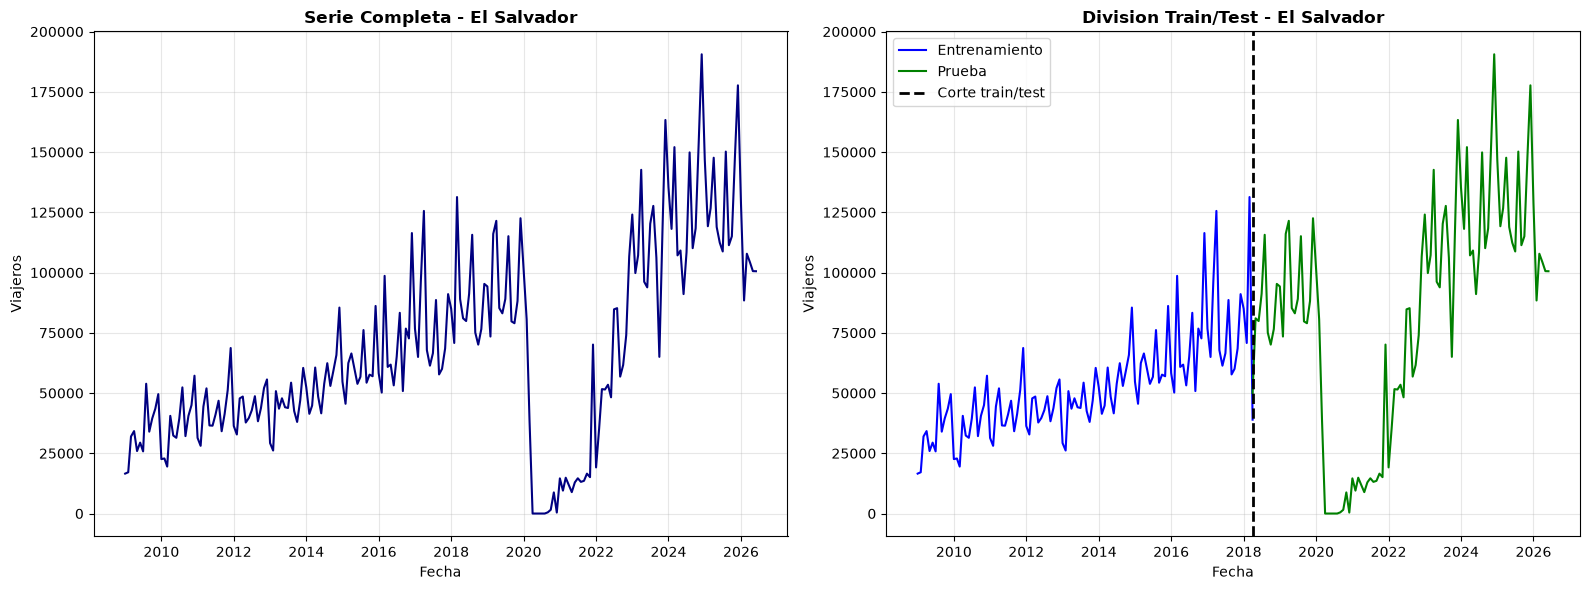

=== DESCOMPOSICION DE SERIE ===


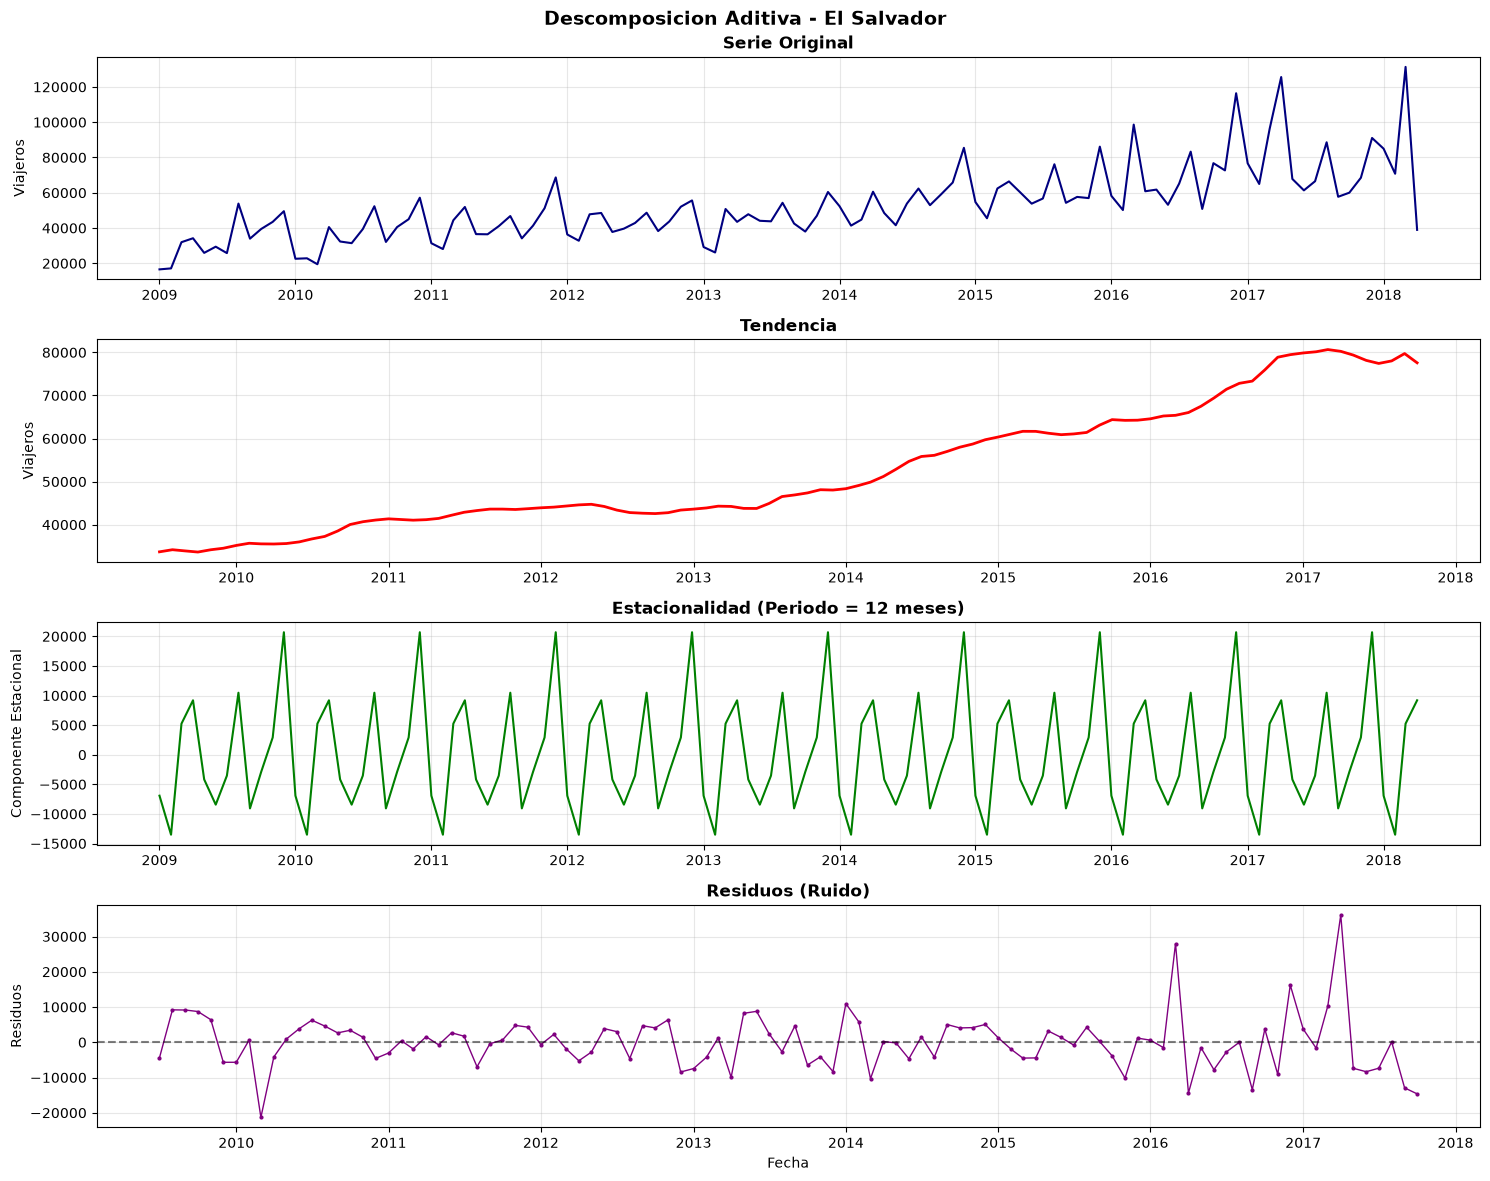

- Estacionariedad en media:
   Si la tendencia es creciente o decreciente =  la media cambia con el tiempo

- Estacionariedad en varianza:
   Residuos tienen varianza relativamente estable, serie puede ser estacionaria en varianza
=== DETERMINACION SI TRANSFORMACION NECESARIA ===
Correlacion entre media y varianza: 0.804
Se recomienda transformacion logaritmica
  + Transformacion: log(Viajeros + 1)


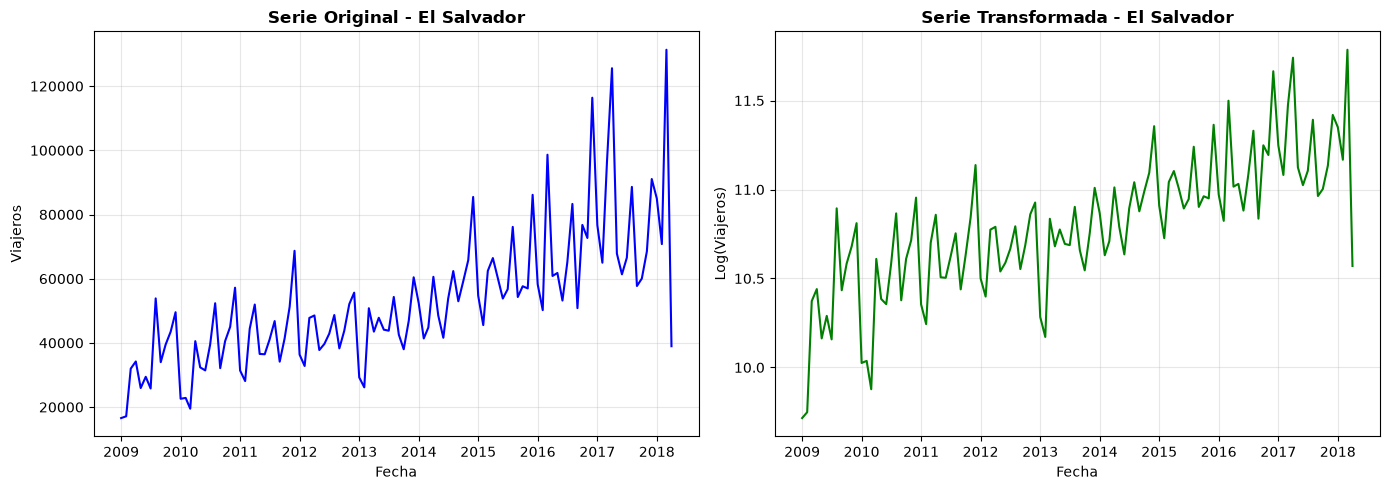

=== ANALISIS ESTACIONARIEDAD EN MEDIA ===

--- GRAFICO DE AUTOCORRELACION


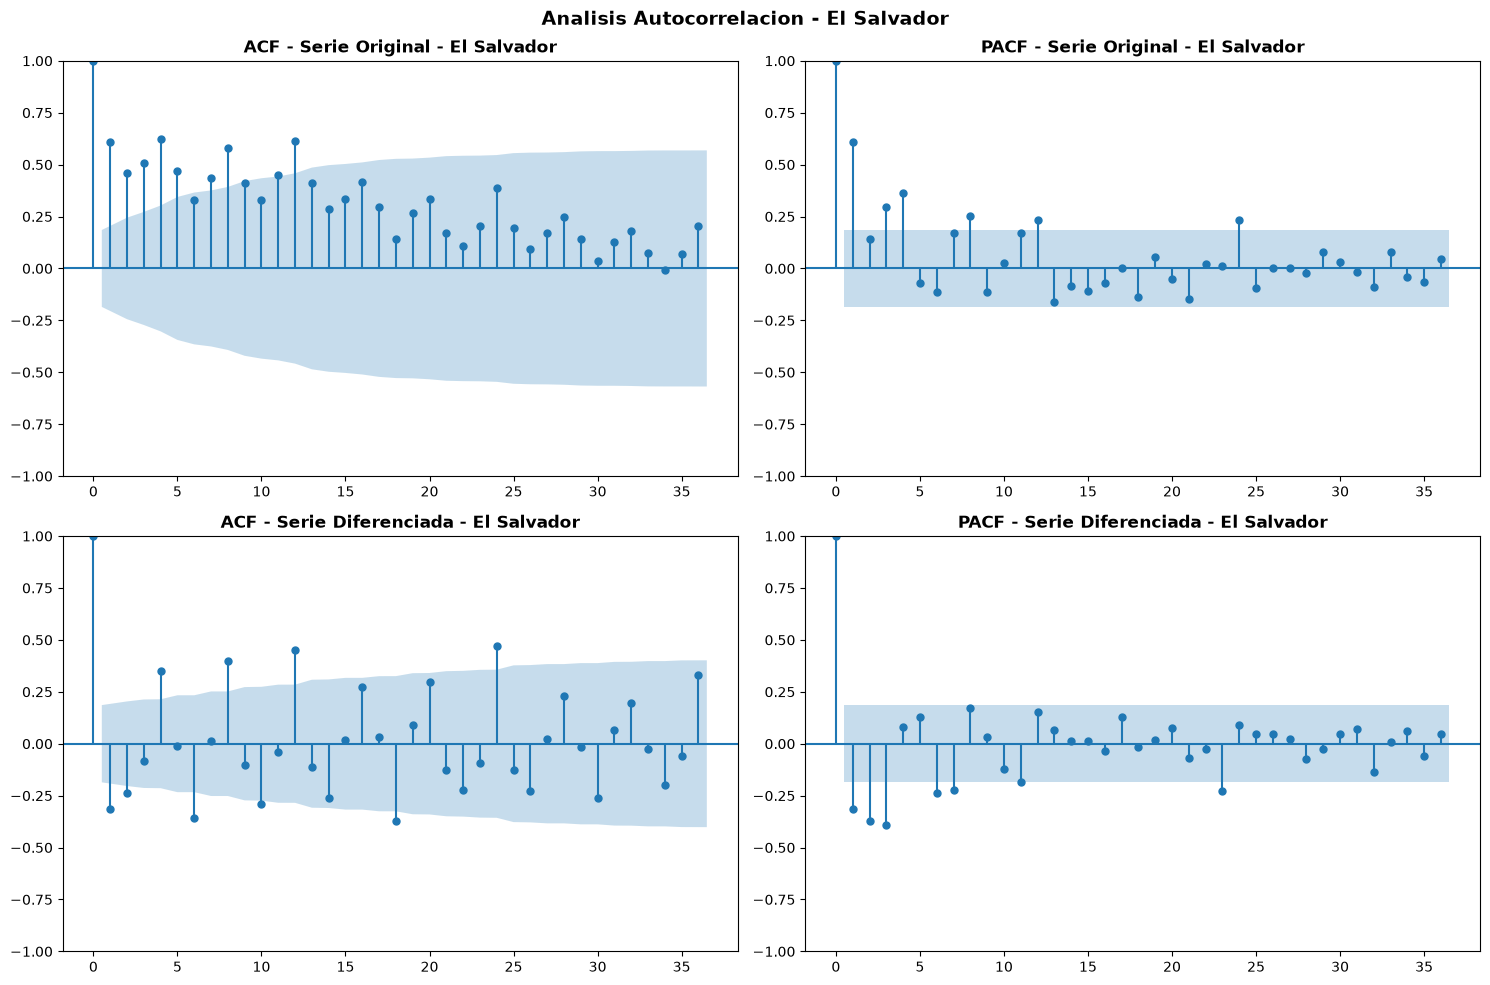


--- PRUEBA DE DICKEY-FULLER AUMENTADA

Resultados del Test de Dickey-Fuller - Serie transformada:
  Estadistico de prueba: -0.671205
  p-value: 0.854068
  No. retardos usados: 11
  No. observaciones usadas: 100
  Valores criticos:
    1%: -3.497501
    5%: -2.890906
    10%: -2.582435

Serie transformada no es estacionaria en media

Que hacer para hacerla estacionaria en media:
 Aplicar diferenciacion: y_t = y_t - y_{t-1}

Resultados del Test de Dickey-Fuller - 1era diferenciacion:
  Estadistico de prueba: -7.587817
  p-value: 0.000000
  No. retardos usados: 10
  No. observaciones usadas: 100
  Valores criticos:
    1%: -3.497501
    5%: -2.890906
    10%: -2.582435

1era diferenciacion es estacionaria en media

Diferenciacion necesaria: d = 1


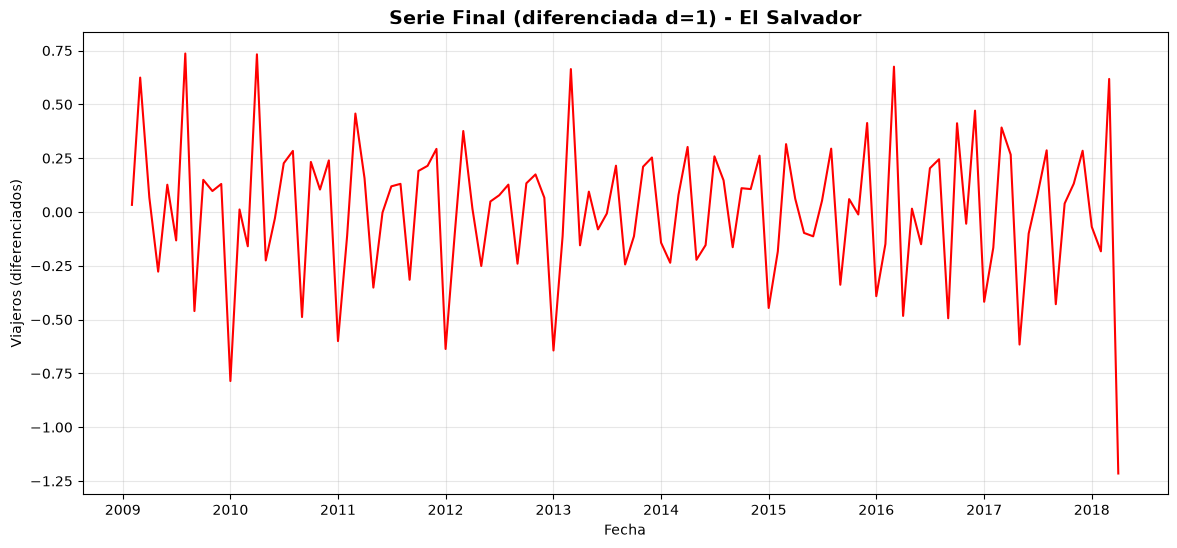

=== SELECCION DE PARAMETROS p, q y d ===

auto_arima para seleccion de parametros...
Performing stepwise search to minimize aic
 ARIMA(0,1,0)(1,0,1)[12] intercept   : AIC=4710.315, Time=0.29 sec
 ARIMA(0,1,0)(0,0,0)[12] intercept   : AIC=4769.354, Time=0.03 sec
 ARIMA(1,1,0)(1,0,0)[12] intercept   : AIC=4714.608, Time=0.15 sec
 ARIMA(0,1,1)(0,0,1)[12] intercept   : AIC=4714.386, Time=0.17 sec
 ARIMA(0,1,0)(0,0,0)[12]             : AIC=4767.429, Time=0.02 sec
 ARIMA(0,1,0)(0,0,1)[12] intercept   : AIC=4751.000, Time=0.09 sec
 ARIMA(0,1,0)(1,0,0)[12] intercept   : AIC=4735.337, Time=0.12 sec
 ARIMA(0,1,0)(2,0,1)[12] intercept   : AIC=4710.913, Time=0.64 sec
 ARIMA(0,1,0)(1,0,2)[12] intercept   : AIC=4711.566, Time=0.67 sec
 ARIMA(0,1,0)(0,0,2)[12] intercept   : AIC=4721.581, Time=0.29 sec
 ARIMA(0,1,0)(2,0,0)[12] intercept   : AIC=4711.614, Time=0.27 sec
 ARIMA(0,1,0)(2,0,2)[12] intercept   : AIC=4709.247, Time=0.86 sec
 ARIMA(1,1,0)(2,0,2)[12] intercept   : AIC=4697.058, Time=1.16 sec
 

c:\Users\abbyd\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\statsmodels\tsa\statespace\sarimax.py:966: UserWarning: Non-stationary starting autoregressive parameters found. Using zeros as starting parameters.
  warn('Non-stationary starting autoregressive parameters'
c:\Users\abbyd\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\statsmodels\tsa\statespace\sarimax.py:978: UserWarning: Non-invertible starting MA parameters found. Using zeros as starting parameters.
  warn('Non-invertible starting MA parameters found.'


  ARIMA(4,1,2) - AIC: 569.32, MAE: 10086.30
  ARIMA(4,1,3) - AIC: 558.89, MAE: 11569.34


c:\Users\abbyd\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\statsmodels\tsa\statespace\sarimax.py:966: UserWarning: Non-stationary starting autoregressive parameters found. Using zeros as starting parameters.
  warn('Non-stationary starting autoregressive parameters'
c:\Users\abbyd\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\statsmodels\tsa\statespace\sarimax.py:978: UserWarning: Non-invertible starting MA parameters found. Using zeros as starting parameters.
  warn('Non-invertible starting MA parameters found.'


  ARIMA(5,1,2) - AIC: 552.24, MAE: 10864.48


...

  ARIMA(2,1,1) - AIC: 580.05, MAE: 3867.46


c:\Users\abbyd\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\statsmodels\tsa\statespace\sarimax.py:966: UserWarning: Non-stationary starting autoregressive parameters found. Using zeros as starting parameters.
  warn('Non-stationary starting autoregressive parameters'
c:\Users\abbyd\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\statsmodels\tsa\statespace\sarimax.py:978: UserWarning: Non-invertible starting MA parameters found. Using zeros as starting parameters.
  warn('Non-invertible starting MA parameters found.'


  ARIMA(1,1,2) - AIC: 579.46, MAE: 4314.62


c:\Users\abbyd\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


  ARIMA(4,1,4) - AIC: 559.47, MAE: 14294.15
  ARIMA(6,1,2) - AIC: 553.07, MAE: 11274.07

Mejor modelo segun AIC: ARIMA(5,1,2)
   AIC: 552.24
   BIC: 578.98
   MAE: 10864.48
   RMSE: 14813.17

Analisis de residuos del mejor modelo:


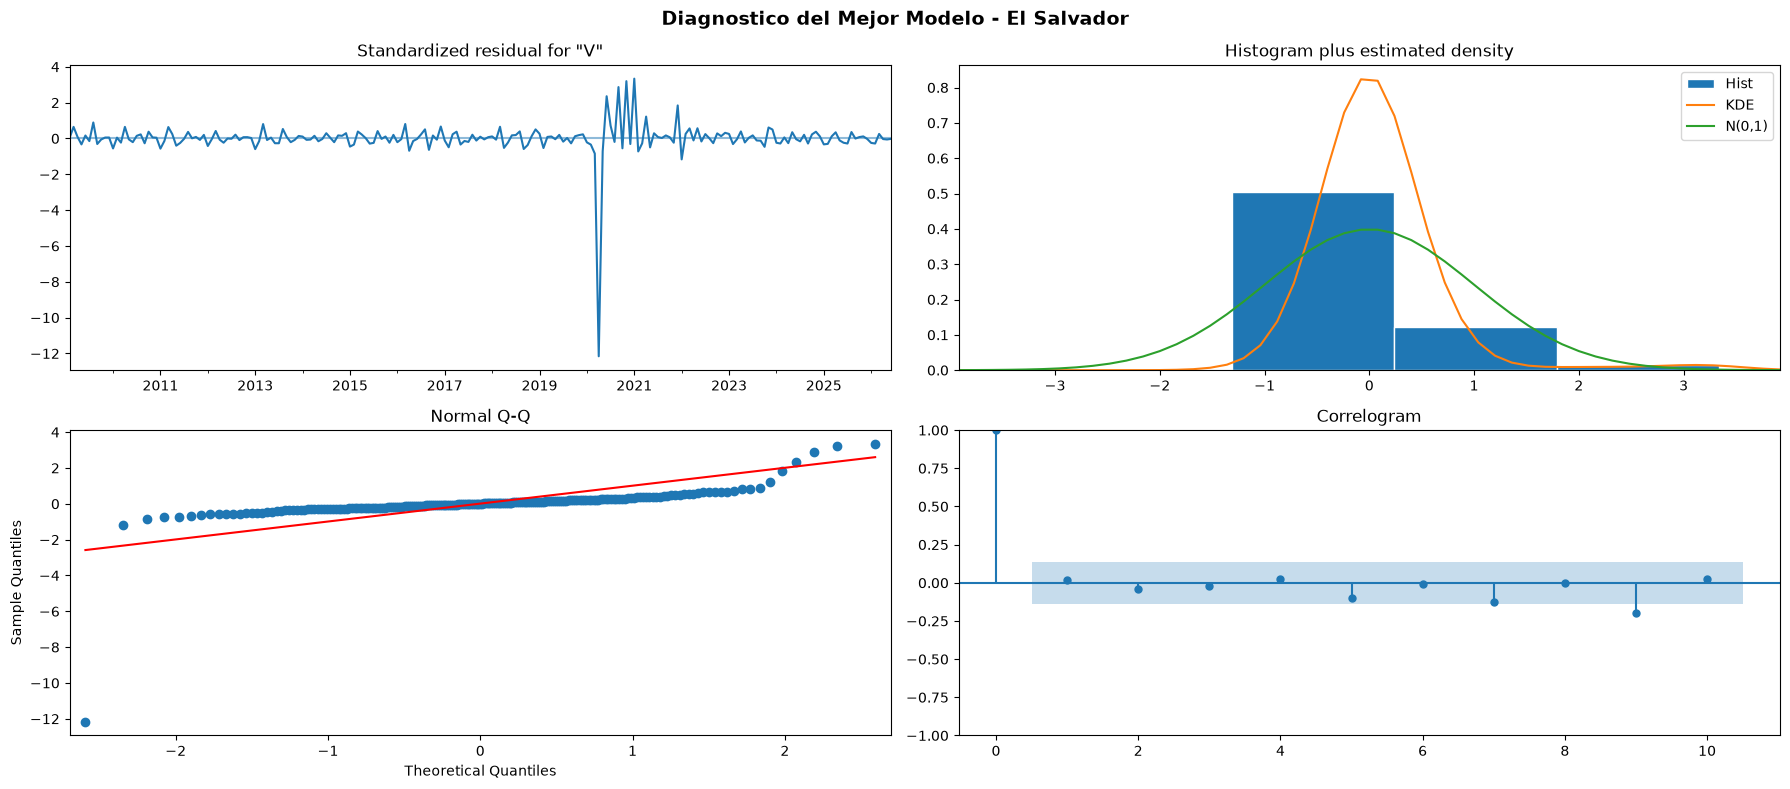


Interpretacion de residuos:
=== MODELOS ALTERNATIVOS ===

Holt-Winters:
   MAE: 37236.59, RMSE: 48310.30

Suavizamiento Exponencial Simple:
   MAE: 40317.58, RMSE: 48108.32

Seasonal Naive:
   MAE: 44779.06, RMSE: 53124.90

Comparacion modelos:
ARIMA (ARIMA(5,1,2)): MAE=10864.48, RMSE=14813.17
Holt-Winters: MAE=37236.59, RMSE=48310.30
Suavizamiento Exp.: MAE=40317.58, RMSE=48108.32
Seasonal Naive: MAE=44779.06, RMSE=53124.90

Mejor modelo alternativo segun MAE: Holt-Winters
   MAE: 37236.59
=== PREDICCION EN CONJUNTO DE PRUEBA ===


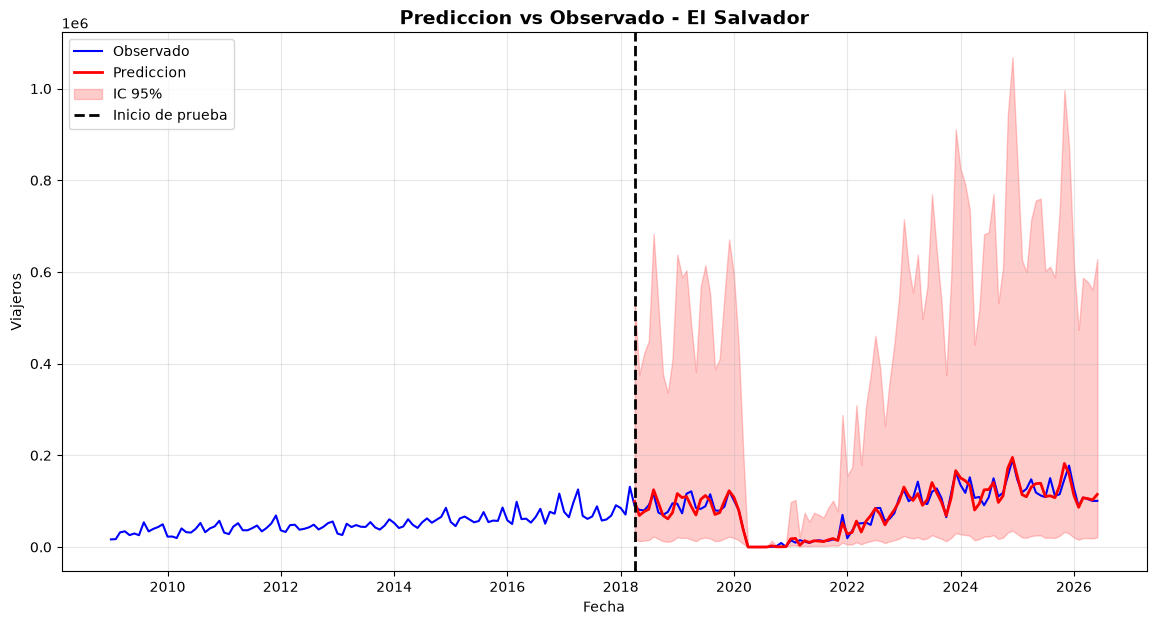


Predicciones para el conjunto de prueba:
  MAE: 10864.48
  RMSE: 14813.17
=== COMPARACION DE METRICAS ===
TABLA COMPARATIVA DE MODELOS:
            Modelo          MAE         RMSE        AIC       BIC
      ARIMA(5,1,2) 10864.480905 14813.165068 552.244386 578.98306
      Holt-Winters 37236.586215 48310.296291        NaN       NaN
Suavizamiento Exp. 40317.577903 48108.318586        NaN       NaN
    Seasonal Naive 44779.064638 53124.898570        NaN       NaN
=== SELECCION DEL MEJOR MODELO ===

MEJOR MODELO SEGUN MAE: ARIMA(5,1,2)
   MAE: 10864.48
   RMSE: 14813.17

MODELO SELECCIONADO FINALMENTE:
   ARIMA(5,1,2)
   - MAE: 10864.48
   - RMSE: 14813.17
   - AIC: 552.24
   - BIC: 578.98

Analisis completado exitosamente para El Salvador

ANALISIS DE SERIE DE TIEMPO: Guatemala
=== INICIO, FIN Y FRECUENCIA ===
 - Inicio: 2009-01-01 00:00:00
 - Fin: 2026-06-01 00:00:00
 - Frecuencia: <MonthBegin>
 - No. observaciones: 210
  Entrenamiento: 112 observaciones
  Prueba: 99 observaciones
=== 

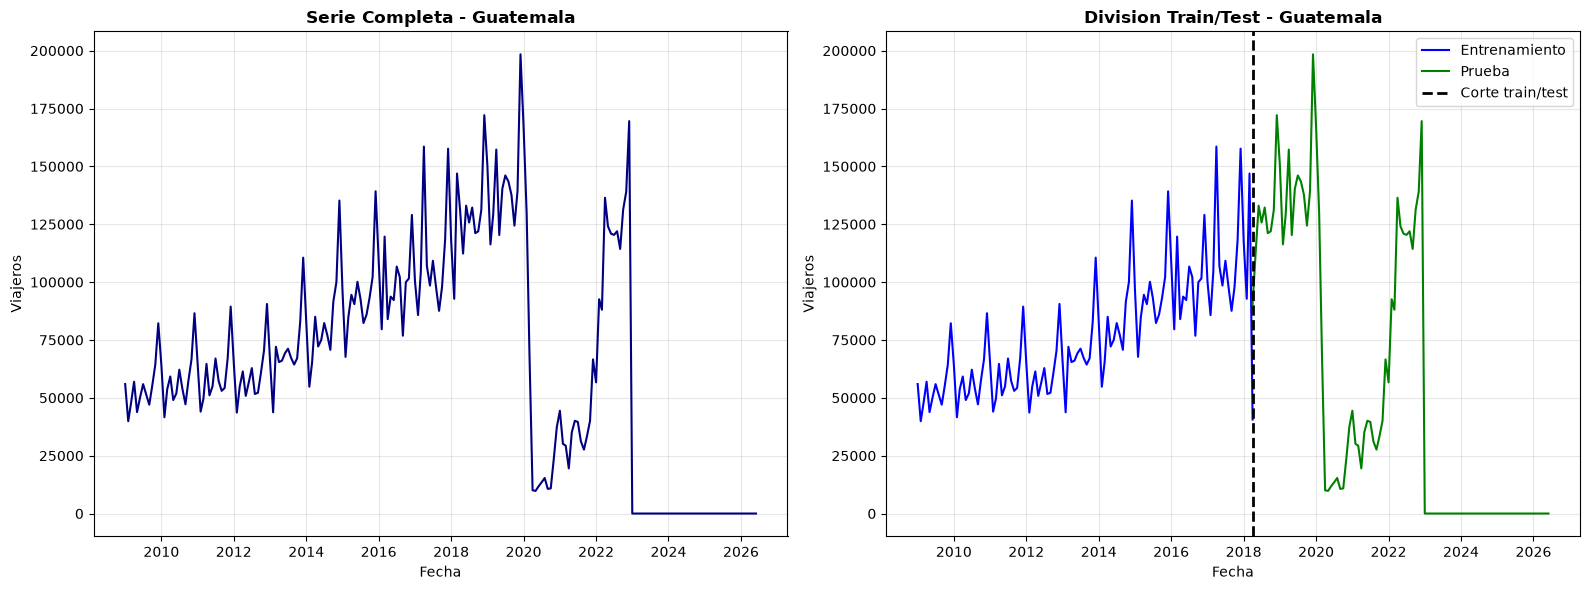

=== DESCOMPOSICION DE SERIE ===


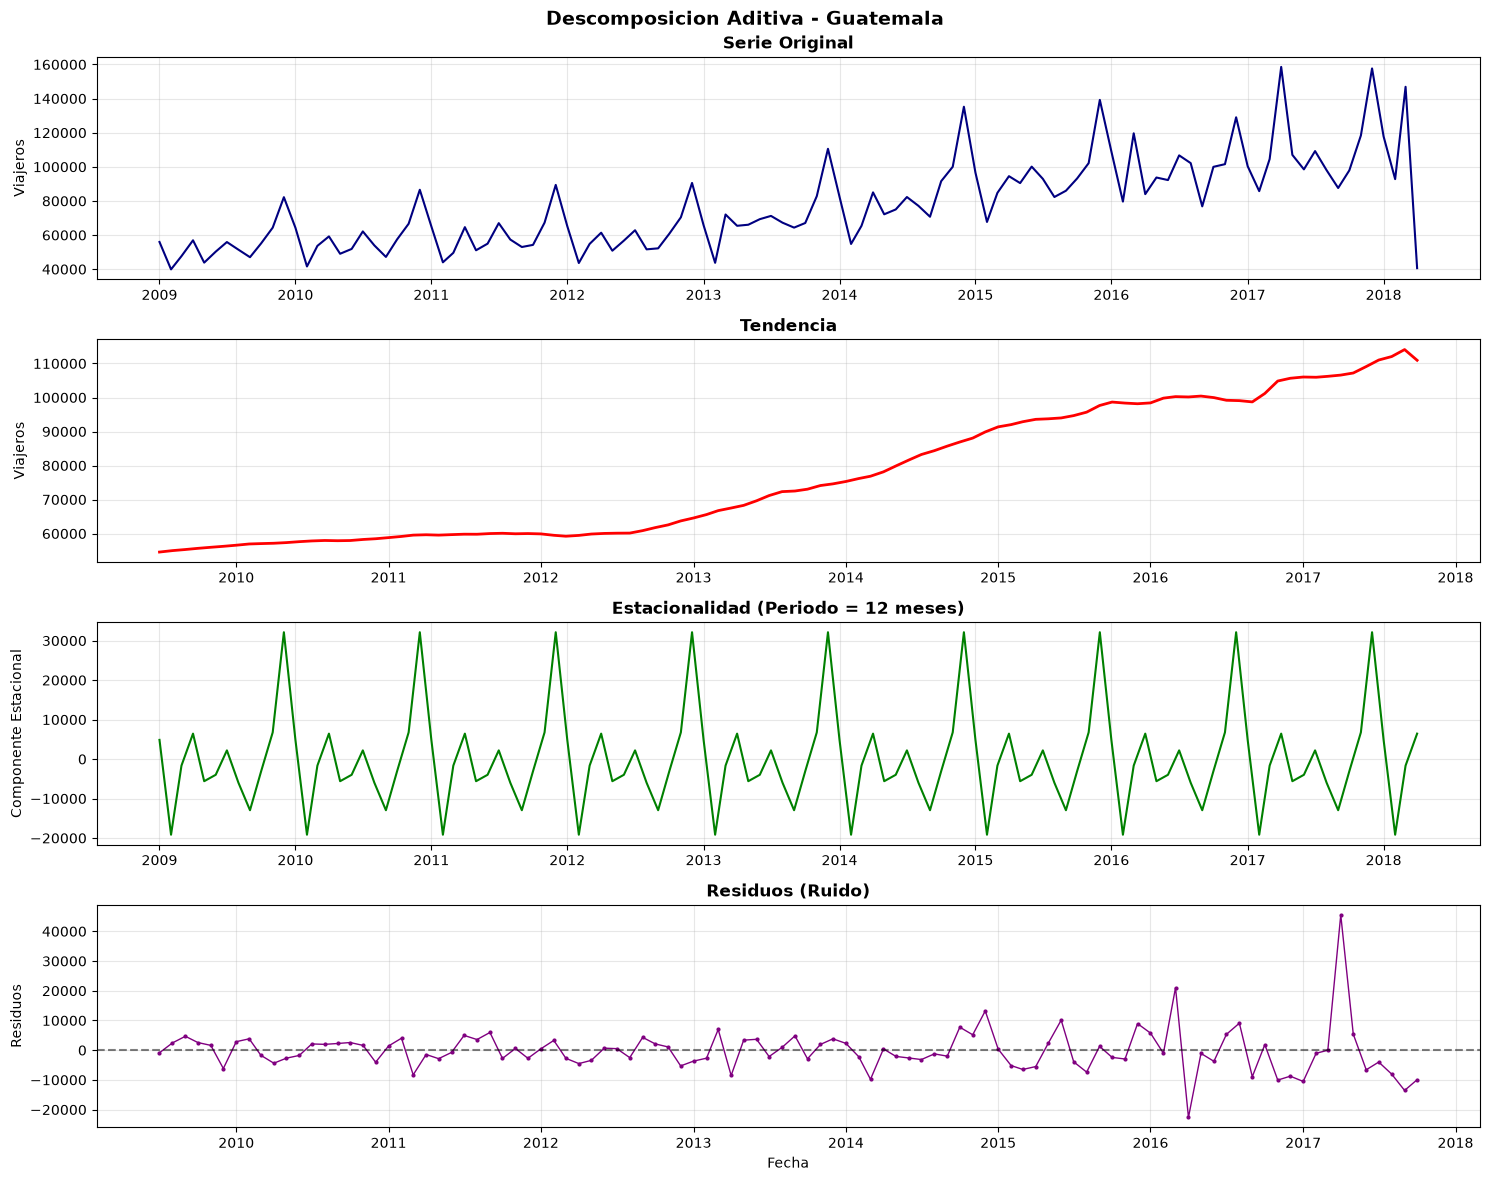

- Estacionariedad en media:
   Si la tendencia es creciente o decreciente =  la media cambia con el tiempo

- Estacionariedad en varianza:
   Residuos tienen varianza relativamente estable, serie puede ser estacionaria en varianza
=== DETERMINACION SI TRANSFORMACION NECESARIA ===
Correlacion entre media y varianza: 0.830
Se recomienda transformacion logaritmica
  + Transformacion: log(Viajeros + 1)


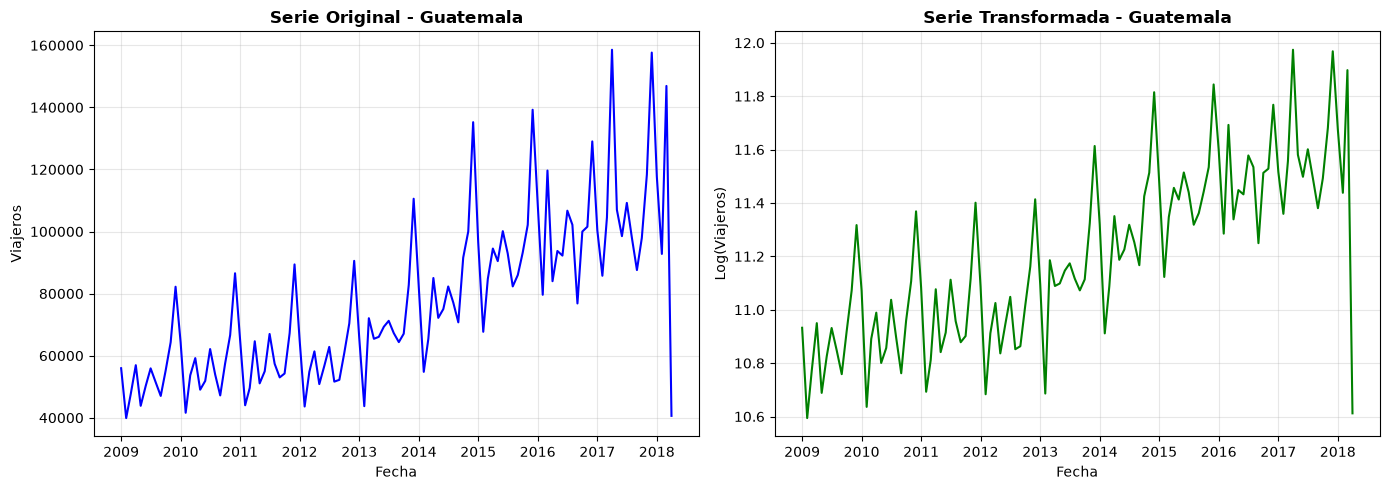

=== ANALISIS ESTACIONARIEDAD EN MEDIA ===

--- GRAFICO DE AUTOCORRELACION


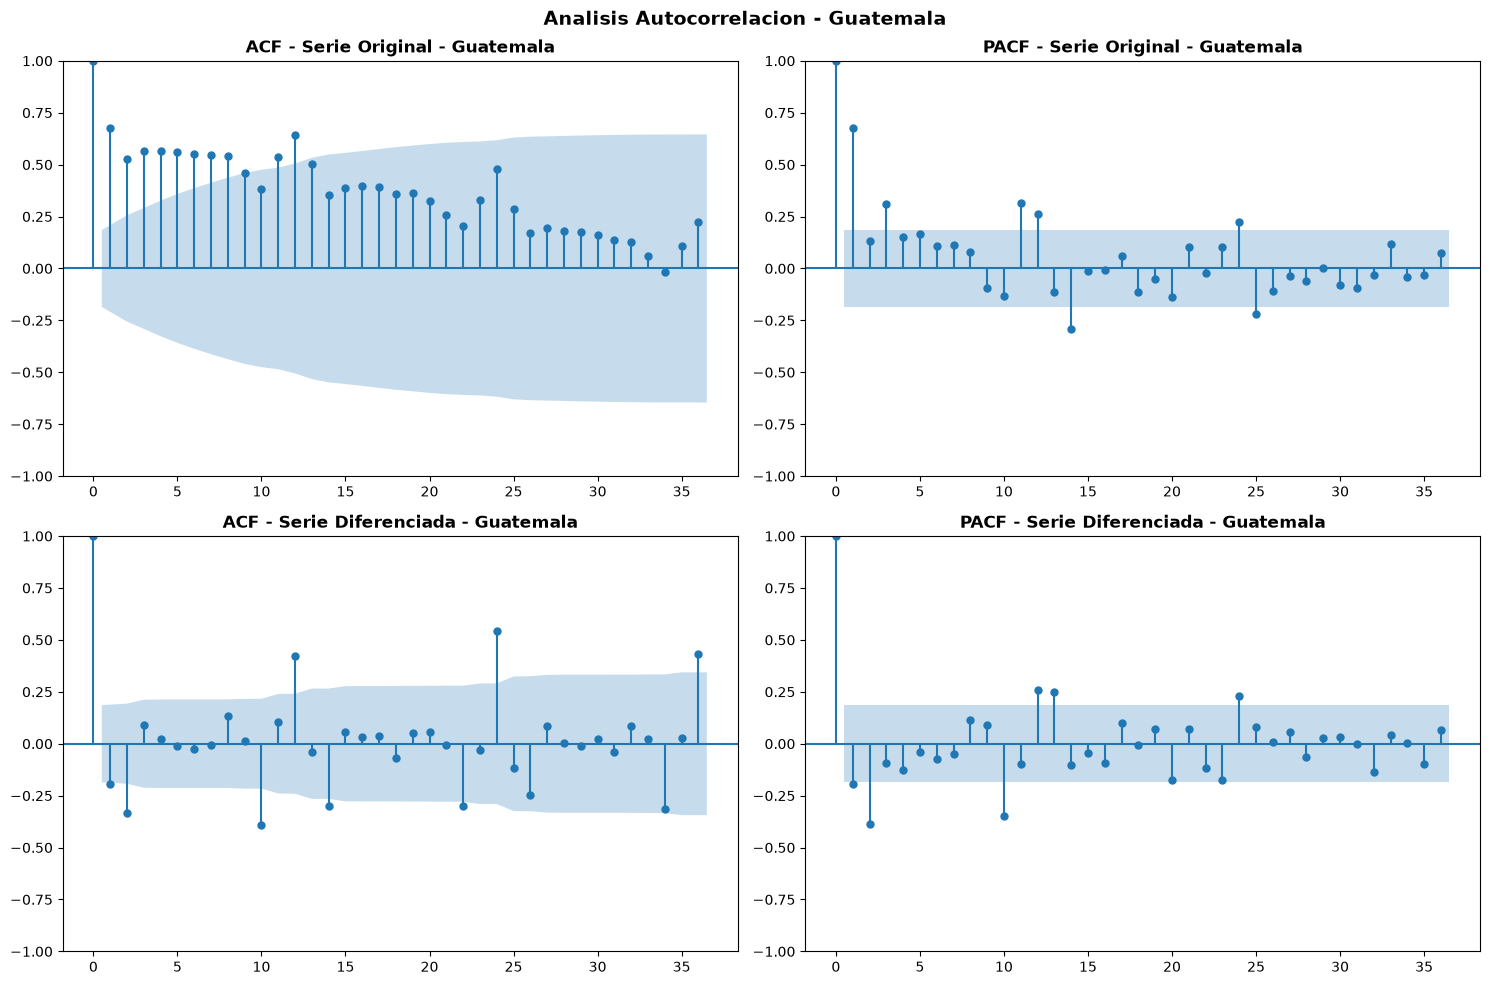


--- PRUEBA DE DICKEY-FULLER AUMENTADA

Resultados del Test de Dickey-Fuller - Serie transformada:
  Estadistico de prueba: -0.527565
  p-value: 0.886524
  No. retardos usados: 13
  No. observaciones usadas: 98
  Valores criticos:
    1%: -3.498910
    5%: -2.891516
    10%: -2.582760

Serie transformada no es estacionaria en media

Que hacer para hacerla estacionaria en media:
 Aplicar diferenciacion: y_t = y_t - y_{t-1}

Resultados del Test de Dickey-Fuller - 1era diferenciacion:
  Estadistico de prueba: -3.262257
  p-value: 0.016652
  No. retardos usados: 12
  No. observaciones usadas: 98
  Valores criticos:
    1%: -3.498910
    5%: -2.891516
    10%: -2.582760

1era diferenciacion es estacionaria en media

Diferenciacion necesaria: d = 1


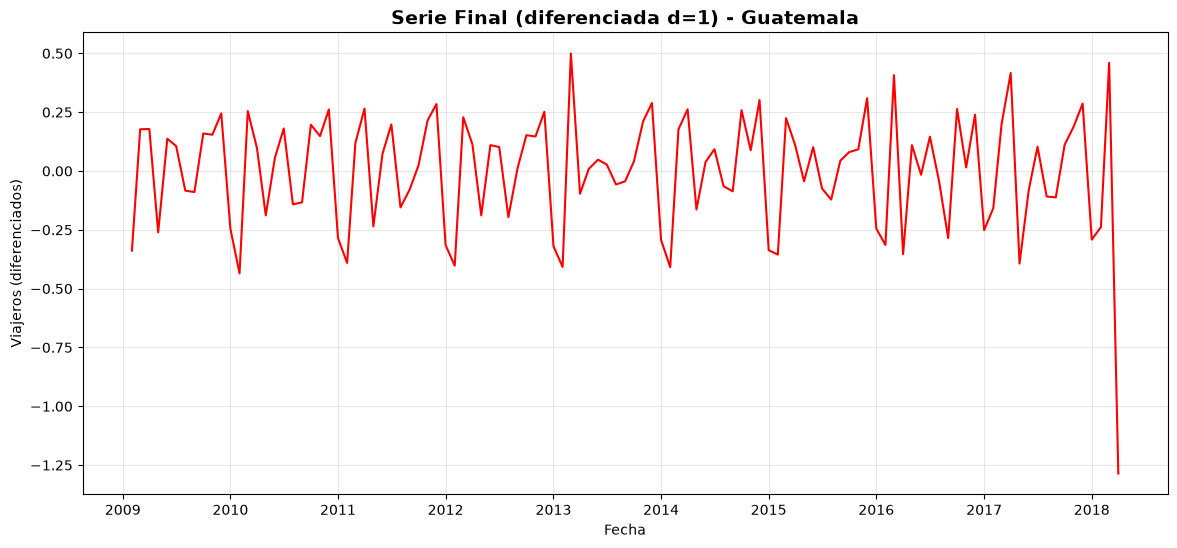

=== SELECCION DE PARAMETROS p, q y d ===

auto_arima para seleccion de parametros...
Performing stepwise search to minimize aic
 ARIMA(0,1,0)(1,0,1)[12] intercept   : AIC=4734.663, Time=0.31 sec
 ARIMA(0,1,0)(0,0,0)[12] intercept   : AIC=4768.515, Time=0.03 sec
 ARIMA(1,1,0)(1,0,0)[12] intercept   : AIC=4749.840, Time=0.16 sec
 ARIMA(0,1,1)(0,0,1)[12] intercept   : AIC=4753.811, Time=0.18 sec
 ARIMA(0,1,0)(0,0,0)[12]             : AIC=4766.550, Time=0.03 sec
 ARIMA(0,1,0)(0,0,1)[12] intercept   : AIC=4755.812, Time=0.12 sec
 ARIMA(0,1,0)(1,0,0)[12] intercept   : AIC=4750.703, Time=0.13 sec
 ARIMA(0,1,0)(2,0,1)[12] intercept   : AIC=4736.411, Time=0.76 sec
 ARIMA(0,1,0)(1,0,2)[12] intercept   : AIC=4736.411, Time=1.11 sec
 ARIMA(0,1,0)(0,0,2)[12] intercept   : AIC=4752.498, Time=0.42 sec
 ARIMA(0,1,0)(2,0,0)[12] intercept   : AIC=4745.626, Time=0.35 sec
 ARIMA(0,1,0)(2,0,2)[12] intercept   : AIC=inf, Time=2.06 sec
 ARIMA(1,1,0)(1,0,1)[12] intercept   : AIC=4734.330, Time=0.59 sec
 ARIMA

c:\Users\abbyd\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\statsmodels\tsa\statespace\sarimax.py:966: UserWarning: Non-stationary starting autoregressive parameters found. Using zeros as starting parameters.
  warn('Non-stationary starting autoregressive parameters'
c:\Users\abbyd\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\statsmodels\tsa\statespace\sarimax.py:978: UserWarning: Non-invertible starting MA parameters found. Using zeros as starting parameters.
  warn('Non-invertible starting MA parameters found.'


  ARIMA(1,1,1) - AIC: 540.10, MAE: 692.05
  ARIMA(1,1,2) - AIC: 542.20, MAE: 608.51
  ARIMA(2,1,1) - AIC: 542.09, MAE: 687.68
  ARIMA(1,2,1) - AIC: 543.36, MAE: 747.24
  ARIMA(0,1,1) - AIC: 538.33, MAE: 512.12
  ARIMA(1,1,0) - AIC: 538.33, MAE: 508.27
  ARIMA(2,1,1) - AIC: 542.09, MAE: 687.68
  ARIMA(1,1,2) - AIC: 542.20, MAE: 608.51
  ARIMA(1,1,3) - AIC: 544.18, MAE: 631.73
  ARIMA(3,1,1) - AIC: 544.18, MAE: 630.15

Mejor modelo segun AIC: ARIMA(0,1,1)
   AIC: 538.33
   BIC: 545.01
   MAE: 512.12
   RMSE: 4102.54

Analisis de residuos del mejor modelo:


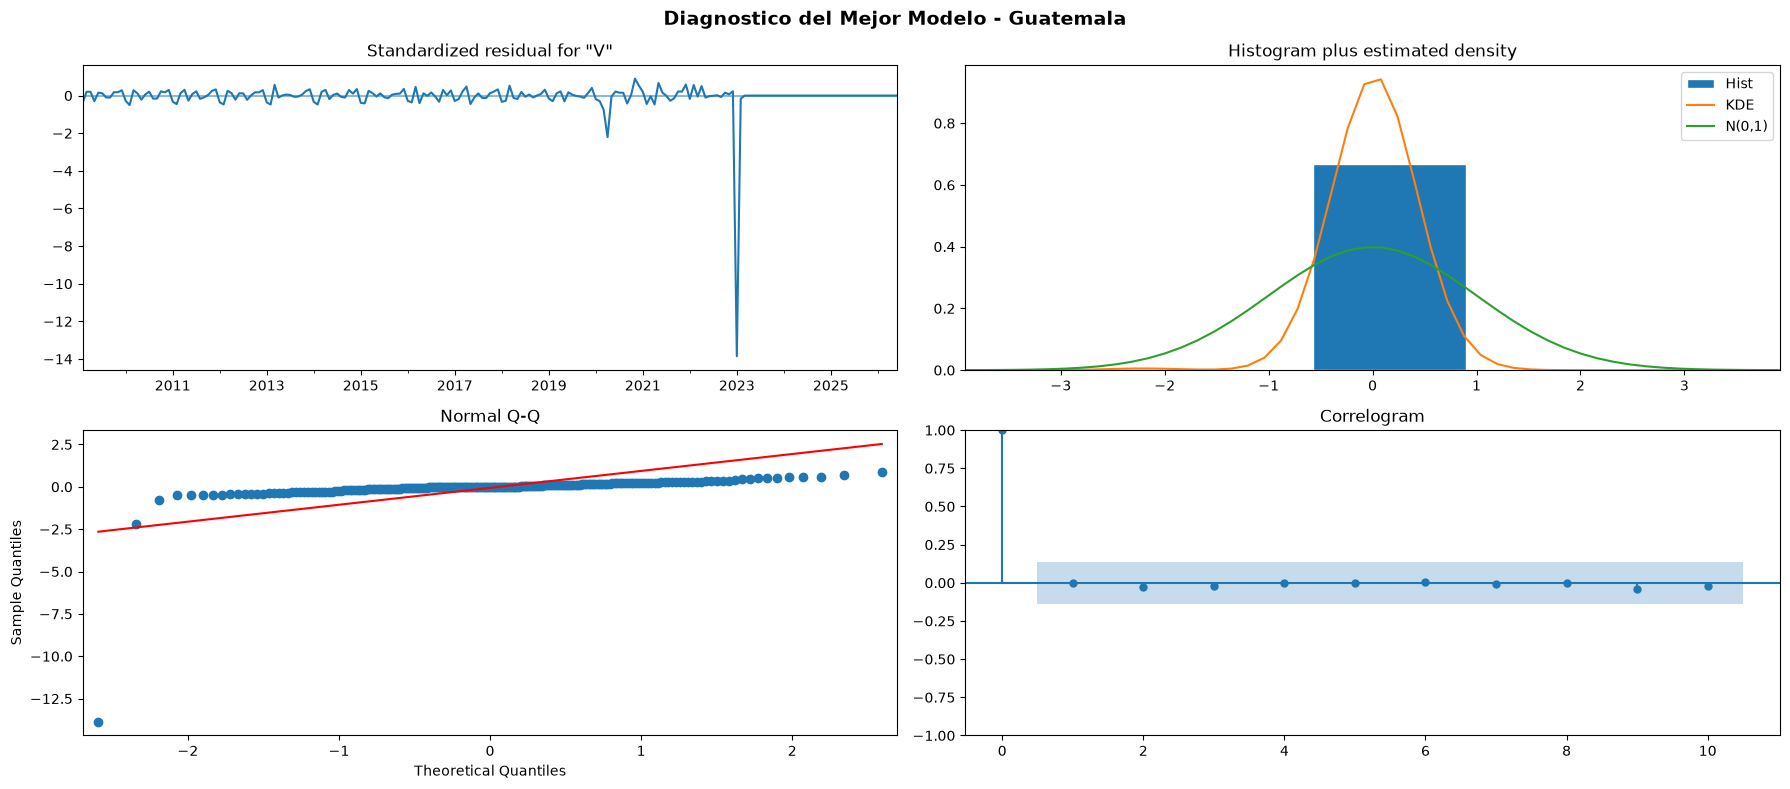


Interpretacion de residuos:
=== MODELOS ALTERNATIVOS ===

Holt-Winters:
   MAE: 70935.49, RMSE: 80262.54

Suavizamiento Exponencial Simple:
   MAE: 71980.18, RMSE: 80166.46

Seasonal Naive:
   MAE: 74135.10, RMSE: 84498.19

Comparacion modelos:
ARIMA (ARIMA(0,1,1)): MAE=512.12, RMSE=4102.54
Holt-Winters: MAE=70935.49, RMSE=80262.54
Suavizamiento Exp.: MAE=71980.18, RMSE=80166.46
Seasonal Naive: MAE=74135.10, RMSE=84498.19

Mejor modelo alternativo segun MAE: Holt-Winters
   MAE: 70935.49
=== PREDICCION EN CONJUNTO DE PRUEBA ===


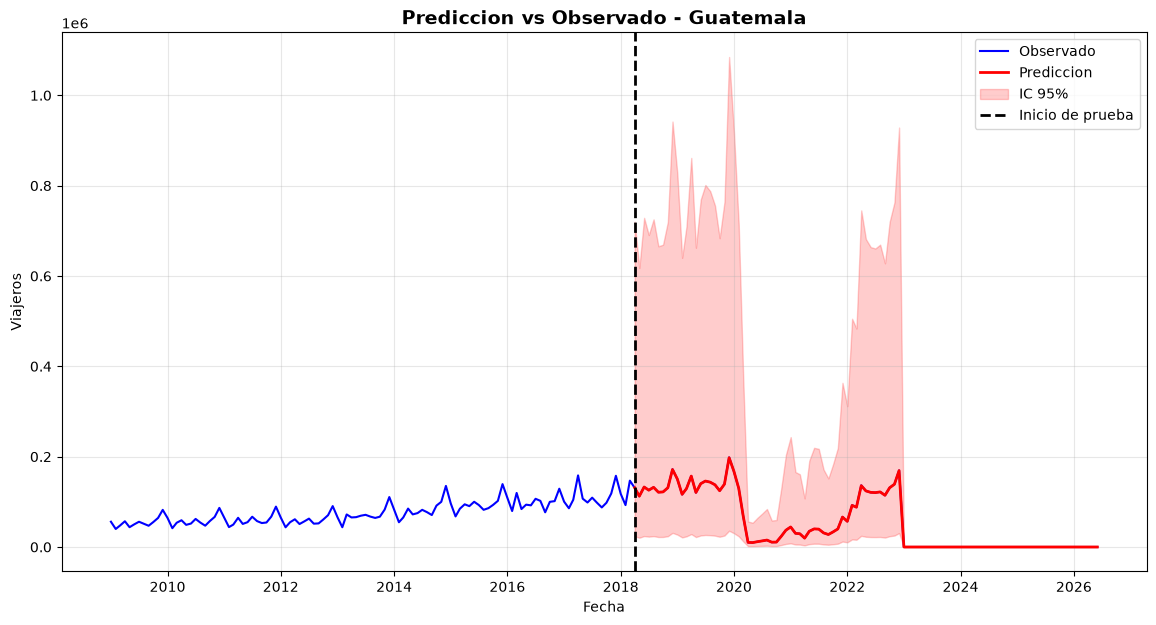


Predicciones para el conjunto de prueba:
  MAE: 512.12
  RMSE: 4102.54
=== COMPARACION DE METRICAS ===
TABLA COMPARATIVA DE MODELOS:
            Modelo          MAE         RMSE        AIC        BIC
      ARIMA(0,1,1)   512.115615  4102.542183 538.327198 545.011867
      Holt-Winters 70935.489312 80262.535529        NaN        NaN
Suavizamiento Exp. 71980.181984 80166.462890        NaN        NaN
    Seasonal Naive 74135.104178 84498.192129        NaN        NaN
=== SELECCION DEL MEJOR MODELO ===

MEJOR MODELO SEGUN MAE: ARIMA(0,1,1)
   MAE: 512.12
   RMSE: 4102.54

MODELO SELECCIONADO FINALMENTE:
   ARIMA(0,1,1)
   - MAE: 512.12
   - RMSE: 4102.54
   - AIC: 538.33
   - BIC: 545.01

Analisis completado exitosamente para Guatemala

ANALISIS DE SERIE DE TIEMPO: Estados Unidos de América
=== INICIO, FIN Y FRECUENCIA ===
 - Inicio: 2009-01-01 00:00:00
 - Fin: 2026-06-01 00:00:00
 - Frecuencia: <MonthBegin>
 - No. observaciones: 210
  Entrenamiento: 112 observaciones
  Prueba: 99 observac

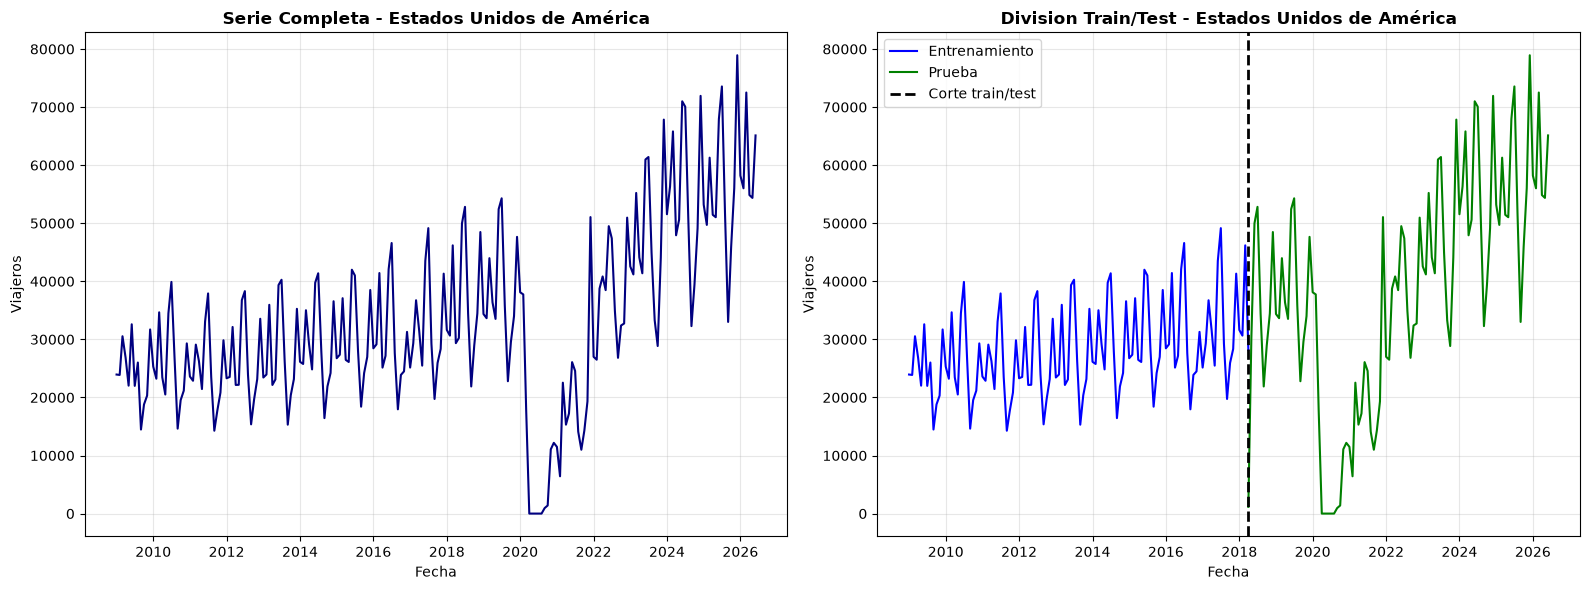

=== DESCOMPOSICION DE SERIE ===


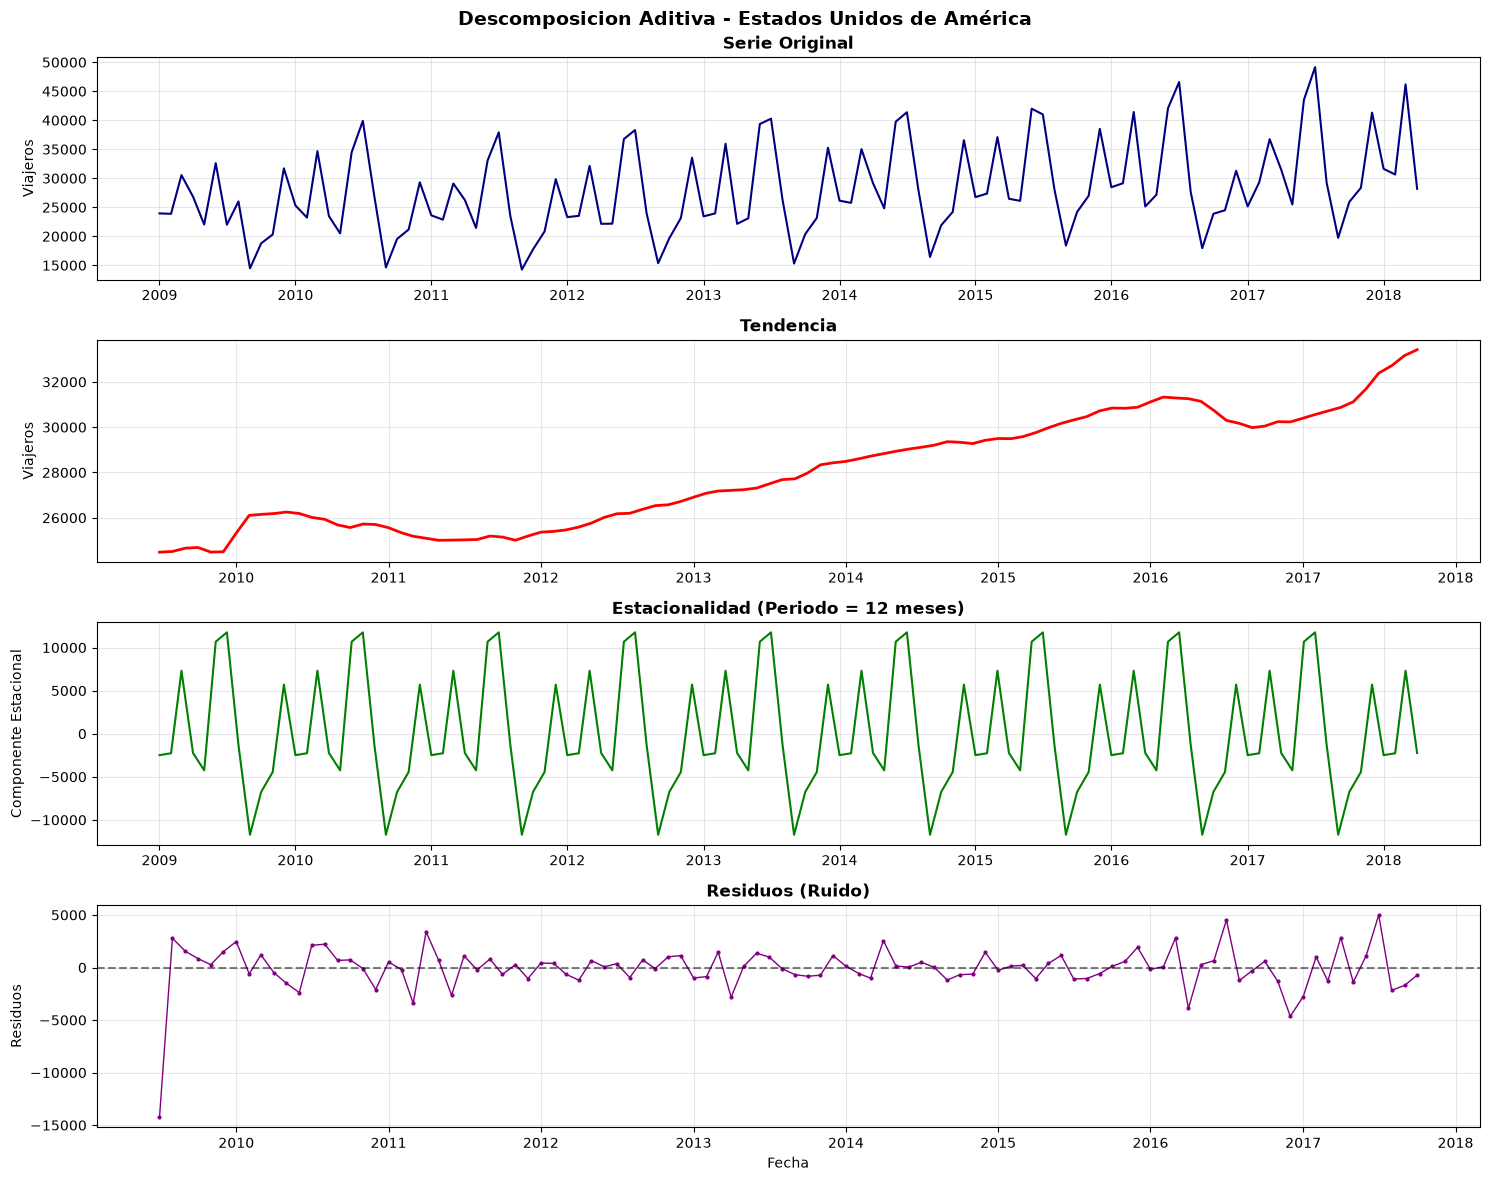

- Estacionariedad en media:
   Si la tendencia es creciente o decreciente =  la media cambia con el tiempo

- Estacionariedad en varianza:
   Residuos tienen varianza relativamente estable, serie puede ser estacionaria en varianza
=== DETERMINACION SI TRANSFORMACION NECESARIA ===
Correlacion entre media y varianza: 0.841
Se recomienda transformacion logaritmica
  + Transformacion: log(Viajeros + 1)


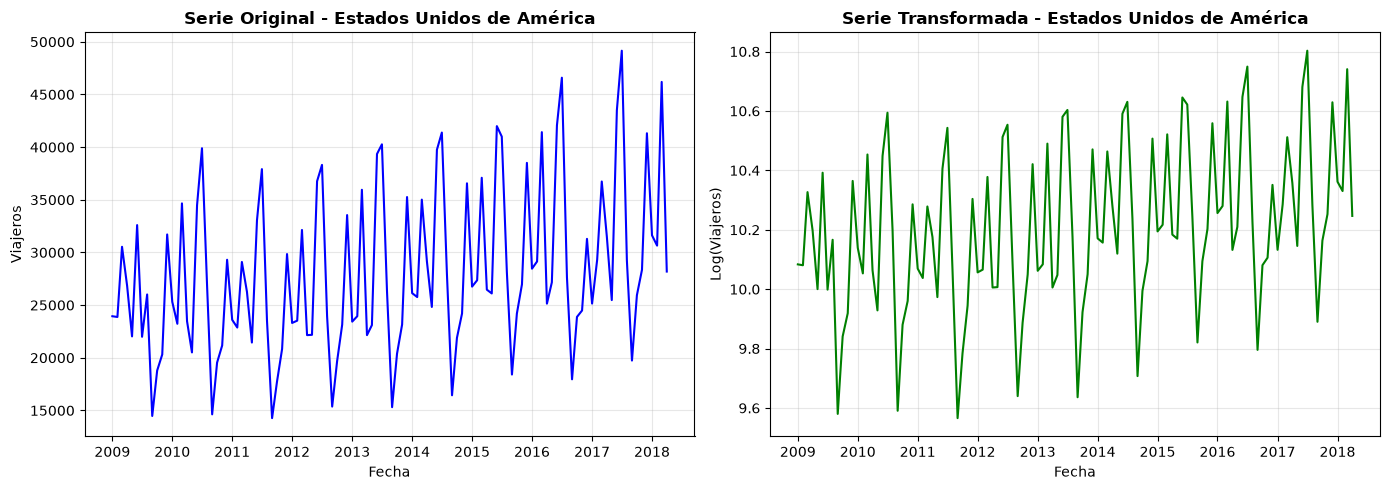

=== ANALISIS ESTACIONARIEDAD EN MEDIA ===

--- GRAFICO DE AUTOCORRELACION


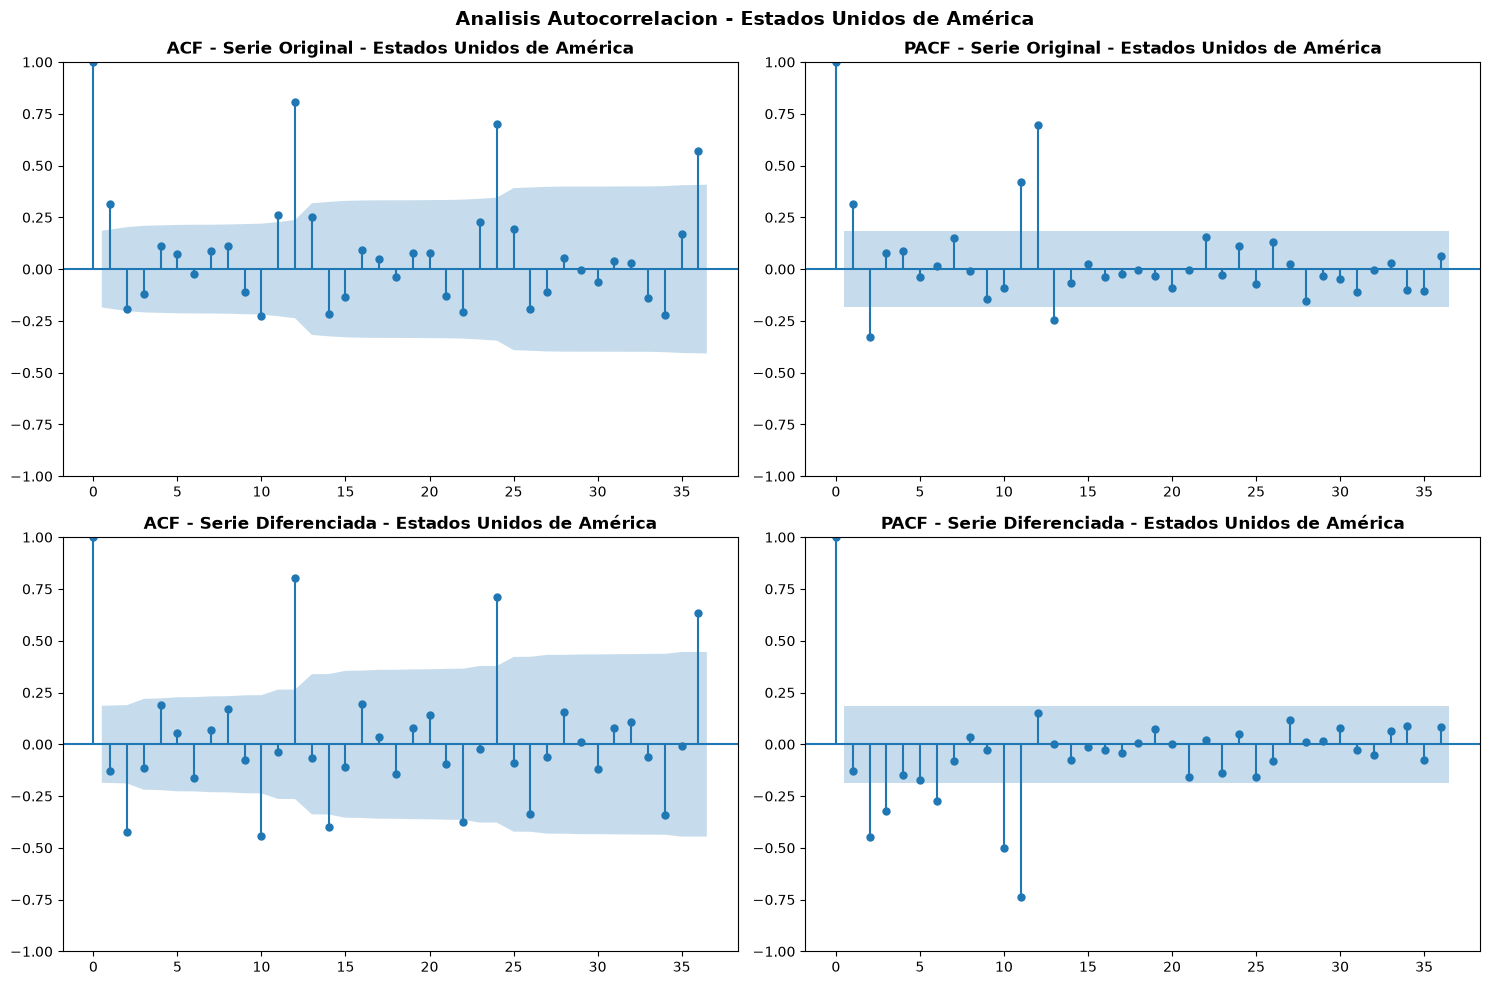


--- PRUEBA DE DICKEY-FULLER AUMENTADA

Resultados del Test de Dickey-Fuller - Serie transformada:
  Estadistico de prueba: 0.463487
  p-value: 0.983720
  No. retardos usados: 11
  No. observaciones usadas: 100
  Valores criticos:
    1%: -3.497501
    5%: -2.890906
    10%: -2.582435

Serie transformada no es estacionaria en media

Que hacer para hacerla estacionaria en media:
 Aplicar diferenciacion: y_t = y_t - y_{t-1}

Resultados del Test de Dickey-Fuller - 1era diferenciacion:
  Estadistico de prueba: -22.922270
  p-value: 0.000000
  No. retardos usados: 10
  No. observaciones usadas: 100
  Valores criticos:
    1%: -3.497501
    5%: -2.890906
    10%: -2.582435

1era diferenciacion es estacionaria en media

Diferenciacion necesaria: d = 1


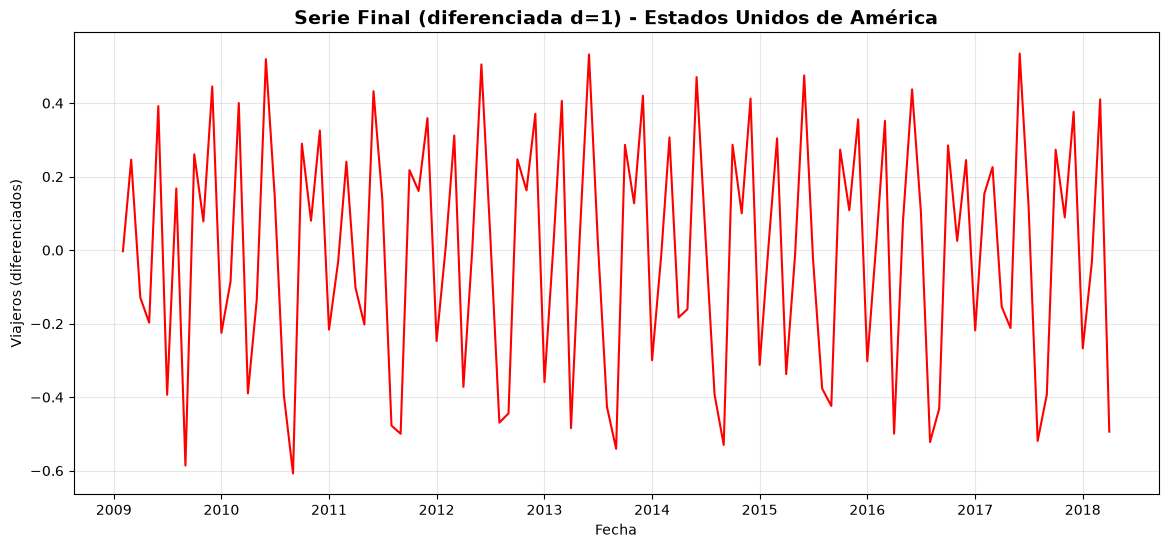

=== SELECCION DE PARAMETROS p, q y d ===

auto_arima para seleccion de parametros...
Performing stepwise search to minimize aic
 ARIMA(0,1,0)(1,0,1)[12] intercept   : AIC=4250.930, Time=2.04 sec
 ARIMA(0,1,0)(0,0,0)[12] intercept   : AIC=4476.936, Time=0.05 sec
 ARIMA(1,1,0)(1,0,0)[12] intercept   : AIC=4362.705, Time=0.35 sec
 ARIMA(0,1,1)(0,0,1)[12] intercept   : AIC=4378.968, Time=0.89 sec
 ARIMA(0,1,0)(0,0,0)[12]             : AIC=4475.008, Time=0.04 sec
 ARIMA(0,1,0)(0,0,1)[12] intercept   : AIC=4407.039, Time=0.21 sec
 ARIMA(0,1,0)(1,0,0)[12] intercept   : AIC=4299.651, Time=0.96 sec
 ARIMA(0,1,0)(2,0,1)[12] intercept   : AIC=4354.544, Time=1.21 sec
 ARIMA(0,1,0)(1,0,2)[12] intercept   : AIC=4296.612, Time=4.29 sec
 ARIMA(0,1,0)(0,0,2)[12] intercept   : AIC=4388.299, Time=0.63 sec
 ARIMA(0,1,0)(2,0,0)[12] intercept   : AIC=4356.580, Time=1.06 sec
 ARIMA(0,1,0)(2,0,2)[12] intercept   : AIC=inf, Time=6.94 sec
 ARIMA(1,1,0)(1,0,1)[12] intercept   : AIC=4294.600, Time=2.32 sec
 ARIMA

c:\Users\abbyd\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\statsmodels\tsa\statespace\sarimax.py:966: UserWarning: Non-stationary starting autoregressive parameters found. Using zeros as starting parameters.
  warn('Non-stationary starting autoregressive parameters'
c:\Users\abbyd\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\statsmodels\tsa\statespace\sarimax.py:978: UserWarning: Non-invertible starting MA parameters found. Using zeros as starting parameters.
  warn('Non-invertible starting MA parameters found.'


  ARIMA(1,1,2) - AIC: 555.62, MAE: 874.86
  ARIMA(0,1,3) - AIC: 555.40, MAE: 1257.32
  ARIMA(2,1,1) - AIC: 550.60, MAE: 2159.08

Mejor modelo segun AIC: ARIMA(2,1,1)
   AIC: 550.60
   BIC: 563.97
   MAE: 2159.08
   RMSE: 3922.61

Analisis de residuos del mejor modelo:


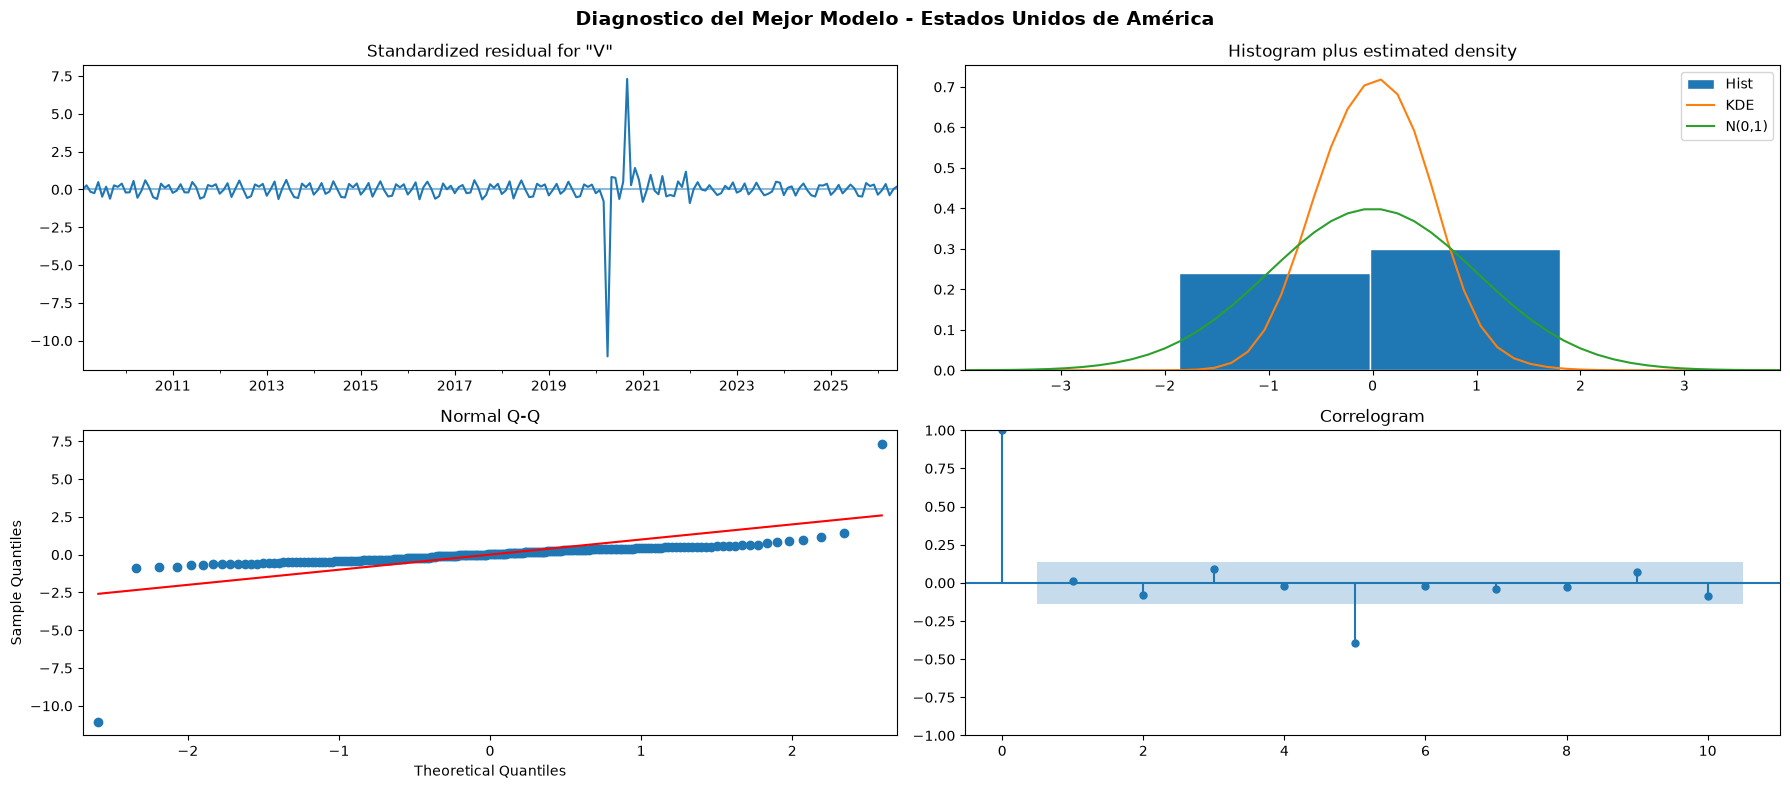


Interpretacion de residuos:
=== MODELOS ALTERNATIVOS ===

Holt-Winters:
   MAE: 15105.83, RMSE: 18722.81

Suavizamiento Exponencial Simple:
   MAE: 17339.69, RMSE: 20849.37

Seasonal Naive:
   MAE: 17180.09, RMSE: 21009.23

Comparacion modelos:
ARIMA (ARIMA(2,1,1)): MAE=2159.08, RMSE=3922.61
Holt-Winters: MAE=15105.83, RMSE=18722.81
Suavizamiento Exp.: MAE=17339.69, RMSE=20849.37
Seasonal Naive: MAE=17180.09, RMSE=21009.23

Mejor modelo alternativo segun MAE: Holt-Winters
   MAE: 15105.83
=== PREDICCION EN CONJUNTO DE PRUEBA ===


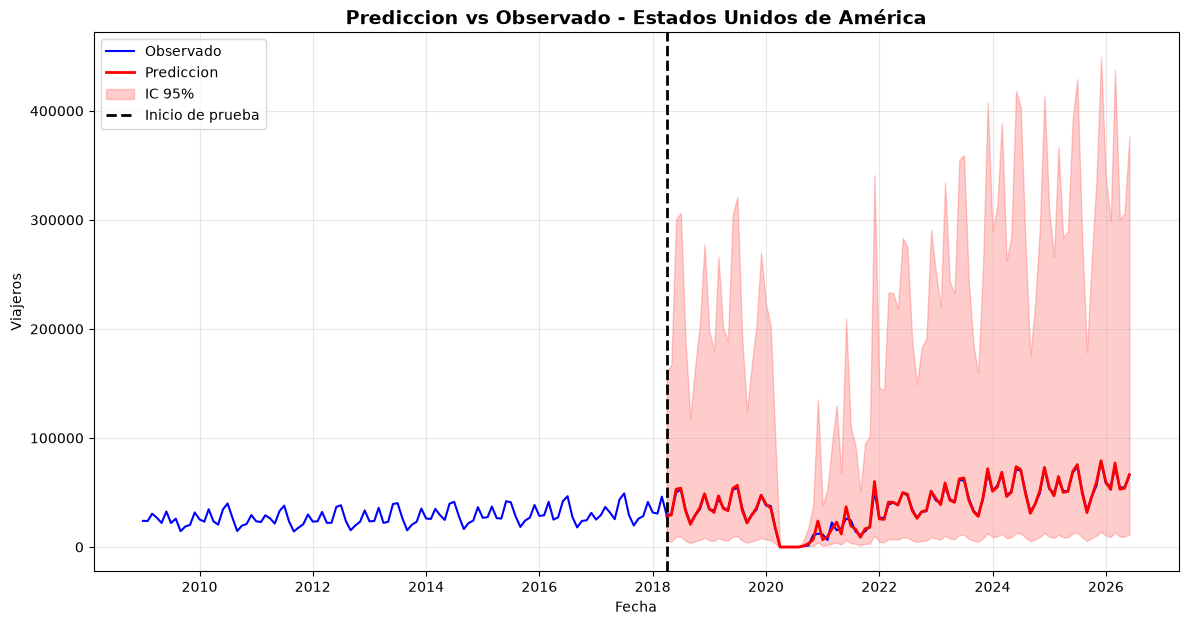


Predicciones para el conjunto de prueba:
  MAE: 2159.08
  RMSE: 3922.61
=== COMPARACION DE METRICAS ===
TABLA COMPARATIVA DE MODELOS:
            Modelo          MAE         RMSE        AIC        BIC
      ARIMA(2,1,1)  2159.081702  3922.605243 550.602022 563.971359
      Holt-Winters 15105.830214 18722.812073        NaN        NaN
Suavizamiento Exp. 17339.692964 20849.373371        NaN        NaN
    Seasonal Naive 17180.094754 21009.226059        NaN        NaN
=== SELECCION DEL MEJOR MODELO ===

MEJOR MODELO SEGUN MAE: ARIMA(2,1,1)
   MAE: 2159.08
   RMSE: 3922.61

MODELO SELECCIONADO FINALMENTE:
   ARIMA(2,1,1)
   - MAE: 2159.08
   - RMSE: 3922.61
   - AIC: 550.60
   - BIC: 563.97

Analisis completado exitosamente para Estados Unidos de América

                      Pais Mejor Modelo          MAE         RMSE        AIC        BIC
              El Salvador ARIMA(5,1,2) 10864.480905 14813.165068 552.244386 578.983060
                Guatemala ARIMA(0,1,1)   512.115615  4102.54218

In [11]:
print("=== PAISES CON MAYOR NUMERO ACUMULADO DE VIAJEROS ===")

#top 3
top3 = df_filtracion.groupby('País')['Viajero'].sum().sort_values(ascending=False).head(3)
print("Top 3 paises con mas viajeros:")
for i, (pais, total) in enumerate(top3.items(), 1):
    print(f"   {i}- {pais} ({total:,.0f})")

#sereie / pais
series_paises = {}

for pais in top3.index:
    df_pais = df_filtracion[df_filtracion['País'] == pais]
    serie_mensual = df_pais.groupby('Fecha')['Viajero'].sum()

    fecha_min = df_filtracion['Fecha'].min()
    fecha_max = df_filtracion['Fecha'].max()

    months = pd.date_range(start=fecha_min, end=fecha_max, freq='MS')

    serie_mensual = serie_mensual.reindex(months, fill_value=0)
    series_paises[pais] = serie_mensual

print("\n=== SERIES DE PAISES CON MAYOR NUMERO DE VIAJEROS ===")
for pais, serie in series_paises.items():
    print(f"\n»» {pais}")
    print(f"  + Rango: {serie.index.min()} -- {serie.index.max()}")
    print(f"  + Frecuencia: {serie.index.freq if serie.index.freq else 'Mensual (no especificada)'}")
    print(f"  + No. observaciones: {len(serie)}")
    print(f"  + Observaciones completas: {serie.count()}")
    print(f"  + Periodos sin datos: {(serie == 0).sum()}")

def analisis_completo_serie(serie_analisis, train_df, test_df, nom_pais):
    print(f"\n{'='*70}")
    print(f"ANALISIS DE SERIE DE TIEMPO: {nom_pais}")
    print(f"{'='*70}")
    
    print("=== INICIO, FIN Y FRECUENCIA ===")
    
    print(f" - Inicio: {serie_analisis.index.min()}")
    print(f" - Fin: {serie_analisis.index.max()}")
    print(f" - Frecuencia: {serie_analisis.index.freq if serie_analisis.index.freq else 'Mensual'}")
    print(f" - No. observaciones: {len(serie_analisis)}")
    
    train_serie = train_df[train_df['País'] == nom_pais].groupby('Fecha')['Viajero'].sum()
    train_serie = train_serie.reindex(pd.date_range(start=train_df['Fecha'].min(), 
                                                    end=train_df['Fecha'].max(), 
                                                    freq='MS'), fill_value=0)
    
    test_serie = test_df[test_df['País'] == nom_pais].groupby('Fecha')['Viajero'].sum()
    test_serie = test_serie.reindex(pd.date_range(start=test_df['Fecha'].min(), 
                                                  end=test_df['Fecha'].max(), 
                                                  freq='MS'), fill_value=0)
    
    print(f"  Entrenamiento: {len(train_serie)} observaciones")
    print(f"  Prueba: {len(test_serie)} observaciones")
    
    print("=== GRAFICO DE SERIE ===")
    
    fig, axes = plt.subplots(1, 2, figsize=(16, 6))
    
    #serie ocmpleta
    axes[0].plot(serie_analisis.index, serie_analisis.values, color='navy', linewidth=1.5)
    axes[0].set_title(f'Serie Completa - {nom_pais}', fontsize=12, weight='bold')
    axes[0].set_xlabel('Fecha')
    axes[0].set_ylabel('Viajeros')
    axes[0].grid(True, alpha=0.3)
    
    #train vs test
    axes[1].plot(train_serie.index, train_serie.values, color='blue', linewidth=1.5, label='Entrenamiento')
    axes[1].plot(test_serie.index, test_serie.values, color='green', linewidth=1.5, label='Prueba')
    axes[1].axvline(x=train_serie.index[-1], color='black', linestyle='--', linewidth=2, label='Corte train/test')
    axes[1].set_title(f'Division Train/Test - {nom_pais}', fontsize=12, weight='bold')
    axes[1].set_xlabel('Fecha')
    axes[1].set_ylabel('Viajeros')
    axes[1].legend()
    axes[1].grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()

    
    print("=== DESCOMPOSICION DE SERIE ===")
    
    if len(train_serie) >= 24:
        descomposicion = seasonal_decompose(train_serie, model='additive', period=12)
        
        fig, axes = plt.subplots(4, 1, figsize=(15, 12))
        
        axes[0].plot(descomposicion.observed.index, descomposicion.observed.values, color='navy', linewidth=1.5)
        axes[0].set_title('Serie Original', fontsize=12, weight='bold')
        axes[0].set_ylabel('Viajeros')
        axes[0].grid(True, alpha=0.3)
        
        axes[1].plot(descomposicion.trend.index, descomposicion.trend.values, color='red', linewidth=2)
        axes[1].set_title('Tendencia', fontsize=12, weight='bold')
        axes[1].set_ylabel('Viajeros')
        axes[1].grid(True, alpha=0.3)
        
        axes[2].plot(descomposicion.seasonal.index, descomposicion.seasonal.values, color='green', linewidth=1.5)
        axes[2].set_title('Estacionalidad (Periodo = 12 meses)', fontsize=12, weight='bold')
        axes[2].set_ylabel('Componente Estacional')
        axes[2].grid(True, alpha=0.3)
        
        axes[3].plot(descomposicion.resid.index, descomposicion.resid.values, color='purple', linewidth=1, marker='o', markersize=2)
        axes[3].axhline(y=0, color='black', linestyle='--', alpha=0.5)
        axes[3].set_title('Residuos (Ruido)', fontsize=12, weight='bold')
        axes[3].set_xlabel('Fecha')
        axes[3].set_ylabel('Residuos')
        axes[3].grid(True, alpha=0.3)
        
        plt.suptitle(f'Descomposicion Aditiva - {nom_pais}', fontsize=14, weight='bold')
        plt.tight_layout()
        plt.show()
        
        print("- Estacionariedad en media:")
        print("   Si la tendencia es creciente o decreciente =  la media cambia con el tiempo")
        print("\n- Estacionariedad en varianza:")
        resid_std_ratio = descomposicion.resid.std() / train_serie.mean()
        if resid_std_ratio < 0.3:
            print("   Residuos tienen varianza relativamente estable, serie puede ser estacionaria en varianza")
        else:
            print("   Varianza de los residuos es alta en relacion a la media, serie no es estacionaria en varianza")
            print("    + Se requiere transfromacion")
        
    else:
        print("Datos insuficientes para descomposicion")

    print("=== DETERMINACION SI TRANSFORMACION NECESARIA ===")
    
    media_ventanas = []
    var_ventanas = []
    for i in range(0, len(train_serie), 12):
        if i+12 <= len(train_serie):
            ventana = train_serie.iloc[i:i+12]
            if ventana.mean() > 0:
                media_ventanas.append(ventana.mean())
                var_ventanas.append(ventana.var())
    
    if len(media_ventanas) > 1:
        corr_media_var = np.corrcoef(media_ventanas, var_ventanas)[0, 1]
        print(f"Correlacion entre media y varianza: {corr_media_var:.3f}")
        
        if corr_media_var > 0.5:
            print("Se recomienda transformacion logaritmica") #crece
            ts_transformada = np.log1p(train_serie)
            print("  + Transformacion: log(Viajeros + 1)")
        else:
            print("No se requiere transformacion logaritmica") #no crece
            ts_transformada = train_serie.copy()
    else:
        print("Datos insuficientes para evaluar transformacion")
        ts_transformada = train_serie.copy()
    
    #fgrafica transdomacion
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    
    axes[0].plot(train_serie.index, train_serie.values, color='blue', linewidth=1.5)
    axes[0].set_title(f'Serie Original - {nom_pais}', fontsize=12, weight='bold')
    axes[0].set_xlabel('Fecha')
    axes[0].set_ylabel('Viajeros')
    axes[0].grid(True, alpha=0.3)
    
    axes[1].plot(ts_transformada.index, ts_transformada.values, color='green', linewidth=1.5)
    axes[1].set_title(f'Serie Transformada - {nom_pais}', fontsize=12, weight='bold')
    axes[1].set_xlabel('Fecha')
    axes[1].set_ylabel('Log(Viajeros)')
    axes[1].grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()


    print("=== ANALISIS ESTACIONARIEDAD EN MEDIA ===")
    print("\n--- GRAFICO DE AUTOCORRELACION")
    
    ts_final = ts_transformada.diff().dropna() if not adfuller(ts_transformada.dropna())[1] <= 0.05 else ts_transformada
    
    fig, axes = plt.subplots(2, 2, figsize=(15, 10))
    
    #ACF y PACF original
    plot_acf(ts_transformada.dropna(), lags=min(36, len(ts_transformada)-2), ax=axes[0, 0], alpha=0.05)
    axes[0, 0].set_title(f'ACF - Serie Original - {nom_pais}', fontsize=12, weight='bold')
    
    plot_pacf(ts_transformada.dropna(), lags=min(36, len(ts_transformada)-2), ax=axes[0, 1], alpha=0.05, method='ywm')
    axes[0, 1].set_title(f'PACF - Serie Original - {nom_pais}', fontsize=12, weight='bold')
    
    #ACF y PACF de trandormada
    if not adfuller(ts_transformada.dropna())[1] <= 0.05:
        ts_diff = ts_transformada.diff().dropna()
        plot_acf(ts_diff, lags=min(36, len(ts_diff)-1), ax=axes[1, 0], alpha=0.05)
        axes[1, 0].set_title(f'ACF - Serie Diferenciada - {nom_pais}', fontsize=12, weight='bold')
        
        plot_pacf(ts_diff, lags=min(36, len(ts_diff)-1), ax=axes[1, 1], alpha=0.05, method='ywm')
        axes[1, 1].set_title(f'PACF - Serie Diferenciada - {nom_pais}', fontsize=12, weight='bold')
    else:
        axes[1, 0].axis('off')
        axes[1, 1].axis('off')
        axes[1, 0].text(0.5, 0.5, 'La serie ya es estacionaria\nNo requiere diferenciacion', 
                        transform=axes[1, 0].transAxes, ha='center', va='center',
                        fontsize=12, bbox=dict(boxstyle='round', facecolor='lightgreen', alpha=0.5))
        axes[1, 1].axis('off')
    
    plt.suptitle(f'Analisis Autocorrelacion - {nom_pais}', fontsize=14, weight='bold')
    plt.tight_layout()
    plt.show()
    
    
    print("\n--- PRUEBA DE DICKEY-FULLER AUMENTADA")
    
    def realizar_adf(serie, nombre="Serie"):
        serie_clean = serie.dropna()
        if len(serie_clean) < 3:
            print(f"Datos insuficientes para prueba ADF")
            return False, None
            
        dfTest = adfuller(serie_clean, autolag='AIC')
        print(f'\nResultados del Test de Dickey-Fuller - {nombre}:')
        print(f'  Estadistico de prueba: {dfTest[0]:.6f}')
        print(f'  p-value: {dfTest[1]:.6f}')
        print(f'  No. retardos usados: {dfTest[2]}')
        print(f'  No. observaciones usadas: {dfTest[3]}')
        print('  Valores criticos:')
        for key, value in dfTest[4].items():
            print(f'    {key}: {value:.6f}')
        
        if dfTest[1] <= 0.05:
            print(f'\n{nombre} es estacionaria en media')
            return True, dfTest[1]
        else:
            print(f'\n{nombre} no es estacionaria en media')
            return False, dfTest[1]
    
    #esta.
    estacionaria, p_valor = realizar_adf(ts_transformada, "Serie transformada")
    
    d = 0
    if not estacionaria:
        print("\nQue hacer para hacerla estacionaria en media:")
        print(" Aplicar diferenciacion: y_t = y_t - y_{t-1}")
        
        #1era dif
        ts_diff1 = ts_transformada.diff().dropna()
        estacionaria1, p_valor1 = realizar_adf(ts_diff1, "1era diferenciacion")
        
        if not estacionaria1:
            #2da dif
            ts_diff2 = ts_diff1.diff().dropna()
            estacionaria2, p_valor2 = realizar_adf(ts_diff2, "2da diferenciacion")
            d = 2 if estacionaria2 else 3
            ts_final = ts_diff2 if estacionaria2 else ts_diff2.diff().dropna()
        else:
            d = 1
            ts_final = ts_diff1
    else:
        ts_final = ts_transformada
    
    print(f"\nDiferenciacion necesaria: d = {d}")
    
    #grafica final
    plt.figure(figsize=(14, 6))
    plt.plot(ts_final.index, ts_final.values, color='red', linewidth=1.5)
    plt.title(f'Serie Final (diferenciada d={d}) - {nom_pais}', fontsize=14, weight='bold')
    plt.xlabel('Fecha')
    plt.ylabel('Viajeros (diferenciados)')
    plt.grid(True, alpha=0.3)
    plt.show()
    
    print("=== SELECCION DE PARAMETROS p, q y d ===")
    
    print("\nauto_arima para seleccion de parametros...")
    
    try:
        auto_model = auto_arima(serie_analisis, seasonal=True, m=12, start_p=0, max_p=5,
                               start_d=0, max_d=2, start_q=0, max_q=5, trace=True, error_action='ignore',
                               stepwise=True, n_fits=100)
        
        print(f"\nModelo sugerido por auto_arima:")
        print(f"   ARIMA{auto_model.order}")
        print(f"   Estacional: {auto_model.seasonal_order}")
        print(f"   AIC: {auto_model.aic():.2f}")
        print(f"   BIC: {auto_model.bic():.2f}")
        
        p = auto_model.order[0]
        d = auto_model.order[1]
        q = auto_model.order[2]
        
        print(f"\nExplicacion de la seleccion de parametros:")
        print(f"  - p = {p}: Basado en el corte de PACF en el rezago {p}")
        print(f"  - d = {d}: Necesario para hacer la serie estacionaria en media")
        print(f"  - q = {q}: Basado en el corte de ACF en el rezago {q}")
        print(f"  - Componente estacional: Periodo 12 meses (anual)")
        
    except Exception as e:
        print(f"Error en auto_arima: {e}")
        print("Usando parametros basados en ACF/PACF...")
        
        #p con PACF
        pacf_vals = pacf(ts_final.dropna(), nlags=min(20, len(ts_final)-2))
        p = sum(1 for i in range(1, min(5, len(pacf_vals))) if abs(pacf_vals[i]) > 1.96/np.sqrt(len(ts_final)))
        p = max(1, p)
        
        #q con ACF
        acf_vals = acf(ts_final.dropna(), nlags=min(20, len(ts_final)-2))
        q = sum(1 for i in range(1, min(5, len(acf_vals))) if abs(acf_vals[i]) > 1.96/np.sqrt(len(ts_final)))
        q = max(1, q)
        
        print(f"Parametros sugeridos: p={p}, d={d}, q={q}")
    

    print("=== COMPARACION DE MULTIPLES MODELOS ARIMA ===")
    
    #combinaciones diferentes
    parametros = [
        (p, d, q),
        (p, d, q+1),
        (p+1, d, q),
        (p, d+1, q),
        (0, d, 1),
        (1, d, 0),
        (2, d, 1),
        (1, d, 2),
        (p, d, q+2),
        (p+2, d, q)
    ]
    
    modelos = []
    resultados = []
    
    print("\n Diferentes modelos ARIMA:")
    ts_log_entera = np.log1p(serie_analisis)
    
    for p_val, d_val, q_val in parametros:
        try:
            modelo = ARIMA(ts_log_entera, order=(p_val, d_val, q_val))
            modelo_fit = modelo.fit()
            modelos.append(modelo_fit)
            
            #prediccion test
            pred = modelo_fit.get_prediction(start=len(train_serie), end=len(train_serie)+len(test_serie)-1)
            pred_mean = np.exp(pred.predicted_mean) - 1
            
            mae = mean_absolute_error(test_serie, pred_mean)
            rmse = np.sqrt(mean_squared_error(test_serie, pred_mean))
            
            resultados.append({
                'Modelo': f'ARIMA({p_val},{d_val},{q_val})',
                'AIC': modelo_fit.aic,
                'BIC': modelo_fit.bic,
                'MAE': mae,
                'RMSE': rmse,
                'modelo': modelo_fit
            })
            print(f"  ARIMA({p_val},{d_val},{q_val}) - AIC: {modelo_fit.aic:.2f}, MAE: {mae:.2f}")
        except Exception as e:
            print(f"  Error con ARIMA({p_val},{d_val},{q_val})")
    
    #Mejor modelo
    df_resultados = pd.DataFrame(resultados)
    mejor_arima = df_resultados.loc[df_resultados['AIC'].idxmin()]
    
    print(f"\nMejor modelo segun AIC: {mejor_arima['Modelo']}")
    print(f"   AIC: {mejor_arima['AIC']:.2f}")
    print(f"   BIC: {mejor_arima['BIC']:.2f}")
    print(f"   MAE: {mejor_arima['MAE']:.2f}")
    print(f"   RMSE: {mejor_arima['RMSE']:.2f}")
    
    print("\nAnalisis de residuos del mejor modelo:")
    try:
        mejor_arima['modelo'].plot_diagnostics(figsize=(18, 8))
        plt.suptitle(f'Diagnostico del Mejor Modelo - {nom_pais}', fontsize=14, weight='bold')
        plt.tight_layout()
        plt.show()
        
        print("\nInterpretacion de residuos:")
        residuos = mejor_arima['modelo'].resid
    except:
        print("No se pudieron generar graficos de diagnostico")
    
    print("=== MODELOS ALTERNATIVOS ===")
    
    modelos_alternativos = {}
    
    #Holt-Winters
    print("\nHolt-Winters:")
    try:
        hw_model = ExponentialSmoothing(train_serie, seasonal_periods=12, trend='add', seasonal='add')
        hw_fit = hw_model.fit()
        hw_pred = hw_fit.forecast(len(test_serie))
        hw_mae = mean_absolute_error(test_serie, hw_pred)
        hw_rmse = np.sqrt(mean_squared_error(test_serie, hw_pred))
        modelos_alternativos['Holt-Winters'] = {'MAE': hw_mae, 'RMSE': hw_rmse}
        print(f"   MAE: {hw_mae:.2f}, RMSE: {hw_rmse:.2f}")
    except Exception as e:
        print(f"   Error: {e}")
    
    #Suavizamiento Exponencial Simple
    print("\nSuavizamiento Exponencial Simple:")
    try:
        ses_model = ExponentialSmoothing(train_serie, trend=None, seasonal=None)
        ses_fit = ses_model.fit()
        ses_pred = ses_fit.forecast(len(test_serie))
        ses_mae = mean_absolute_error(test_serie, ses_pred)
        ses_rmse = np.sqrt(mean_squared_error(test_serie, ses_pred))
        modelos_alternativos['Suavizamiento Exp.'] = {'MAE': ses_mae, 'RMSE': ses_rmse}
        print(f"   MAE: {ses_mae:.2f}, RMSE: {ses_rmse:.2f}")
    except Exception as e:
        print(f"   Error: {e}")
    
    #Seasonal Naive
    print("\nSeasonal Naive:")
    try:
        seasonal_naive = test_serie.copy()
        for i in range(len(test_serie)):
            if i < 12:
                seasonal_naive.iloc[i] = train_serie.iloc[-12 + i] if len(train_serie) >= 12 else train_serie.iloc[0]
            else:
                seasonal_naive.iloc[i] = train_serie.iloc[-12 + (i % 12)] if len(train_serie) >= 12 else train_serie.iloc[0]
        
        sn_mae = mean_absolute_error(test_serie, seasonal_naive)
        sn_rmse = np.sqrt(mean_squared_error(test_serie, seasonal_naive))
        modelos_alternativos['Seasonal Naive'] = {'MAE': sn_mae, 'RMSE': sn_rmse}
        print(f"   MAE: {sn_mae:.2f}, RMSE: {sn_rmse:.2f}")
    except Exception as e:
        print(f"   Error: {e}")
    
    print("\nComparacion modelos:")
    print(f"ARIMA ({mejor_arima['Modelo']}): MAE={mejor_arima['MAE']:.2f}, RMSE={mejor_arima['RMSE']:.2f}")
    for nombre, metrics in modelos_alternativos.items():
        print(f"{nombre}: MAE={metrics['MAE']:.2f}, RMSE={metrics['RMSE']:.2f}")
    
    if modelos_alternativos:
        mejor_alt = min(modelos_alternativos.items(), key=lambda x: x[1]['MAE'])
        print(f"\nMejor modelo alternativo segun MAE: {mejor_alt[0]}")
        print(f"   MAE: {mejor_alt[1]['MAE']:.2f}")
    
    print("=== PREDICCION EN CONJUNTO DE PRUEBA ===")
    
    try:
        pred = mejor_arima['modelo'].get_prediction(start=len(train_serie), end=len(train_serie)+len(test_serie)-1)
        pred_mean = np.exp(pred.predicted_mean) - 1
        
        #intervalos confianza
        pred_ci = pred.conf_int()
        pred_ci_lower = np.exp(pred_ci.iloc[:, 0]) - 1
        pred_ci_upper = np.exp(pred_ci.iloc[:, 1]) - 1
        
        #grafiaca
        plt.figure(figsize=(14, 7))
        plt.plot(serie_analisis.index, serie_analisis.values, label='Observado', color='blue', linewidth=1.5)
        plt.plot(test_serie.index, pred_mean, label='Prediccion', color='red', linewidth=2)
        plt.fill_between(test_serie.index, pred_ci_lower, pred_ci_upper, color='red', alpha=0.2, label='IC 95%')
        plt.axvline(x=train_serie.index[-1], color='black', linestyle='--', linewidth=2, label='Inicio de prueba')
        plt.title(f'Prediccion vs Observado - {nom_pais}', fontsize=14, weight='bold')
        plt.xlabel('Fecha')
        plt.ylabel('Viajeros')
        plt.legend()
        plt.grid(True, alpha=0.3)
        plt.show()
        
        print(f"\nPredicciones para el conjunto de prueba:")
        print(f"  MAE: {mejor_arima['MAE']:.2f}")
        print(f"  RMSE: {mejor_arima['RMSE']:.2f}")
        
    except Exception as e:
        print(f"Error en prediccion: {e}")
    
    print("=== COMPARACION DE METRICAS ===")
    
    comparacion = pd.DataFrame({
        'Modelo': [mejor_arima['Modelo']] + list(modelos_alternativos.keys()),
        'MAE': [mejor_arima['MAE']] + [v['MAE'] for v in modelos_alternativos.values()],
        'RMSE': [mejor_arima['RMSE']] + [v['RMSE'] for v in modelos_alternativos.values()],
        'AIC': [mejor_arima['AIC']] + [np.nan] * len(modelos_alternativos),
        'BIC': [mejor_arima['BIC']] + [np.nan] * len(modelos_alternativos)
    })
    
    print("TABLA COMPARATIVA DE MODELOS:")
    print(comparacion.to_string(index=False))

    print("=== SELECCION DEL MEJOR MODELO ===")
    
    mejor_mae = comparacion.loc[comparacion['MAE'].idxmin()]
    
    print(f"\nMEJOR MODELO SEGUN MAE: {mejor_mae['Modelo']}")
    print(f"   MAE: {mejor_mae['MAE']:.2f}")
    print(f"   RMSE: {mejor_mae['RMSE']:.2f}")
    
    if mejor_mae['Modelo'] != mejor_arima['Modelo']:
        print(f"\nEl mejor modelo segun AIC fue {mejor_arima['Modelo']}")
        print(f"Pero el mejor modelo segun MAE es {mejor_mae['Modelo']}")
    
    print(f"\nMODELO SELECCIONADO FINALMENTE:")
    print(f"   {mejor_mae['Modelo']}")
    print(f"   - MAE: {mejor_mae['MAE']:.2f}")
    print(f"   - RMSE: {mejor_mae['RMSE']:.2f}")
    if mejor_mae['Modelo'] == mejor_arima['Modelo']:
        print(f"   - AIC: {mejor_arima['AIC']:.2f}")
        print(f"   - BIC: {mejor_arima['BIC']:.2f}")
    
    print(f"\nAnalisis completado exitosamente para {nom_pais}")
    
    return {
        'pais': nom_pais,
        'mejor_modelo': mejor_mae['Modelo'],
        'MAE': mejor_mae['MAE'],
        'RMSE': mejor_mae['RMSE'],
        'AIC': mejor_arima['AIC'] if mejor_mae['Modelo'] == mejor_arima['Modelo'] else None,
        'BIC': mejor_arima['BIC'] if mejor_mae['Modelo'] == mejor_arima['Modelo'] else None
    }

resultados_totales = {}

for pais in top3.index:
    serie_completa = series_paises[pais]
    resultados_totales[pais] = analisis_completo_serie(serie_completa, train_df, test_df, pais)


df_resumen = pd.DataFrame({
    'Pais': list(resultados_totales.keys()),
    'Mejor Modelo': [r['mejor_modelo'] for r in resultados_totales.values() if r],
    'MAE': [r['MAE'] for r in resultados_totales.values() if r],
    'RMSE': [r['RMSE'] for r in resultados_totales.values() if r],
    'AIC': [r['AIC'] for r in resultados_totales.values() if r],
    'BIC': [r['BIC'] for r in resultados_totales.values() if r]
})

print("\n", df_resumen.to_string(index=False))

print("RESUMEN FINAL DE TODOS LOS PAISES")
for pais, resultado in resultados_totales.items():
    print(f"\n{pais}:")
    print(f"  - Mejor modelo: {resultado['mejor_modelo']}")
    print(f"  - MAE: {resultado['MAE']:.2f}")
    print(f"  - RMSE: {resultado['RMSE']:.2f}")
    if resultado['AIC']:
        print(f"  - AIC: {resultado['AIC']:.2f}")

=== VIAS DE INGRESO ===
Vías de ingreso disponibles: <StringArray>
['Aérea', 'Terrestre', 'Marítima']
Length: 3, dtype: str

=== SERIES DE VIAS DE INGRESO ===

»» Aérea
  + Rango: 2009-01-01 00:00:00 -- 2026-06-01 00:00:00
  + Frecuencia: <MonthBegin>
  + No. observaciones: 210
  + Observaciones completas: 210
  + Periodos sin datos: 0
  + Total viajeros: 19,019,419

»» Terrestre
  + Rango: 2009-01-01 00:00:00 -- 2026-06-01 00:00:00
  + Frecuencia: <MonthBegin>
  + No. observaciones: 210
  + Observaciones completas: 210
  + Periodos sin datos: 0
  + Total viajeros: 27,592,253

»» Marítima
  + Rango: 2009-01-01 00:00:00 -- 2026-06-01 00:00:00
  + Frecuencia: <MonthBegin>
  + No. observaciones: 210
  + Observaciones completas: 210
  + Periodos sin datos: 114
  + Total viajeros: 100,241

ANALISIS DE SERIE DE TIEMPO - VIA: Aérea
=== INICIO, FIN Y FRECUENCIA ===
  Inicio: 2009-01-01 00:00:00
  Fin: 2026-06-01 00:00:00
  Frecuencia: <MonthBegin>
  Numero de observaciones: 210
  Entrenamiento

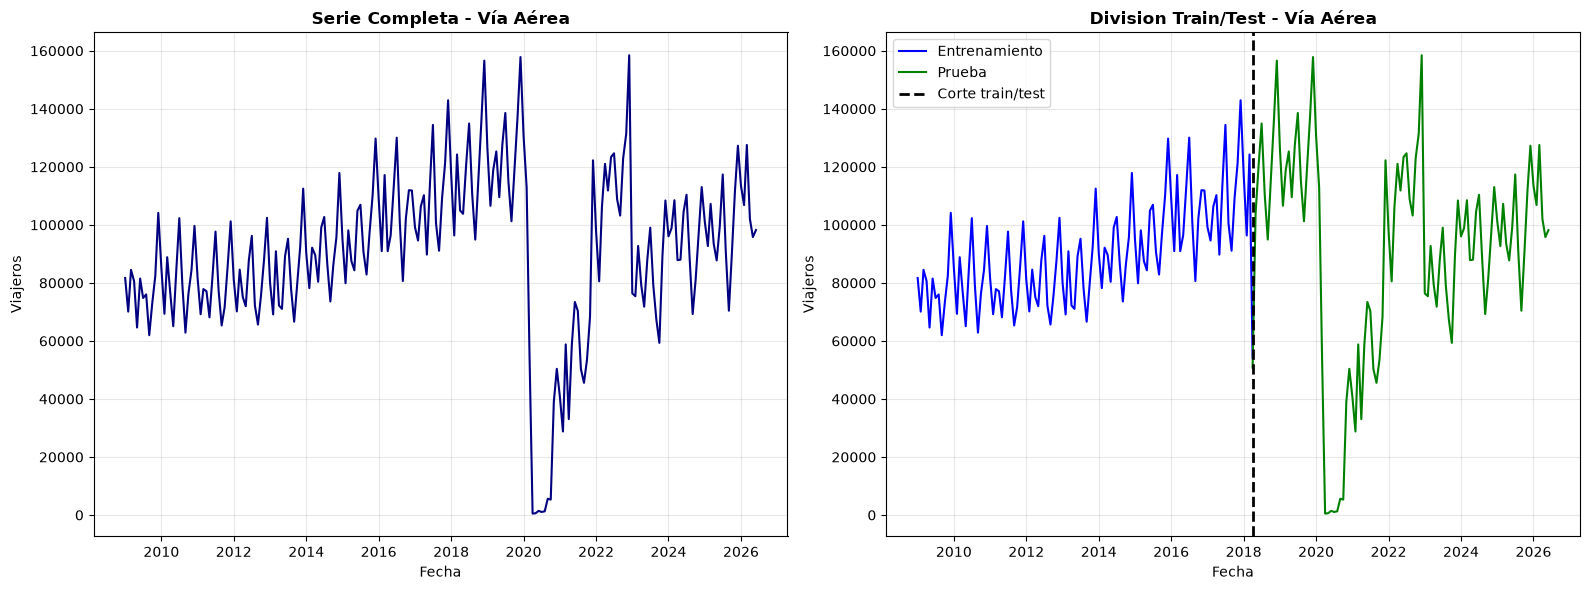

=== DESCOMPOSICION DE LA SERIE ===


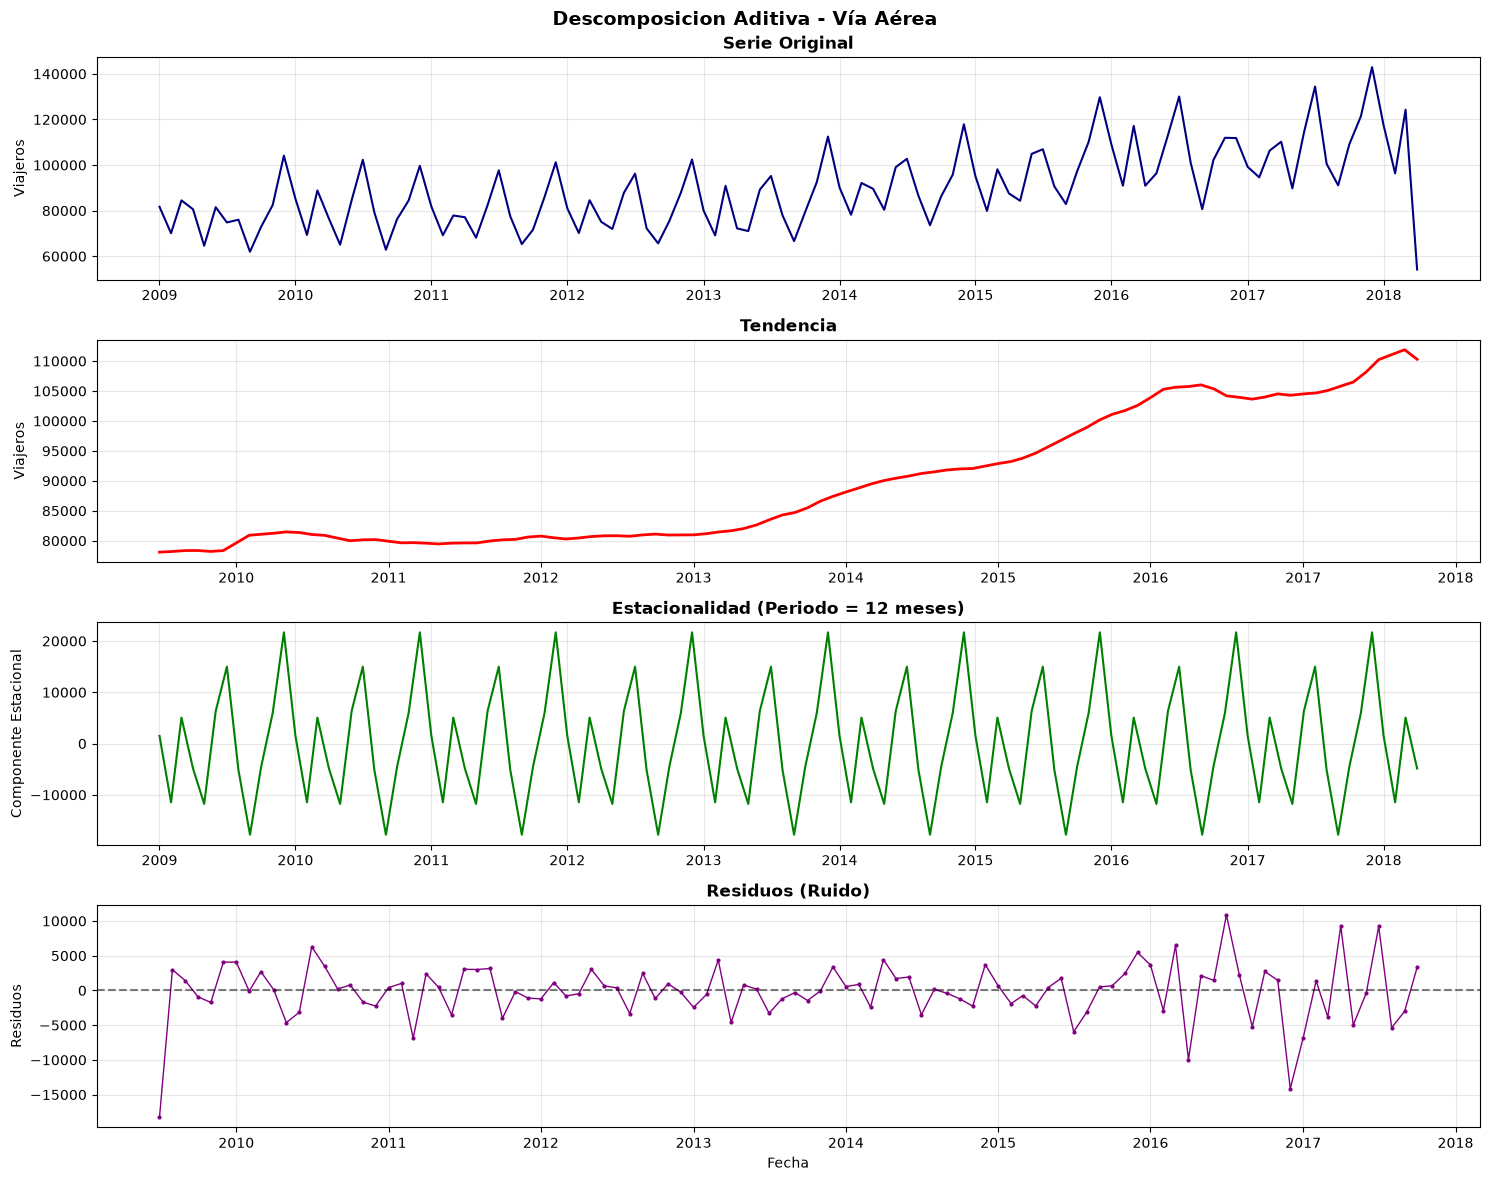

- Estacionariedad en media:
   Si la tendencia es crece o decrece = la media cambia con el tiempo

- Estacionariedad en varianza:
    Residuos tienen varianza relativamente estable, serie puede ser estacionaria en varianza
=== DETERMINACION DE TRANSFORMACION NECESARIA ===
Correlacion entre media y varianza: 0.858
Se recomienda transformacion logaritmica
  + Transformacion: log(Viajeros + 1)


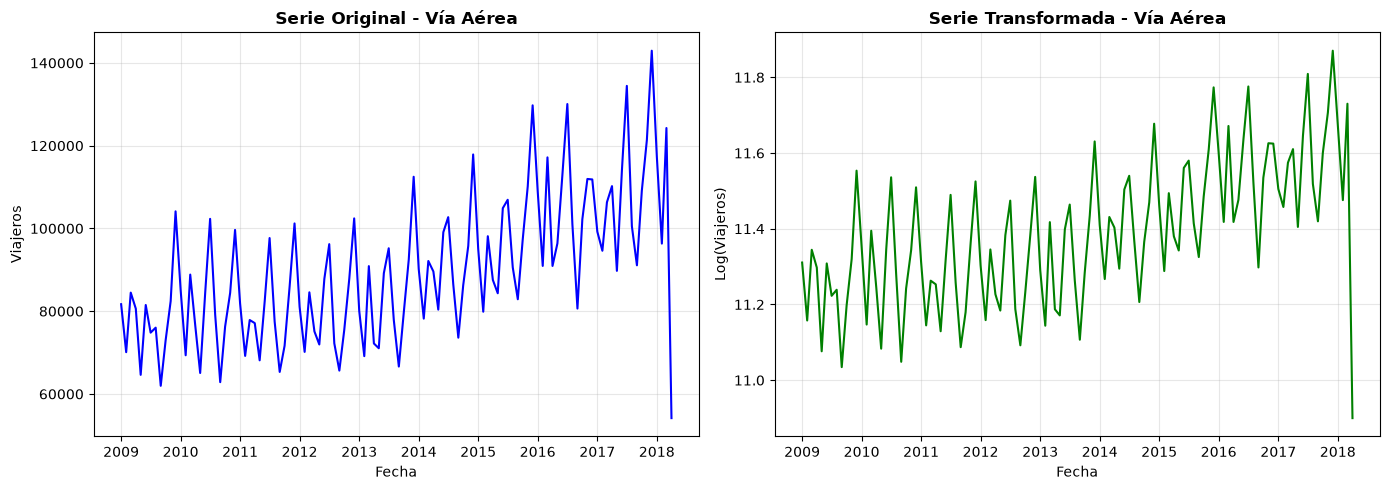

=== ANALISIS ESTACIONARIEDAD EN MEDIA ===

--- GRAFICO DE AUTOCORRELACION


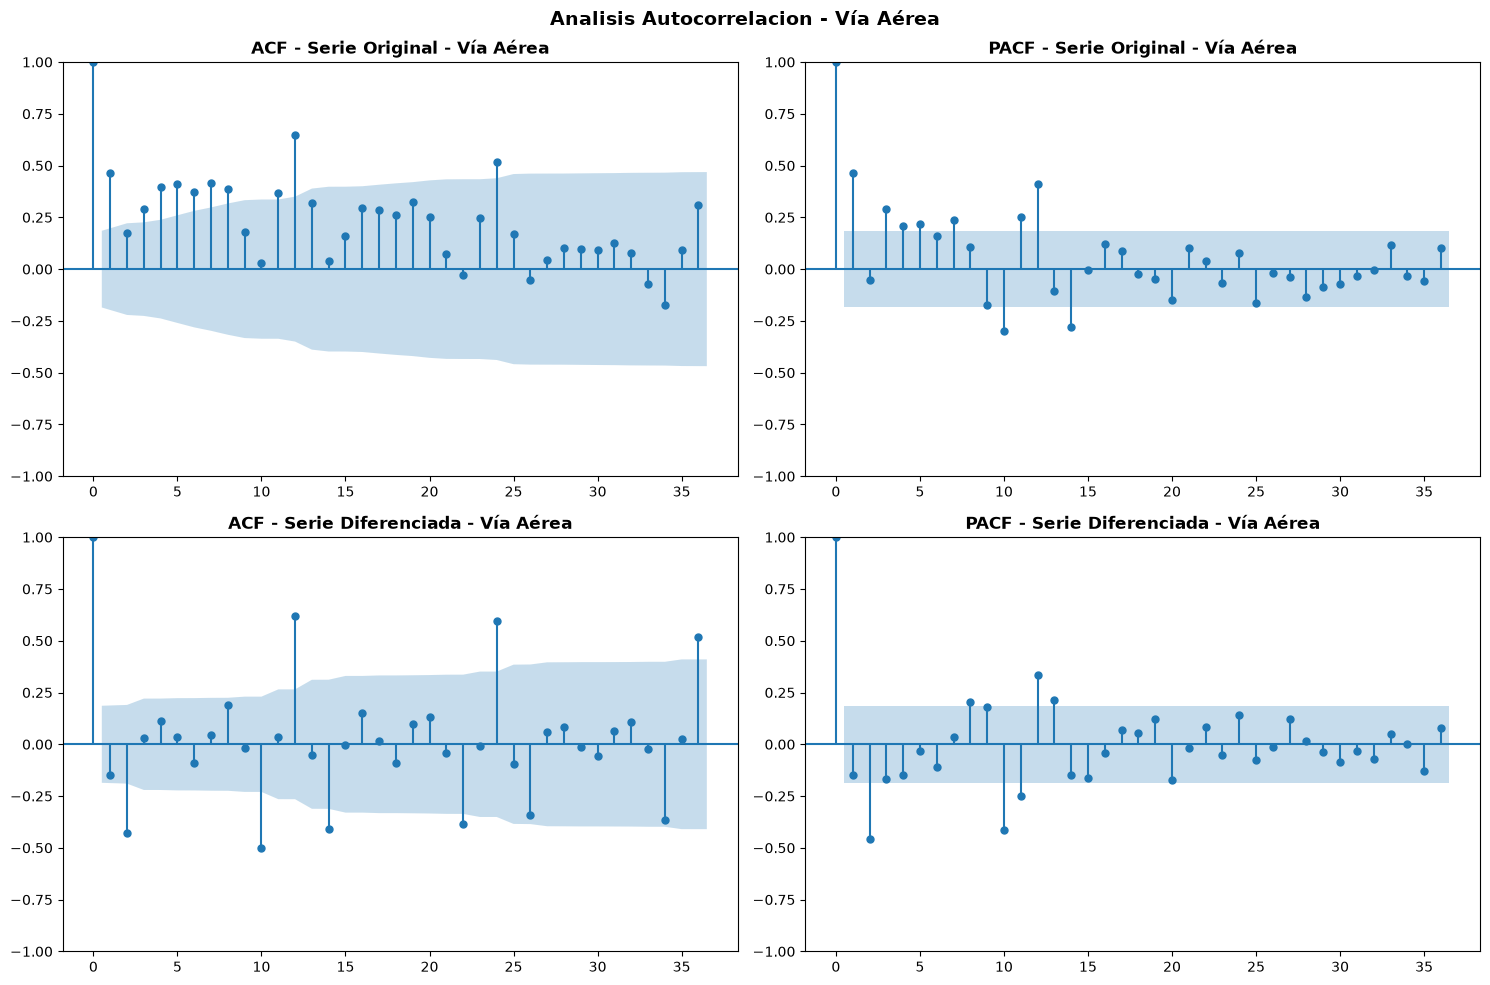


--- PRUEBA DE DICKEY-FULLER AUMENTADA

Resultados del Test de Dickey-Fuller - Serie transformada:
  Estadistico de prueba: -0.668907
  p-value: 0.854640
  No. retardos usados: 13
  No. observaciones usadas: 98
  Valores criticos:
    1%: -3.498910
    5%: -2.891516
    10%: -2.582760

Serie transformada no es estacionaria en media

Que hacer para hacerla estacionaria en media:
 Aplicar diferenciacion: y_t = y_t - y_{t-1}

Resultados del Test de Dickey-Fuller - 1era diferenciacion:
  Estadistico de prueba: -2.805995
  p-value: 0.057422
  No. retardos usados: 12
  No. observaciones usadas: 98
  Valores criticos:
    1%: -3.498910
    5%: -2.891516
    10%: -2.582760

1era diferenciacion no es estacionaria en media

Resultados del Test de Dickey-Fuller - 2da diferenciacion:
  Estadistico de prueba: -5.723520
  p-value: 0.000001
  No. retardos usados: 11
  No. observaciones usadas: 98
  Valores criticos:
    1%: -3.498910
    5%: -2.891516
    10%: -2.582760

2da diferenciacion es estacio

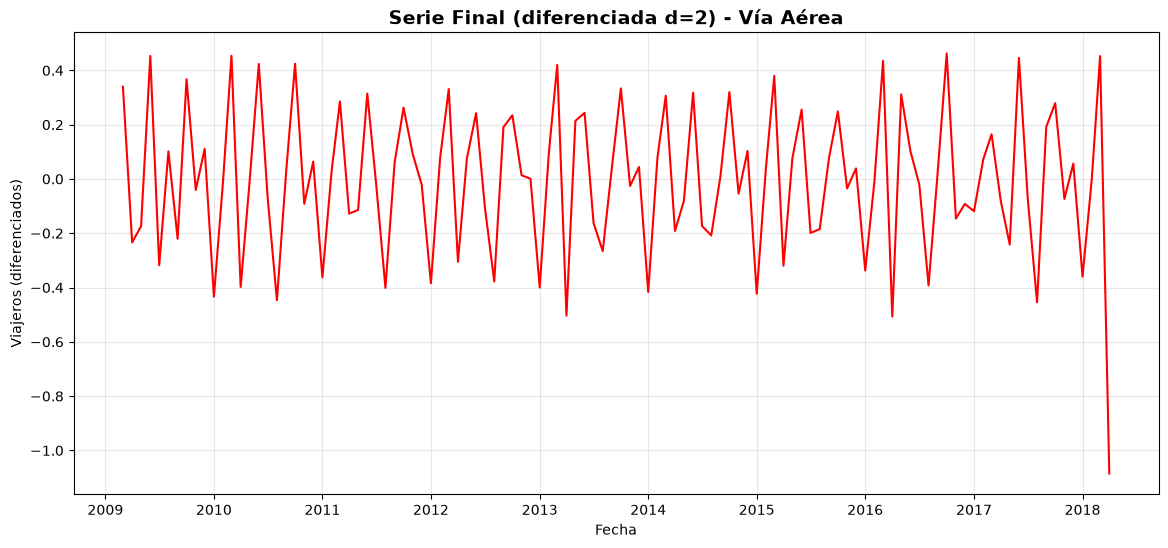

=== SELECCION DE PARAMETROS p, q y d ===

auto_arima para seleccion de parametros...
Performing stepwise search to minimize aic
 ARIMA(0,0,0)(1,0,1)[12] intercept   : AIC=4884.931, Time=0.43 sec
 ARIMA(0,0,0)(0,0,0)[12] intercept   : AIC=4897.559, Time=0.04 sec
 ARIMA(1,0,0)(1,0,0)[12] intercept   : AIC=4656.853, Time=0.69 sec
 ARIMA(0,0,1)(0,0,1)[12] intercept   : AIC=4775.090, Time=0.20 sec
 ARIMA(0,0,0)(0,0,0)[12]             : AIC=5410.671, Time=0.04 sec
 ARIMA(1,0,0)(0,0,0)[12] intercept   : AIC=4700.155, Time=0.07 sec
 ARIMA(1,0,0)(2,0,0)[12] intercept   : AIC=4658.171, Time=3.25 sec
 ARIMA(1,0,0)(1,0,1)[12] intercept   : AIC=4653.623, Time=0.80 sec
 ARIMA(1,0,0)(0,0,1)[12] intercept   : AIC=4654.742, Time=0.25 sec
 ARIMA(1,0,0)(2,0,1)[12] intercept   : AIC=inf, Time=3.06 sec
 ARIMA(1,0,0)(1,0,2)[12] intercept   : AIC=4652.200, Time=1.04 sec
 ARIMA(1,0,0)(0,0,2)[12] intercept   : AIC=4650.505, Time=0.53 sec
 ARIMA(0,0,0)(0,0,2)[12] intercept   : AIC=4882.654, Time=0.39 sec
 ARIMA

c:\Users\abbyd\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


  ARIMA(3,0,2) - AIC: 227.26, MAE: 7767.48
  ARIMA(5,0,0) - AIC: 224.72, MAE: 6741.57

Mejor modelo segun AIC: ARIMA(4,0,0)
   AIC: 223.93
   BIC: 244.01
   MAE: 6351.24
   RMSE: 9064.56

Analisis de residuos del mejor modelo:


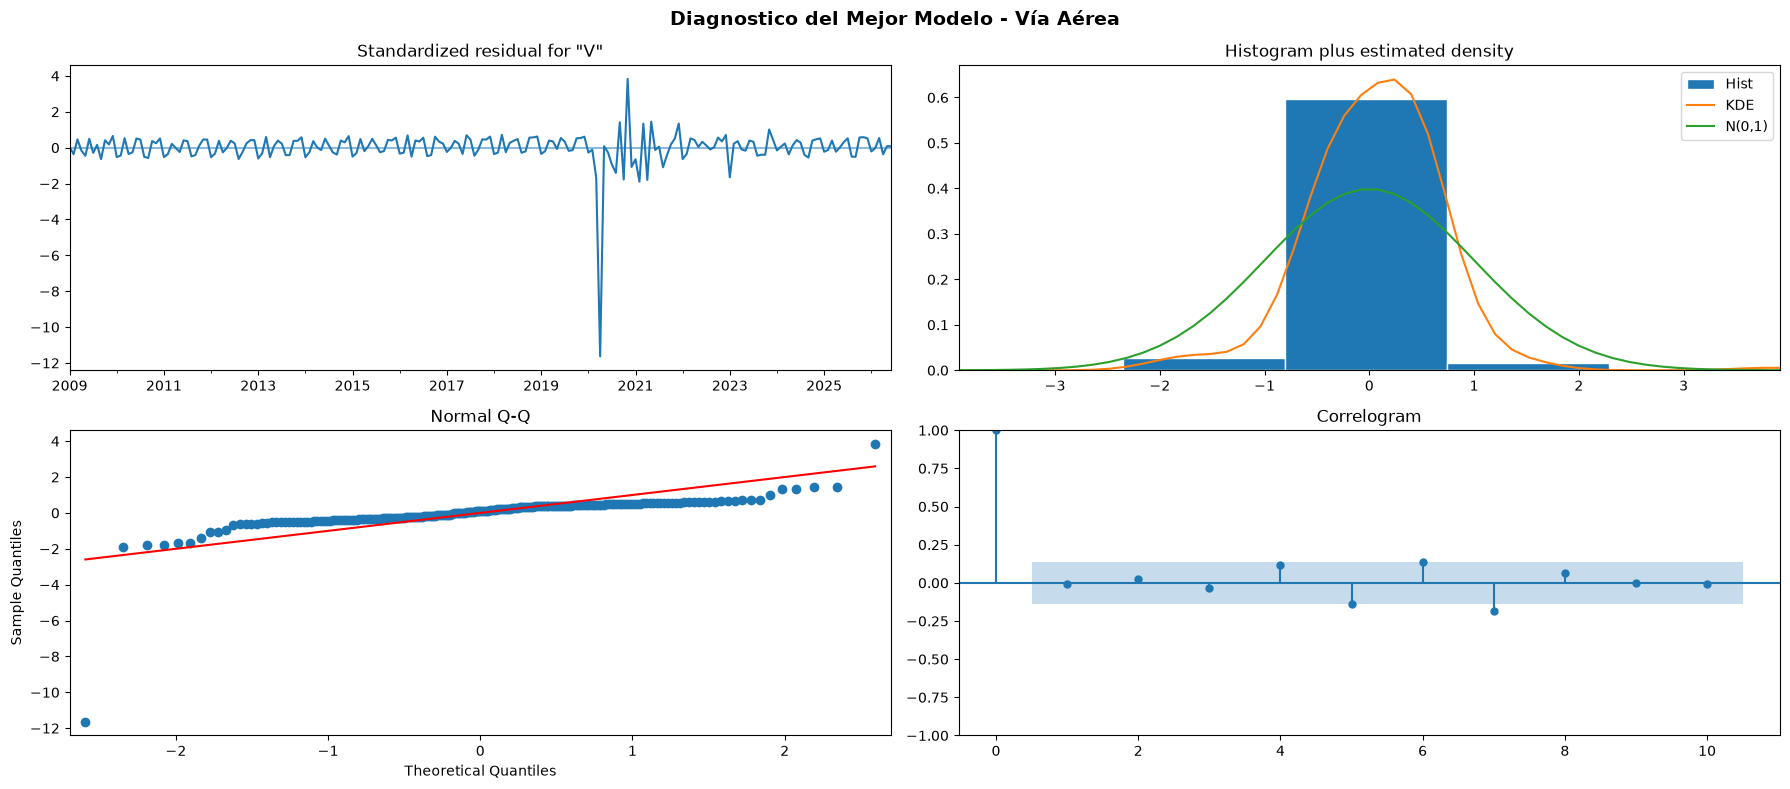

=== MODELOS ALTERNATIVOS ===

Holt-Winters:
   MAE: 35193.68, RMSE: 45963.32

Suavizamiento Exponencial Simple:
   MAE: 28222.43, RMSE: 39252.46

Seasonal Naive:
   MAE: 34388.21, RMSE: 45580.08

Comparacion modelos:
ARIMA (ARIMA(4,0,0)): MAE=6351.24, RMSE=9064.56
Holt-Winters: MAE=35193.68, RMSE=45963.32
Suavizamiento Exp.: MAE=28222.43, RMSE=39252.46
Seasonal Naive: MAE=34388.21, RMSE=45580.08

Mejor modelo alternativo segun MAE: Suavizamiento Exp.
   MAE: 28222.43
=== PREDICCION EN CONJUNTO DE PRUEBA ===


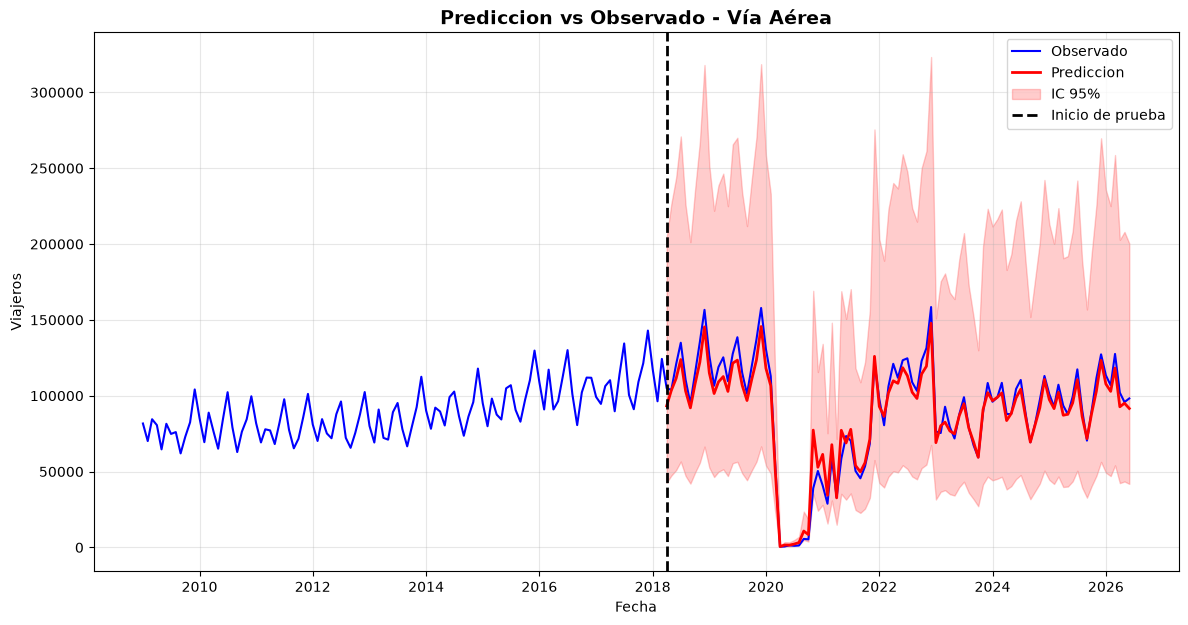


Predicciones para el conjunto de prueba:
  MAE: 6351.24
  RMSE: 9064.56
=== COMPARACION DE METRICAS ===
TABLA COMPARATIVA DE MODELOS:
            Modelo          MAE         RMSE        AIC        BIC
      ARIMA(4,0,0)  6351.240087  9064.555425 223.928848 244.011494
      Holt-Winters 35193.676943 45963.319891        NaN        NaN
Suavizamiento Exp. 28222.434739 39252.458744        NaN        NaN
    Seasonal Naive 34388.205634 45580.081098        NaN        NaN
=== SELECCION DEL MEJOR MODELO ===

MEJOR MODELO SEGUN MAE: ARIMA(4,0,0)
   MAE: 6351.24
   RMSE: 9064.56

MODELO SELECCIONADO FINALMENTE:
   ARIMA(4,0,0)
   - MAE: 6351.24
   - RMSE: 9064.56
   - AIC: 223.93
   - BIC: 244.01

Analisis completado exitosamente para Vía Aérea

ANALISIS DE SERIE DE TIEMPO - VIA: Terrestre
=== INICIO, FIN Y FRECUENCIA ===
  Inicio: 2009-01-01 00:00:00
  Fin: 2026-06-01 00:00:00
  Frecuencia: <MonthBegin>
  Numero de observaciones: 210
  Entrenamiento: 112 observaciones
  Prueba: 99 observaciones

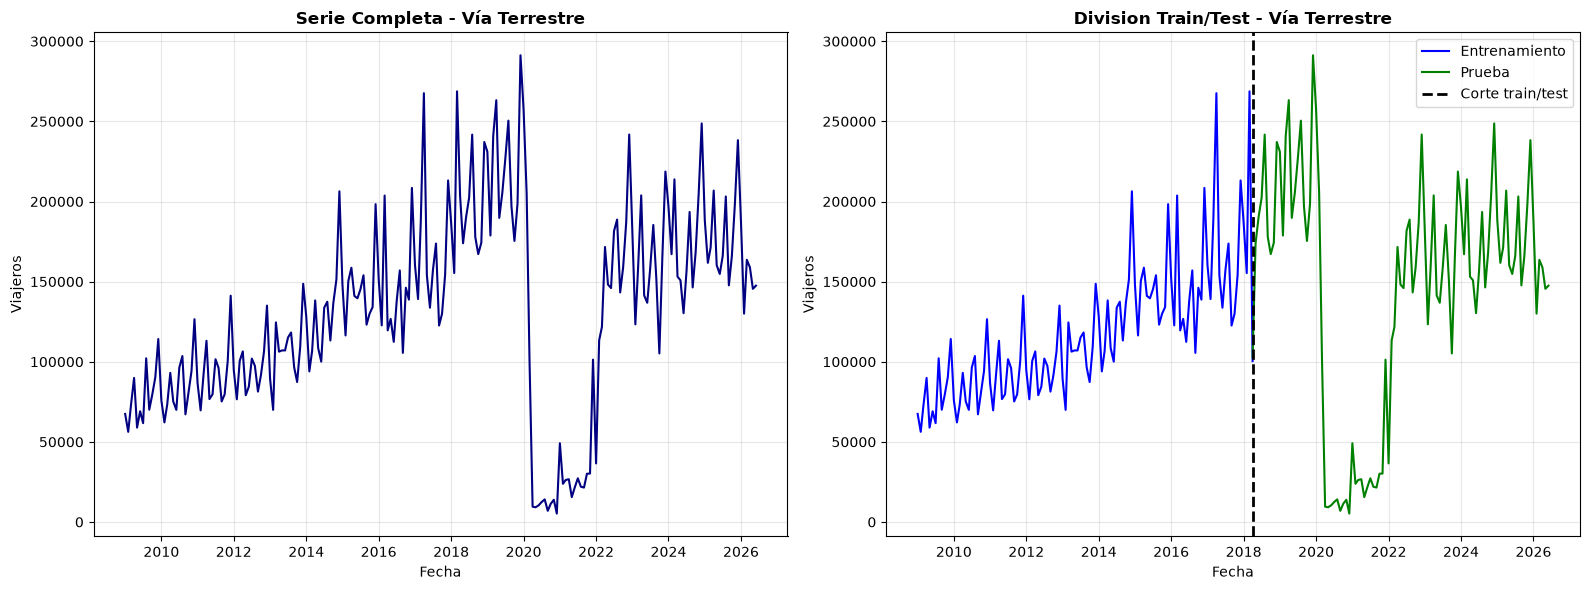

=== DESCOMPOSICION DE LA SERIE ===


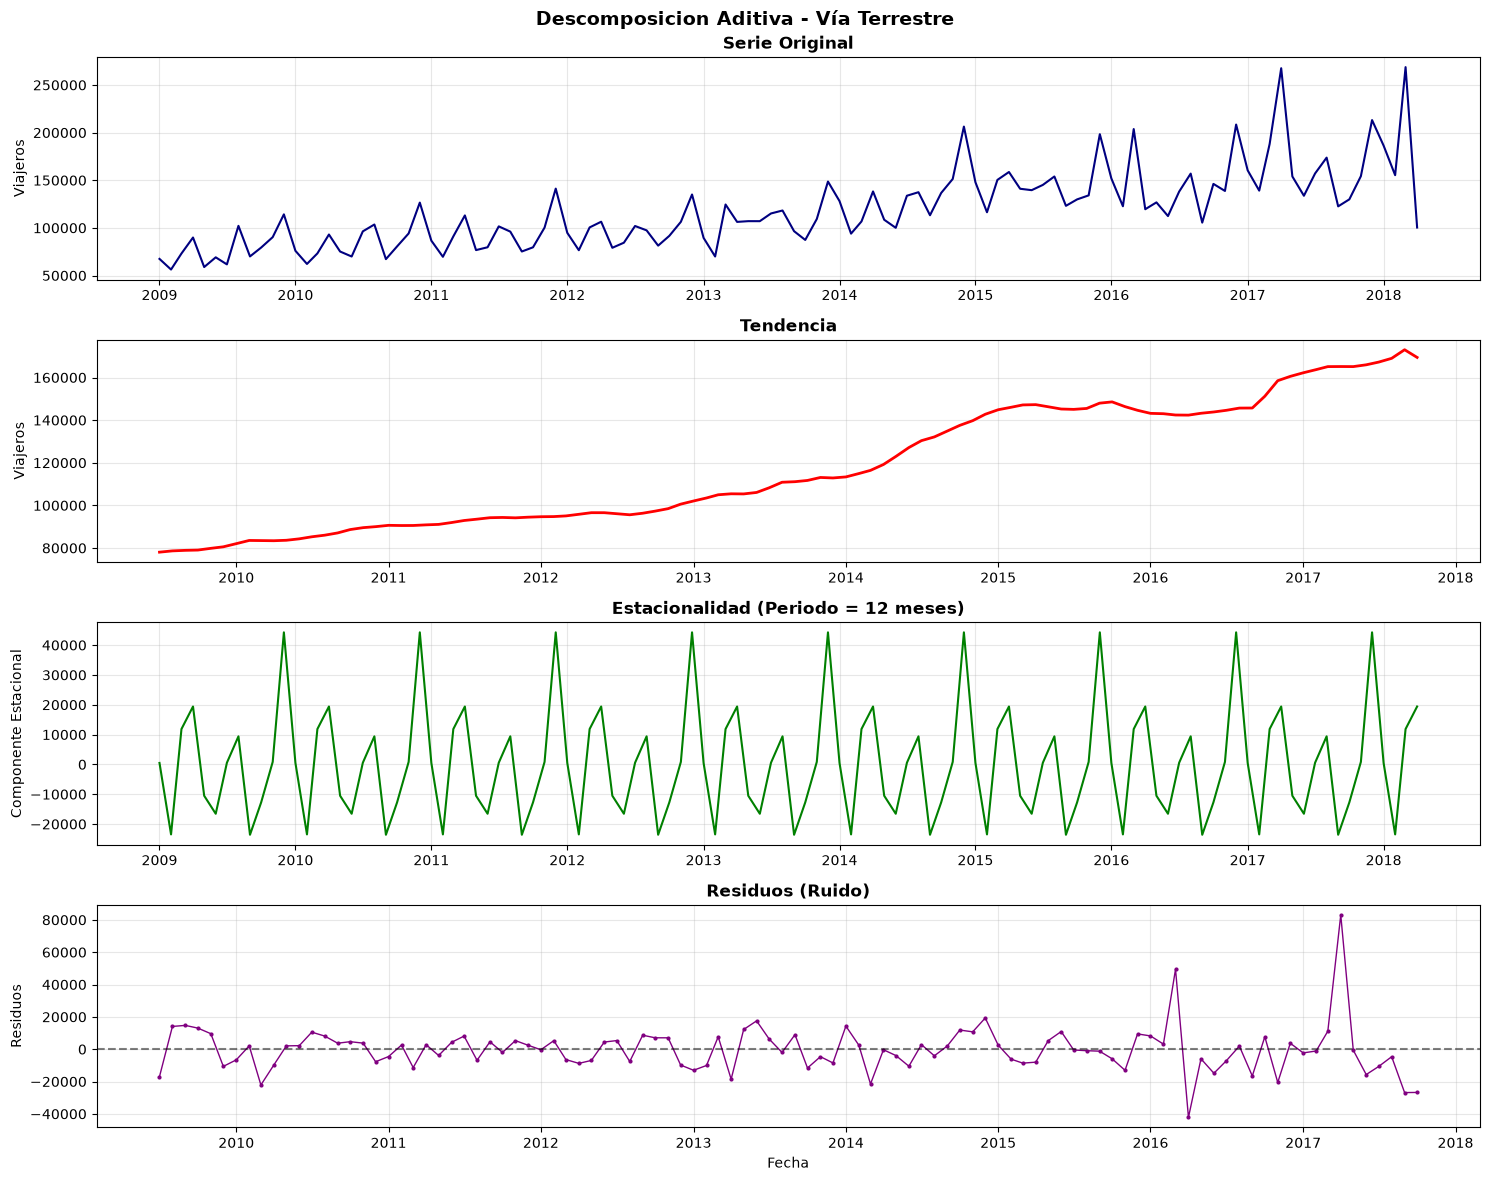

- Estacionariedad en media:
   Si la tendencia es crece o decrece = la media cambia con el tiempo

- Estacionariedad en varianza:
    Residuos tienen varianza relativamente estable, serie puede ser estacionaria en varianza
=== DETERMINACION DE TRANSFORMACION NECESARIA ===
Correlacion entre media y varianza: 0.830
Se recomienda transformacion logaritmica
  + Transformacion: log(Viajeros + 1)


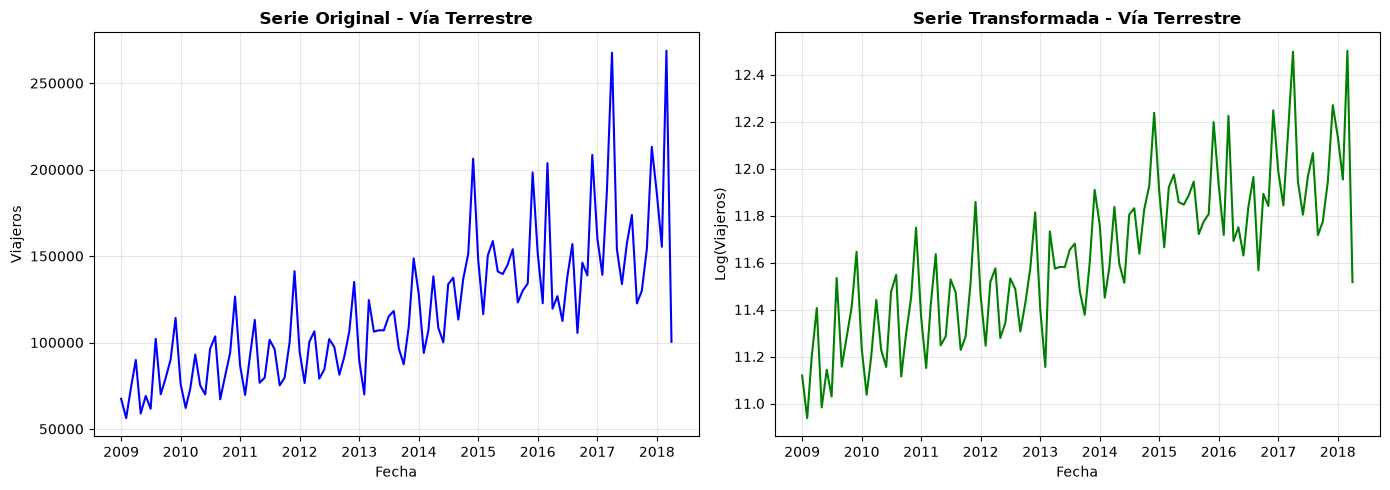

=== ANALISIS ESTACIONARIEDAD EN MEDIA ===

--- GRAFICO DE AUTOCORRELACION


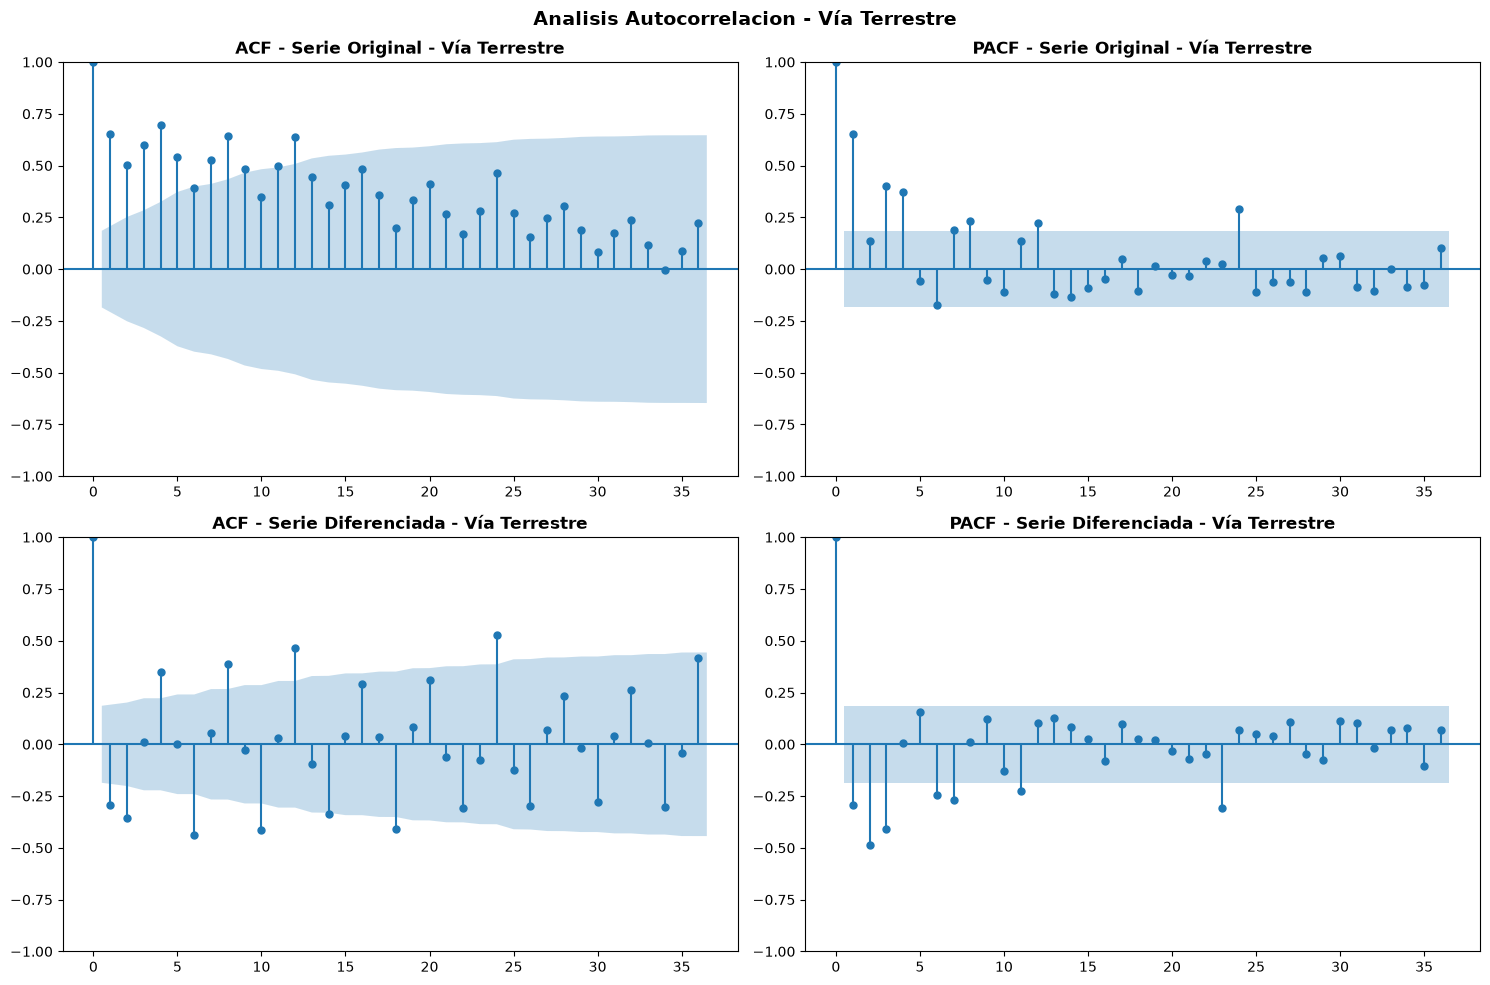


--- PRUEBA DE DICKEY-FULLER AUMENTADA

Resultados del Test de Dickey-Fuller - Serie transformada:
  Estadistico de prueba: -0.641857
  p-value: 0.861241
  No. retardos usados: 11
  No. observaciones usadas: 100
  Valores criticos:
    1%: -3.497501
    5%: -2.890906
    10%: -2.582435

Serie transformada no es estacionaria en media

Que hacer para hacerla estacionaria en media:
 Aplicar diferenciacion: y_t = y_t - y_{t-1}

Resultados del Test de Dickey-Fuller - 1era diferenciacion:
  Estadistico de prueba: -6.793290
  p-value: 0.000000
  No. retardos usados: 10
  No. observaciones usadas: 100
  Valores criticos:
    1%: -3.497501
    5%: -2.890906
    10%: -2.582435

1era diferenciacion es estacionaria en media

Diferenciacion necesaria: d = 1


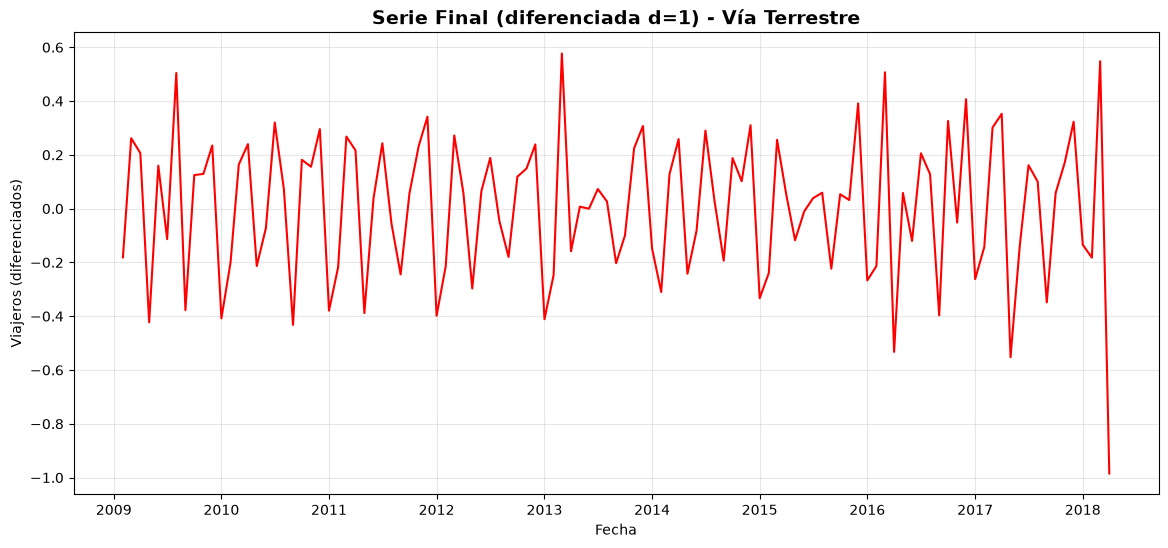

=== SELECCION DE PARAMETROS p, q y d ===

auto_arima para seleccion de parametros...
Performing stepwise search to minimize aic
 ARIMA(0,1,0)(1,0,1)[12] intercept   : AIC=4934.478, Time=0.35 sec
 ARIMA(0,1,0)(0,0,0)[12] intercept   : AIC=4992.183, Time=0.04 sec
 ARIMA(1,1,0)(1,0,0)[12] intercept   : AIC=4952.187, Time=0.22 sec
 ARIMA(0,1,1)(0,0,1)[12] intercept   : AIC=4954.633, Time=0.22 sec
 ARIMA(0,1,0)(0,0,0)[12]             : AIC=4990.208, Time=0.03 sec
 ARIMA(0,1,0)(0,0,1)[12] intercept   : AIC=4974.971, Time=0.14 sec
 ARIMA(0,1,0)(1,0,0)[12] intercept   : AIC=4962.837, Time=0.15 sec
 ARIMA(0,1,0)(2,0,1)[12] intercept   : AIC=4935.402, Time=0.83 sec
 ARIMA(0,1,0)(1,0,2)[12] intercept   : AIC=4935.720, Time=0.84 sec
 ARIMA(0,1,0)(0,0,2)[12] intercept   : AIC=4957.989, Time=0.35 sec
 ARIMA(0,1,0)(2,0,0)[12] intercept   : AIC=4945.421, Time=0.31 sec
 ARIMA(0,1,0)(2,0,2)[12] intercept   : AIC=inf, Time=2.10 sec
 ARIMA(1,1,0)(1,0,1)[12] intercept   : AIC=4924.153, Time=1.39 sec
 ARIMA

c:\Users\abbyd\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\statsmodels\tsa\statespace\sarimax.py:966: UserWarning: Non-stationary starting autoregressive parameters found. Using zeros as starting parameters.
  warn('Non-stationary starting autoregressive parameters'
c:\Users\abbyd\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\statsmodels\tsa\statespace\sarimax.py:978: UserWarning: Non-invertible starting MA parameters found. Using zeros as starting parameters.
  warn('Non-invertible starting MA parameters found.'
c:\Users\abbyd\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
c:\Users\abbyd\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\statsmodels\tsa\statespace\sarimax.py:966: UserWarning: Non-stationary starting autoregressive parameters found. Using zeros as

  ARIMA(3,1,2) - AIC: 141.18, MAE: 21783.99


c:\Users\abbyd\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
c:\Users\abbyd\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\statsmodels\tsa\statespace\sarimax.py:966: UserWarning: Non-stationary starting autoregressive parameters found. Using zeros as starting parameters.
  warn('Non-stationary starting autoregressive parameters'
c:\Users\abbyd\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\statsmodels\tsa\statespace\sarimax.py:978: UserWarning: Non-invertible starting MA parameters found. Using zeros as starting parameters.
  warn('Non-invertible starting MA parameters found.'


  ARIMA(3,1,3) - AIC: 168.27, MAE: 10355.59


c:\Users\abbyd\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


  ARIMA(4,1,2) - AIC: 152.60, MAE: 16271.80
  ARIMA(3,2,2) - AIC: 174.21, MAE: 10487.14
  ARIMA(0,1,1) - AIC: 162.10, MAE: 10207.42
  ARIMA(1,1,0) - AIC: 165.93, MAE: 8997.05
  ARIMA(2,1,1) - AIC: 164.92, MAE: 10317.77
  ARIMA(1,1,2) - AIC: 163.86, MAE: 10569.55


c:\Users\abbyd\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\statsmodels\tsa\statespace\sarimax.py:966: UserWarning: Non-stationary starting autoregressive parameters found. Using zeros as starting parameters.
  warn('Non-stationary starting autoregressive parameters'
c:\Users\abbyd\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\statsmodels\tsa\statespace\sarimax.py:978: UserWarning: Non-invertible starting MA parameters found. Using zeros as starting parameters.
  warn('Non-invertible starting MA parameters found.'
c:\Users\abbyd\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
c:\Users\abbyd\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\statsmodels\tsa\statespace\sarimax.py:966: UserWarning: Non-stationary starting autoregressive parameters found. Using zeros as

  ARIMA(3,1,4) - AIC: 167.13, MAE: 11601.35
  ARIMA(5,1,2) - AIC: 146.59, MAE: 14125.42

Mejor modelo segun AIC: ARIMA(3,1,2)
   AIC: 141.18
   BIC: 161.23
   MAE: 21783.99
   RMSE: 29699.18

Analisis de residuos del mejor modelo:


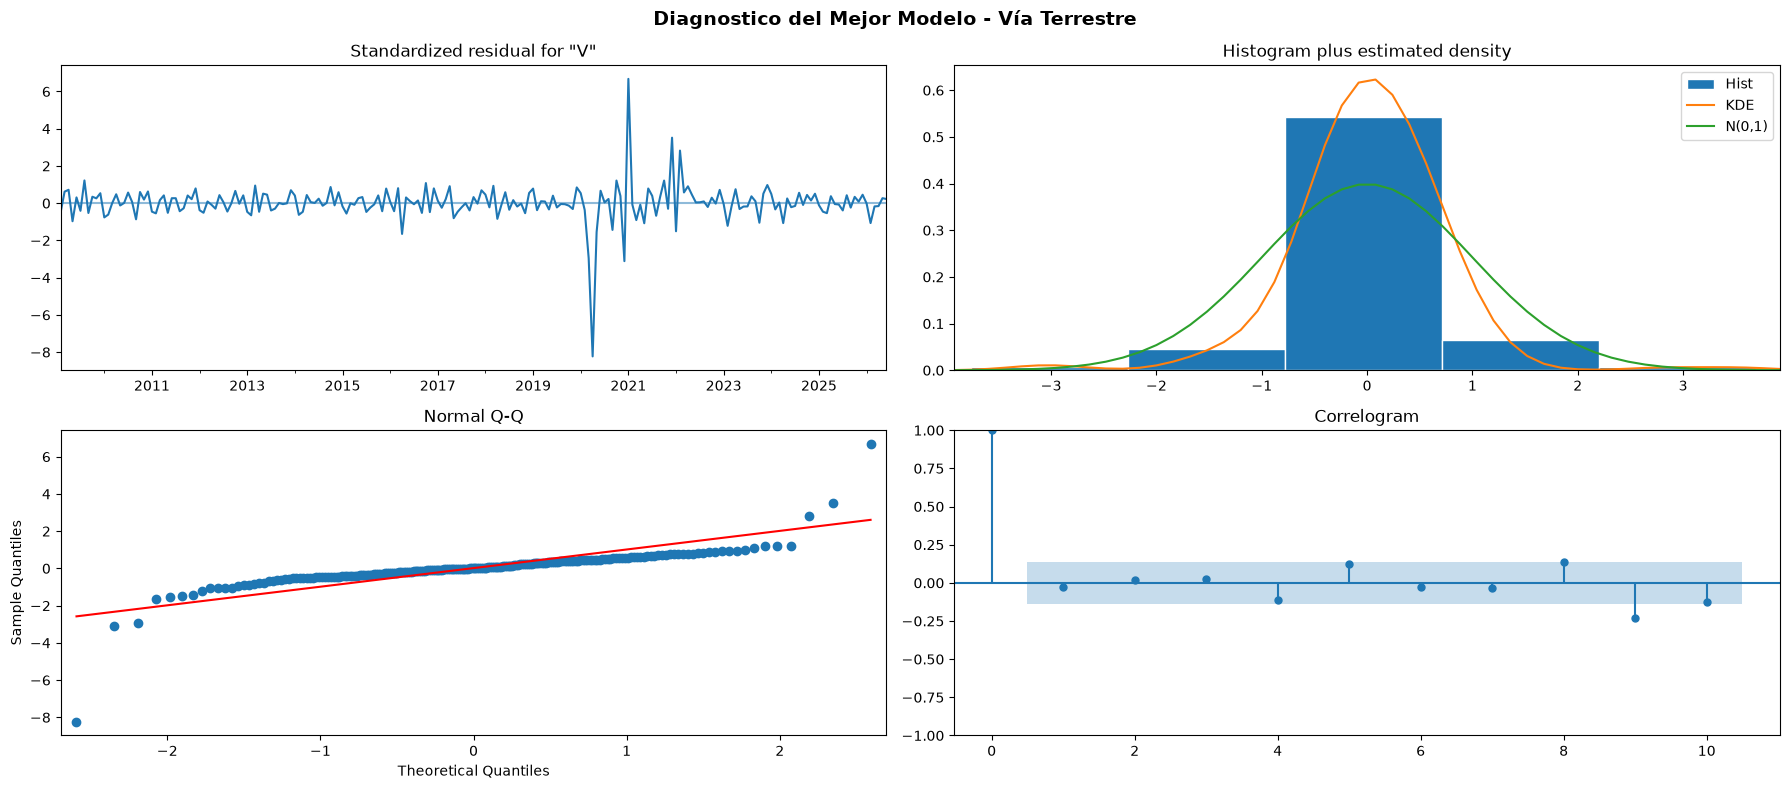

=== MODELOS ALTERNATIVOS ===

Holt-Winters:
   MAE: 86125.41, RMSE: 104532.67

Suavizamiento Exponencial Simple:
   MAE: 56561.93, RMSE: 77593.54

Seasonal Naive:
   MAE: 67241.84, RMSE: 86081.60

Comparacion modelos:
ARIMA (ARIMA(3,1,2)): MAE=21783.99, RMSE=29699.18
Holt-Winters: MAE=86125.41, RMSE=104532.67
Suavizamiento Exp.: MAE=56561.93, RMSE=77593.54
Seasonal Naive: MAE=67241.84, RMSE=86081.60

Mejor modelo alternativo segun MAE: Suavizamiento Exp.
   MAE: 56561.93
=== PREDICCION EN CONJUNTO DE PRUEBA ===


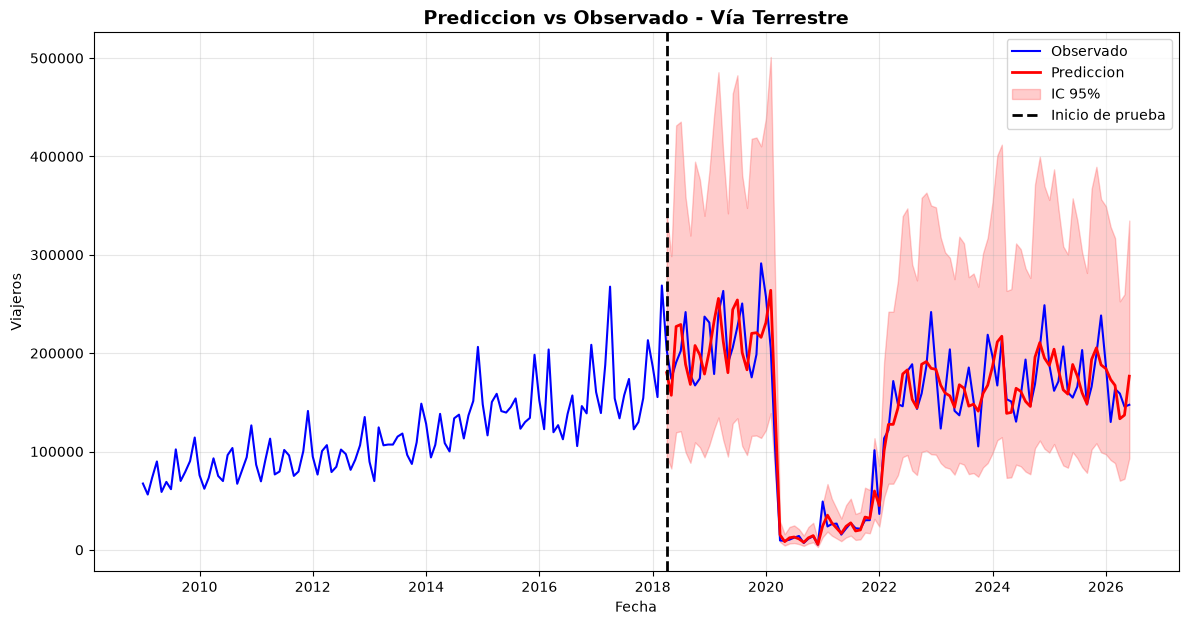


Predicciones para el conjunto de prueba:
  MAE: 21783.99
  RMSE: 29699.18
=== COMPARACION DE METRICAS ===
TABLA COMPARATIVA DE MODELOS:
            Modelo          MAE          RMSE        AIC        BIC
      ARIMA(3,1,2) 21783.994596  29699.175810 141.180749 161.234754
      Holt-Winters 86125.413985 104532.667211        NaN        NaN
Suavizamiento Exp. 56561.933339  77593.541829        NaN        NaN
    Seasonal Naive 67241.841139  86081.596384        NaN        NaN
=== SELECCION DEL MEJOR MODELO ===

MEJOR MODELO SEGUN MAE: ARIMA(3,1,2)
   MAE: 21783.99
   RMSE: 29699.18

MODELO SELECCIONADO FINALMENTE:
   ARIMA(3,1,2)
   - MAE: 21783.99
   - RMSE: 29699.18
   - AIC: 141.18
   - BIC: 161.23

Analisis completado exitosamente para Vía Terrestre

ANALISIS DE SERIE DE TIEMPO - VIA: Marítima
=== INICIO, FIN Y FRECUENCIA ===
  Inicio: 2009-01-01 00:00:00
  Fin: 2026-06-01 00:00:00
  Frecuencia: <MonthBegin>
  Numero de observaciones: 210
  Entrenamiento: 112 observaciones
  Prueba: 99

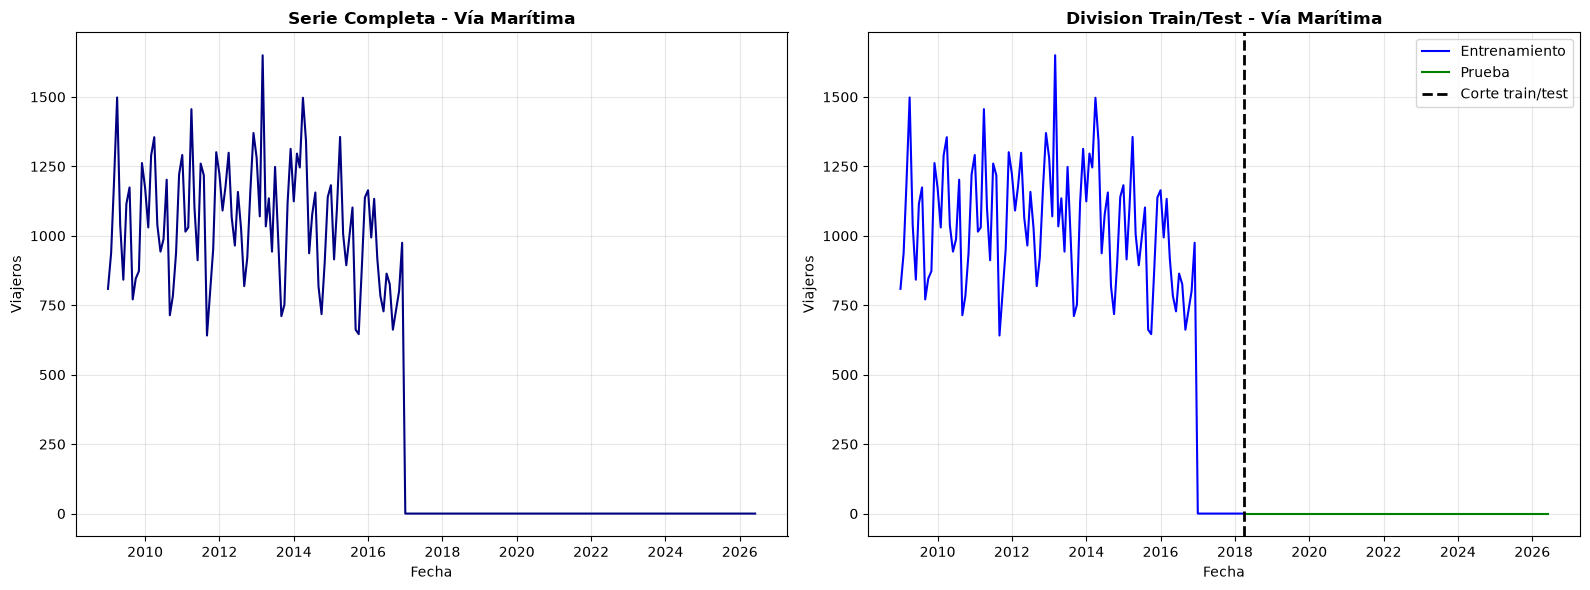

=== DESCOMPOSICION DE LA SERIE ===


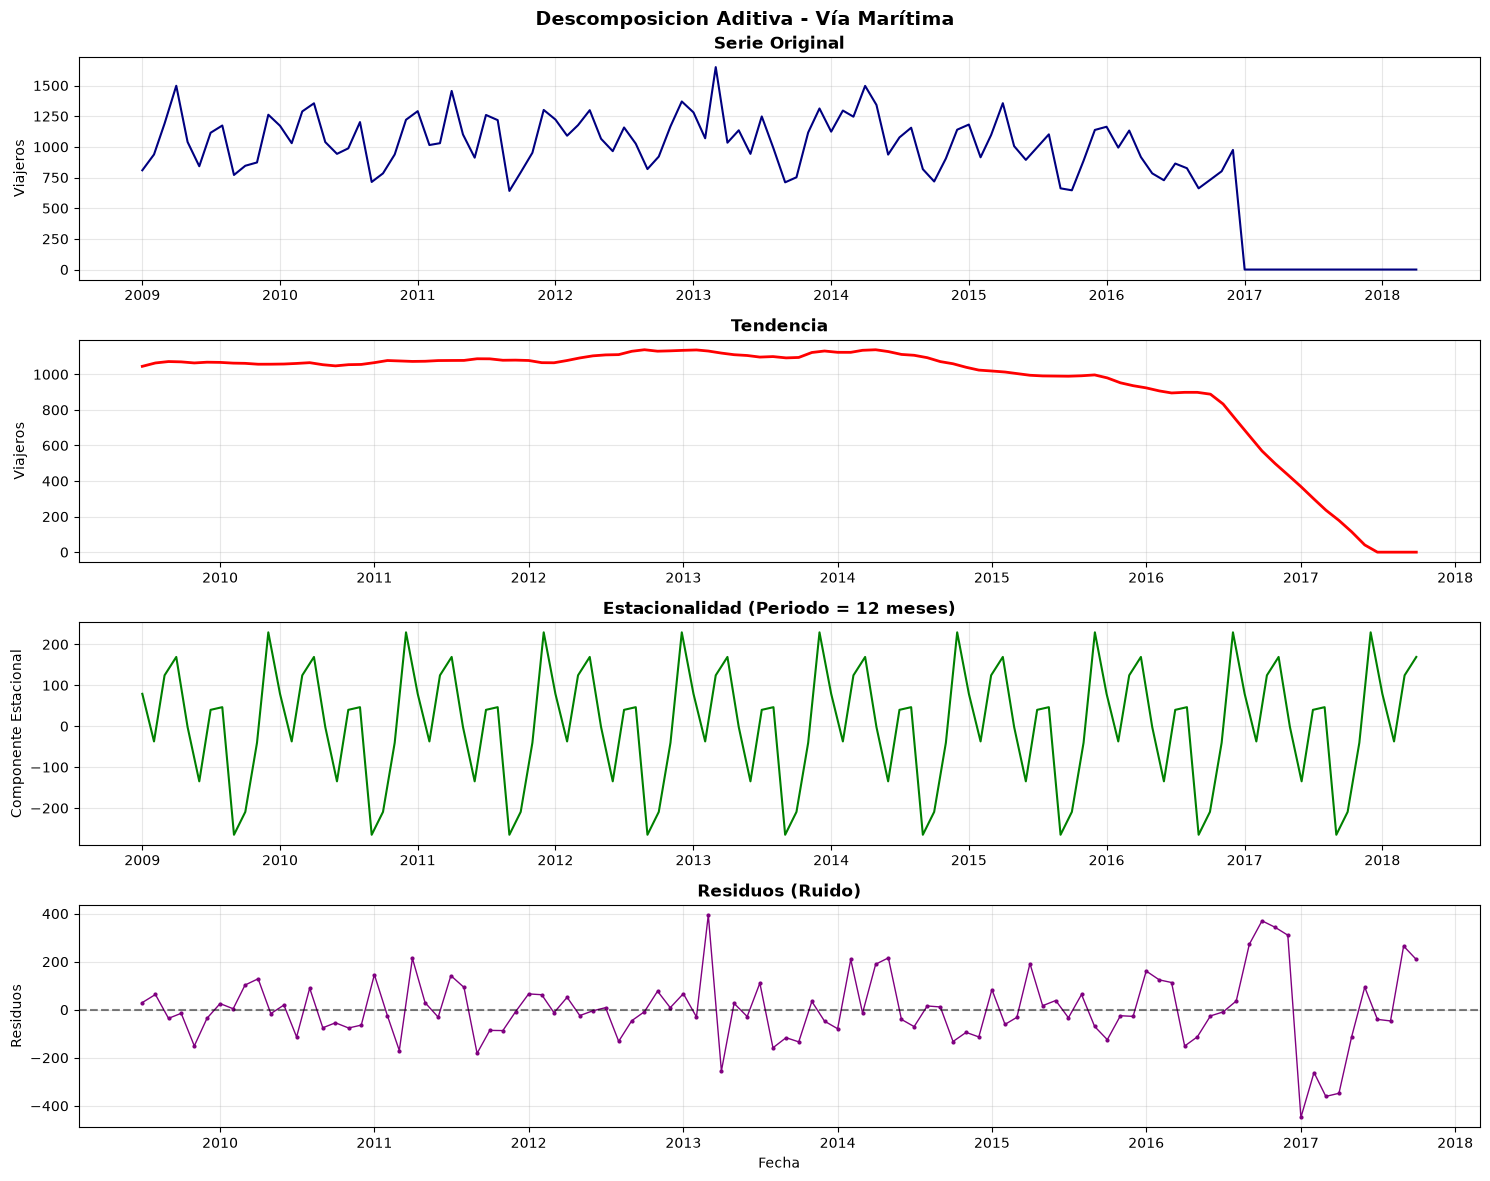

- Estacionariedad en media:
   Si la tendencia es crece o decrece = la media cambia con el tiempo

- Estacionariedad en varianza:
    Residuos tienen varianza relativamente estable, serie puede ser estacionaria en varianza
=== DETERMINACION DE TRANSFORMACION NECESARIA ===
Correlacion entre media y varianza: 0.512
Se recomienda transformacion logaritmica
  + Transformacion: log(Viajeros + 1)


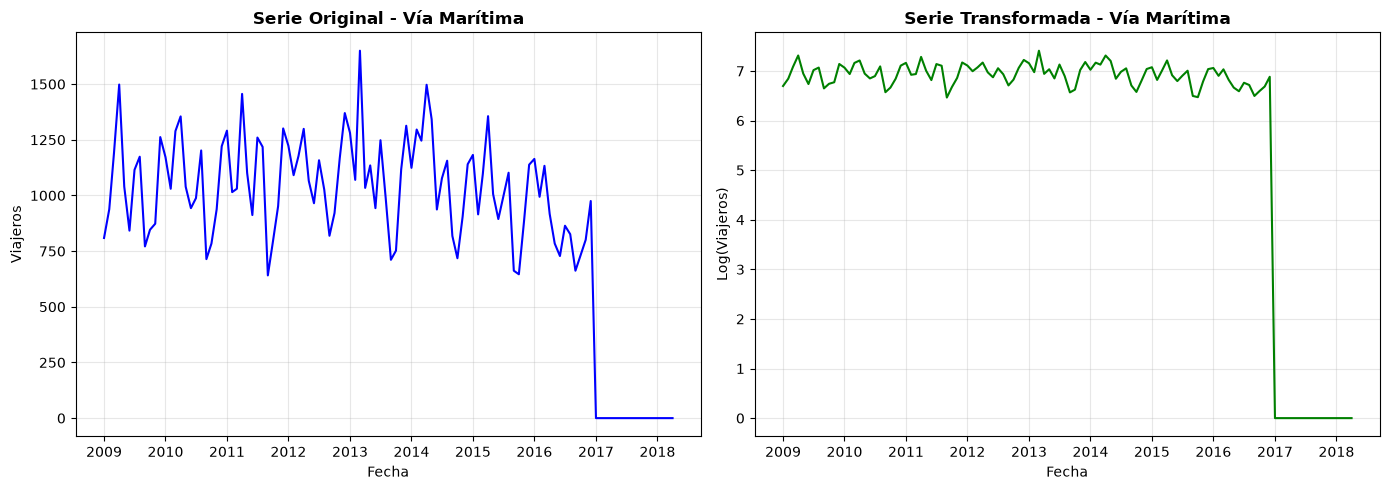

=== ANALISIS ESTACIONARIEDAD EN MEDIA ===

--- GRAFICO DE AUTOCORRELACION


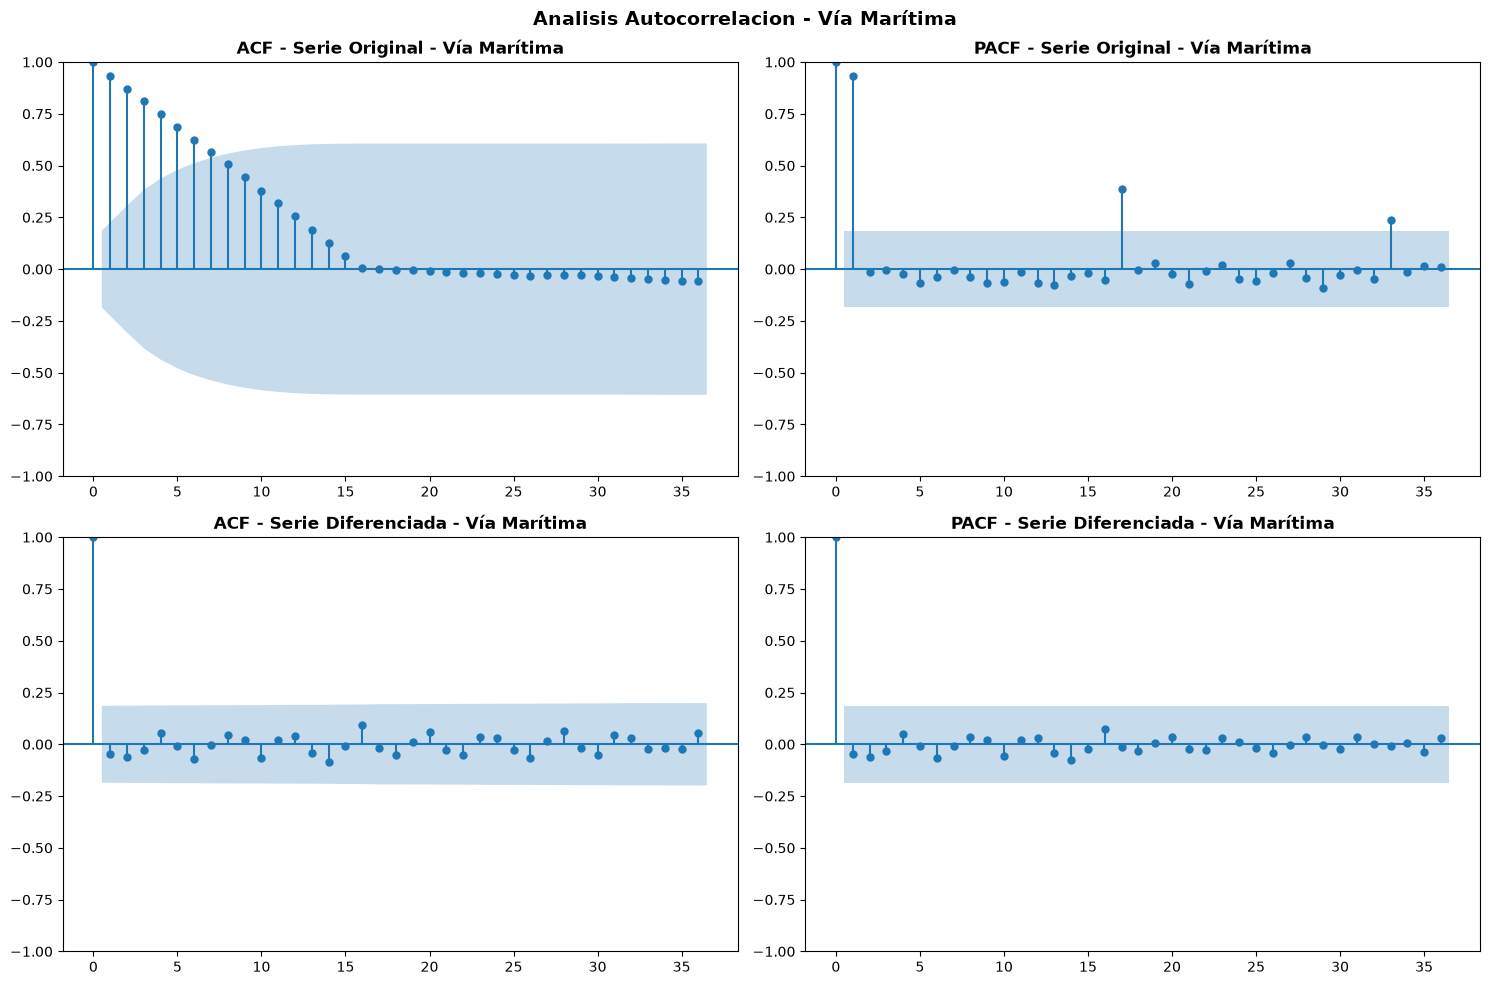


--- PRUEBA DE DICKEY-FULLER AUMENTADA

Resultados del Test de Dickey-Fuller - Serie transformada:
  Estadistico de prueba: -0.487977
  p-value: 0.894341
  No. retardos usados: 0
  No. observaciones usadas: 111
  Valores criticos:
    1%: -3.490683
    5%: -2.887952
    10%: -2.580857

Serie transformada no es estacionaria en media

Que hacer para hacerla estacionaria en media:
 Aplicar diferenciacion: y_t = y_t - y_{t-1}

Resultados del Test de Dickey-Fuller - 1era diferenciacion:
  Estadistico de prueba: -10.880821
  p-value: 0.000000
  No. retardos usados: 0
  No. observaciones usadas: 110
  Valores criticos:
    1%: -3.491245
    5%: -2.888195
    10%: -2.580988

1era diferenciacion es estacionaria en media

Diferenciacion necesaria: d = 1


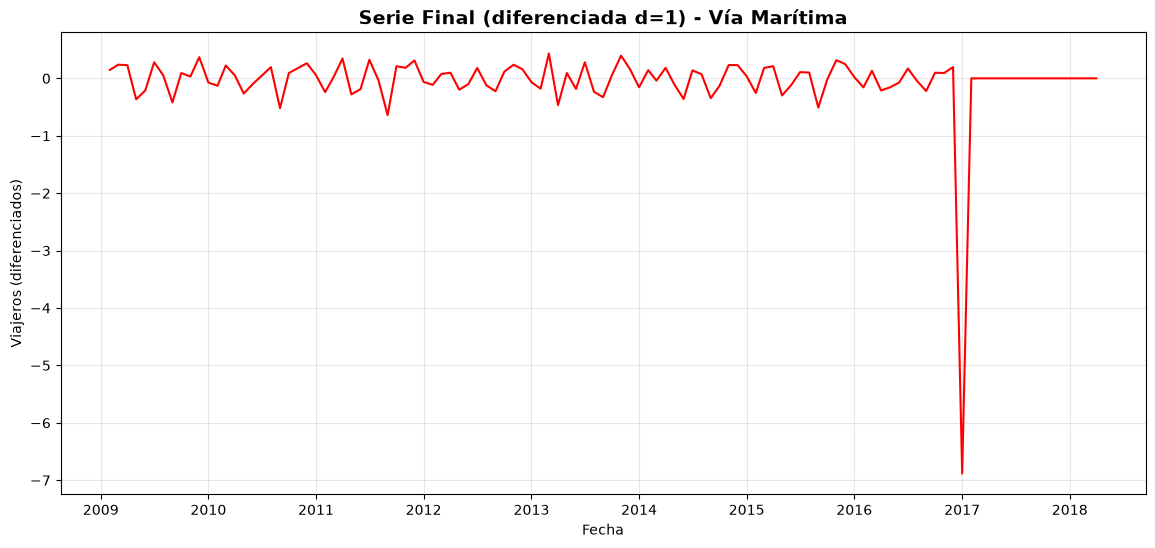

=== SELECCION DE PARAMETROS p, q y d ===

auto_arima para seleccion de parametros...
Performing stepwise search to minimize aic
 ARIMA(0,1,0)(1,0,1)[12] intercept   : AIC=2696.287, Time=1.05 sec
 ARIMA(0,1,0)(0,0,0)[12] intercept   : AIC=2755.213, Time=0.06 sec
 ARIMA(1,1,0)(1,0,0)[12] intercept   : AIC=2693.314, Time=1.26 sec
 ARIMA(0,1,1)(0,0,1)[12] intercept   : AIC=2697.182, Time=1.03 sec
 ARIMA(0,1,0)(0,0,0)[12]             : AIC=2753.316, Time=0.05 sec
 ARIMA(1,1,0)(0,0,0)[12] intercept   : AIC=2750.710, Time=0.13 sec
 ARIMA(1,1,0)(2,0,0)[12] intercept   : AIC=2686.948, Time=2.54 sec
 ARIMA(1,1,0)(2,0,1)[12] intercept   : AIC=2676.395, Time=2.98 sec
 ARIMA(1,1,0)(1,0,1)[12] intercept   : AIC=2674.401, Time=1.67 sec
 ARIMA(1,1,0)(0,0,1)[12] intercept   : AIC=2711.991, Time=0.64 sec
 ARIMA(1,1,0)(1,0,2)[12] intercept   : AIC=2676.388, Time=4.16 sec
 ARIMA(1,1,0)(0,0,2)[12] intercept   : AIC=2707.787, Time=1.75 sec
 ARIMA(1,1,0)(2,0,2)[12] intercept   : AIC=inf, Time=9.10 sec
 ARIMA

c:\Users\abbyd\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\statsmodels\tsa\statespace\sarimax.py:966: UserWarning: Non-stationary starting autoregressive parameters found. Using zeros as starting parameters.
  warn('Non-stationary starting autoregressive parameters'
c:\Users\abbyd\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


  ARIMA(3,1,2) - AIC: 314.32, MAE: 0.03
  ARIMA(5,1,0) - AIC: 313.75, MAE: 0.00

Mejor modelo segun AIC: ARIMA(0,1,1)
   AIC: 307.16
   BIC: 313.84
   MAE: 0.00
   RMSE: 0.00

Analisis de residuos del mejor modelo:


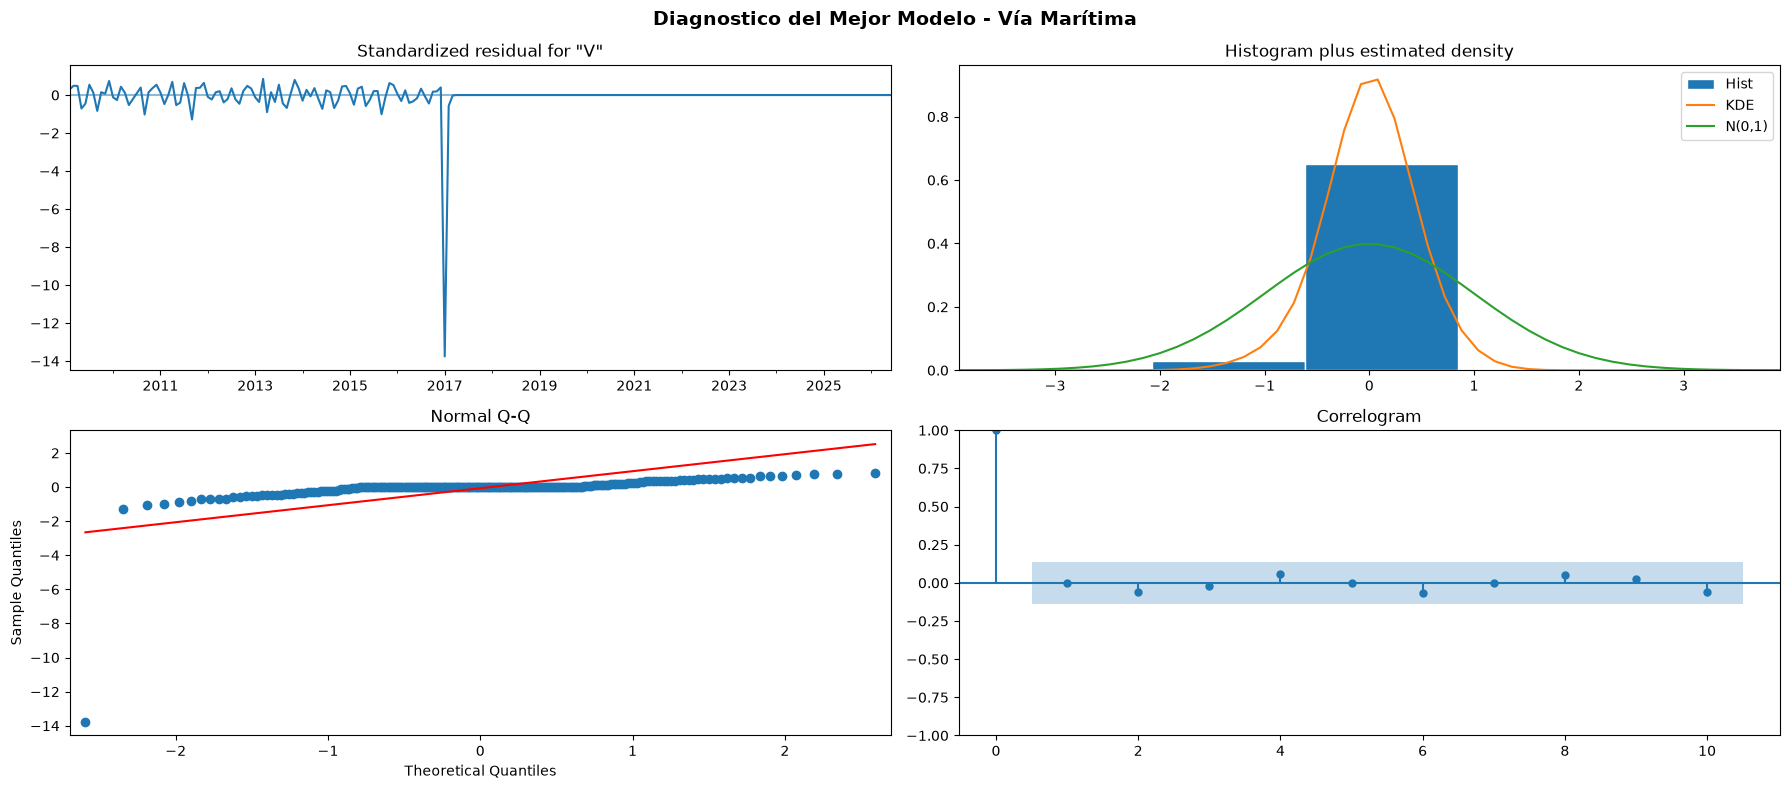

=== MODELOS ALTERNATIVOS ===

Holt-Winters:
   MAE: 625.40, RMSE: 691.77

Suavizamiento Exponencial Simple:
   MAE: 0.02, RMSE: 0.02

Seasonal Naive:
   MAE: 0.00, RMSE: 0.00

Comparacion modelos:
ARIMA (ARIMA(0,1,1)): MAE=0.00, RMSE=0.00
Holt-Winters: MAE=625.40, RMSE=691.77
Suavizamiento Exp.: MAE=0.02, RMSE=0.02
Seasonal Naive: MAE=0.00, RMSE=0.00

Mejor modelo alternativo segun MAE: Seasonal Naive
   MAE: 0.00
=== PREDICCION EN CONJUNTO DE PRUEBA ===


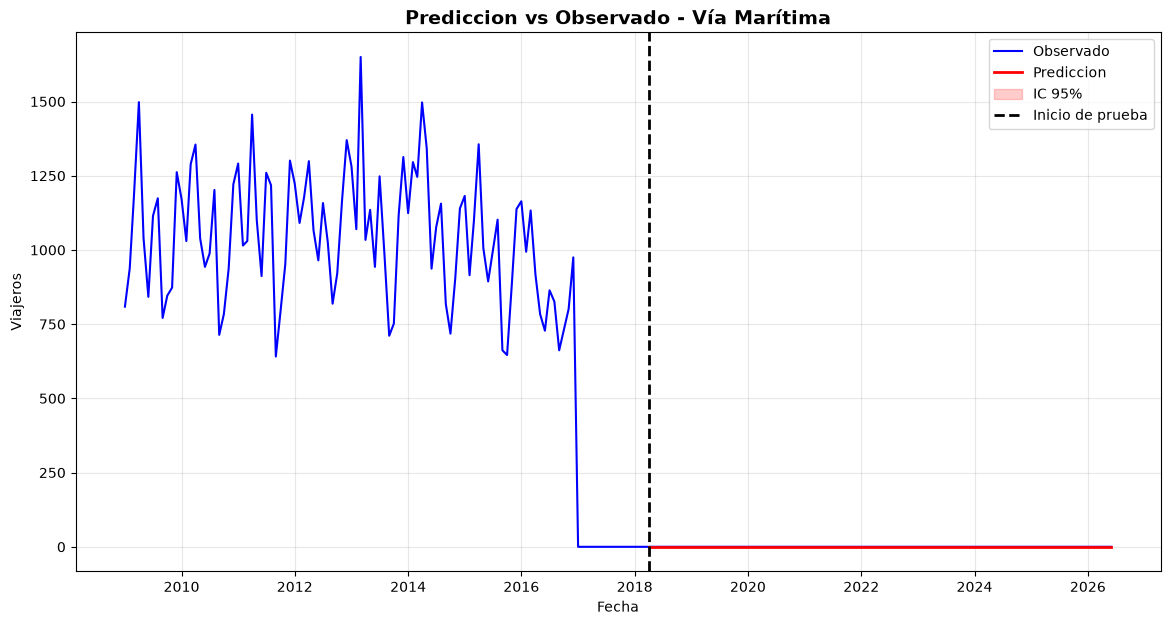


Predicciones para el conjunto de prueba:
  MAE: 0.00
  RMSE: 0.00
=== COMPARACION DE METRICAS ===
TABLA COMPARATIVA DE MODELOS:
            Modelo        MAE       RMSE        AIC        BIC
      ARIMA(0,1,1)   0.000000   0.000000 307.158849 313.843518
      Holt-Winters 625.401133 691.769042        NaN        NaN
Suavizamiento Exp.   0.019318   0.019318        NaN        NaN
    Seasonal Naive   0.000000   0.000000        NaN        NaN
=== SELECCION DEL MEJOR MODELO ===

MEJOR MODELO SEGUN MAE: ARIMA(0,1,1)
   MAE: 0.00
   RMSE: 0.00

MODELO SELECCIONADO FINALMENTE:
   ARIMA(0,1,1)
   - MAE: 0.00
   - RMSE: 0.00
   - AIC: 307.16
   - BIC: 313.84

Analisis completado exitosamente para Vía Marítima

       Via Mejor Modelo          MAE         RMSE        AIC        BIC
    Aérea ARIMA(4,0,0)  6351.240087  9064.555425 223.928848 244.011494
Terrestre ARIMA(3,1,2) 21783.994596 29699.175810 141.180749 161.234754
 Marítima ARIMA(0,1,1)     0.000000     0.000000 307.158849 313.843518
RESU

In [12]:
#VÍAS DE INGRESO (AEREA, TERRESTRE, MARITIMA)
print("=== VIAS DE INGRESO ===")

#serei mensual
series_vias = {}

vias_ingreso = df_filtracion['Vía'].unique()
print(f"Vías de ingreso disponibles: {vias_ingreso}")

for via in vias_ingreso:
    df_via = df_filtracion[df_filtracion['Vía'] == via]
    serie_mensual = df_via.groupby('Fecha')['Viajero'].sum()

    fecha_min = df_filtracion['Fecha'].min()
    fecha_max = df_filtracion['Fecha'].max()

    months = pd.date_range(start=fecha_min, end=fecha_max, freq='MS')

    serie_mensual = serie_mensual.reindex(months, fill_value=0)
    series_vias[via] = serie_mensual

print("\n=== SERIES DE VIAS DE INGRESO ===")
for via, serie in series_vias.items():
    print(f"\n»» {via}")
    print(f"  + Rango: {serie.index.min()} -- {serie.index.max()}")
    print(f"  + Frecuencia: {serie.index.freq if serie.index.freq else 'Mensual (no especificada)'}")
    print(f"  + No. observaciones: {len(serie)}")
    print(f"  + Observaciones completas: {serie.count()}")
    print(f"  + Periodos sin datos: {(serie == 0).sum()}")
    print(f"  + Total viajeros: {serie.sum():,.0f}")

def analisis_serie_via(serie_analisis, train_df, test_df, nom_via):
    print(f"\n{'='*70}")
    print(f"ANALISIS DE SERIE DE TIEMPO - VIA: {nom_via}")
    print(f"{'='*70}")
    
    print("=== INICIO, FIN Y FRECUENCIA ===")
    
    print(f"  Inicio: {serie_analisis.index.min()}")
    print(f"  Fin: {serie_analisis.index.max()}")
    print(f"  Frecuencia: {serie_analisis.index.freq if serie_analisis.index.freq else 'Mensual'}")
    print(f"  Numero de observaciones: {len(serie_analisis)}")
    
    train_serie = train_df[train_df['Vía'] == nom_via].groupby('Fecha')['Viajero'].sum()
    train_serie = train_serie.reindex(pd.date_range(start=train_df['Fecha'].min(), 
                                                    end=train_df['Fecha'].max(), 
                                                    freq='MS'), fill_value=0)
    
    test_serie = test_df[test_df['Vía'] == nom_via].groupby('Fecha')['Viajero'].sum()
    test_serie = test_serie.reindex(pd.date_range(start=test_df['Fecha'].min(), 
                                                  end=test_df['Fecha'].max(), 
                                                  freq='MS'), fill_value=0)
    
    print(f"  Entrenamiento: {len(train_serie)} observaciones")
    print(f"  Prueba: {len(test_serie)} observaciones")
    
    print("=== GRAFICO DE SERIE ===")
    
    fig, axes = plt.subplots(1, 2, figsize=(16, 6))
    
    #serie completa
    axes[0].plot(serie_analisis.index, serie_analisis.values, color='navy', linewidth=1.5)
    axes[0].set_title(f'Serie Completa - Vía {nom_via}', fontsize=12, weight='bold')
    axes[0].set_xlabel('Fecha')
    axes[0].set_ylabel('Viajeros')
    axes[0].grid(True, alpha=0.3)
    
    #train vs test
    axes[1].plot(train_serie.index, train_serie.values, color='blue', linewidth=1.5, label='Entrenamiento')
    axes[1].plot(test_serie.index, test_serie.values, color='green', linewidth=1.5, label='Prueba')
    axes[1].axvline(x=train_serie.index[-1], color='black', linestyle='--', linewidth=2, label='Corte train/test')
    axes[1].set_title(f'Division Train/Test - Vía {nom_via}', fontsize=12, weight='bold')
    axes[1].set_xlabel('Fecha')
    axes[1].set_ylabel('Viajeros')
    axes[1].legend()
    axes[1].grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()
    
    
    print("=== DESCOMPOSICION DE LA SERIE ===")
    
    if len(train_serie) >= 24:
        descomposicion = seasonal_decompose(train_serie, model='additive', period=12)
        
        fig, axes = plt.subplots(4, 1, figsize=(15, 12))
        
        axes[0].plot(descomposicion.observed.index, descomposicion.observed.values, color='navy', linewidth=1.5)
        axes[0].set_title('Serie Original', fontsize=12, weight='bold')
        axes[0].set_ylabel('Viajeros')
        axes[0].grid(True, alpha=0.3)
        
        axes[1].plot(descomposicion.trend.index, descomposicion.trend.values, color='red', linewidth=2)
        axes[1].set_title('Tendencia', fontsize=12, weight='bold')
        axes[1].set_ylabel('Viajeros')
        axes[1].grid(True, alpha=0.3)
        
        axes[2].plot(descomposicion.seasonal.index, descomposicion.seasonal.values, color='green', linewidth=1.5)
        axes[2].set_title('Estacionalidad (Periodo = 12 meses)', fontsize=12, weight='bold')
        axes[2].set_ylabel('Componente Estacional')
        axes[2].grid(True, alpha=0.3)
        
        axes[3].plot(descomposicion.resid.index, descomposicion.resid.values, color='purple', linewidth=1, marker='o', markersize=2)
        axes[3].axhline(y=0, color='black', linestyle='--', alpha=0.5)
        axes[3].set_title('Residuos (Ruido)', fontsize=12, weight='bold')
        axes[3].set_xlabel('Fecha')
        axes[3].set_ylabel('Residuos')
        axes[3].grid(True, alpha=0.3)
        
        plt.suptitle(f'Descomposicion Aditiva - Vía {nom_via}', fontsize=14, weight='bold')
        plt.tight_layout()
        plt.show()
        
        print("- Estacionariedad en media:")
        print("   Si la tendencia es crece o decrece = la media cambia con el tiempo")
        print("\n- Estacionariedad en varianza:")
        resid_std_ratio = descomposicion.resid.std() / train_serie.mean() if train_serie.mean() > 0 else 0
        if resid_std_ratio < 0.3:
            print("    Residuos tienen varianza relativamente estable, serie puede ser estacionaria en varianza")
        else:
            print("    Varianza de los residuos es alta en relacion a la media, serie no es estacionaria en varianza")
            print("    + Se requiere transfromacion")
        
    else:
        print("Datos insuficientes para descomposicion")
    
    print("=== DETERMINACION DE TRANSFORMACION NECESARIA ===")
    
    media_ventanas = []
    var_ventanas = []
    for i in range(0, len(train_serie), 12):
        if i+12 <= len(train_serie):
            ventana = train_serie.iloc[i:i+12]
            if ventana.mean() > 0:
                media_ventanas.append(ventana.mean())
                var_ventanas.append(ventana.var())
    
    if len(media_ventanas) > 1:
        corr_media_var = np.corrcoef(media_ventanas, var_ventanas)[0, 1]
        print(f"Correlacion entre media y varianza: {corr_media_var:.3f}")
        
        if corr_media_var > 0.5:
            print("Se recomienda transformacion logaritmica") #crece
            ts_transformada = np.log1p(train_serie)
            print("  + Transformacion: log(Viajeros + 1)")
        else:
            print("No se requiere transformacion logaritmica") #no crece
            ts_transformada = train_serie.copy()
    else:
        print("Datos insuficientes para evaluar transformacion")
        ts_transformada = train_serie.copy()
    
    #gra transformacion
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    
    axes[0].plot(train_serie.index, train_serie.values, color='blue', linewidth=1.5)
    axes[0].set_title(f'Serie Original - Vía {nom_via}', fontsize=12, weight='bold')
    axes[0].set_xlabel('Fecha')
    axes[0].set_ylabel('Viajeros')
    axes[0].grid(True, alpha=0.3)
    
    axes[1].plot(ts_transformada.index, ts_transformada.values, color='green', linewidth=1.5)
    axes[1].set_title(f'Serie Transformada - Vía {nom_via}', fontsize=12, weight='bold')
    axes[1].set_xlabel('Fecha')
    axes[1].set_ylabel('Log(Viajeros)')
    axes[1].grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()
    
   
    print("=== ANALISIS ESTACIONARIEDAD EN MEDIA ===")
    print("\n--- GRAFICO DE AUTOCORRELACION")
    
    fig, axes = plt.subplots(2, 2, figsize=(15, 10))
    
    # ACF y PACF original
    plot_acf(ts_transformada.dropna(), lags=min(36, len(ts_transformada)-2), ax=axes[0, 0], alpha=0.05)
    axes[0, 0].set_title(f'ACF - Serie Original - Vía {nom_via}', fontsize=12, weight='bold')
    
    plot_pacf(ts_transformada.dropna(), lags=min(36, len(ts_transformada)-2), ax=axes[0, 1], alpha=0.05, method='ywm')
    axes[0, 1].set_title(f'PACF - Serie Original - Vía {nom_via}', fontsize=12, weight='bold')
    
    # ACF y PACF transformada
    if not adfuller(ts_transformada.dropna())[1] <= 0.05:
        ts_diff = ts_transformada.diff().dropna()
        plot_acf(ts_diff, lags=min(36, len(ts_diff)-1), ax=axes[1, 0], alpha=0.05)
        axes[1, 0].set_title(f'ACF - Serie Diferenciada - Vía {nom_via}', fontsize=12, weight='bold')
        
        plot_pacf(ts_diff, lags=min(36, len(ts_diff)-1), ax=axes[1, 1], alpha=0.05, method='ywm')
        axes[1, 1].set_title(f'PACF - Serie Diferenciada - Vía {nom_via}', fontsize=12, weight='bold')
    else:
        axes[1, 0].axis('off')
        axes[1, 1].axis('off')
        axes[1, 0].text(0.5, 0.5, 'La serie ya es estacionaria\nNo requiere diferenciacion', 
                        transform=axes[1, 0].transAxes, ha='center', va='center',
                        fontsize=12, bbox=dict(boxstyle='round', facecolor='lightgreen', alpha=0.5))
        axes[1, 1].axis('off')
    
    plt.suptitle(f'Analisis Autocorrelacion - Vía {nom_via}', fontsize=14, weight='bold')
    plt.tight_layout()
    plt.show()
    
    print("\n--- PRUEBA DE DICKEY-FULLER AUMENTADA")
    
    def realizar_adf(serie, nombre="Serie"):
        serie_clean = serie.dropna()
        if len(serie_clean) < 3:
            print(f"Datos insuficientes para prueba ADF")
            return False, None
            
        dfTest = adfuller(serie_clean, autolag='AIC')
        print(f'\nResultados del Test de Dickey-Fuller - {nombre}:')
        print(f'  Estadistico de prueba: {dfTest[0]:.6f}')
        print(f'  p-value: {dfTest[1]:.6f}')
        print(f'  No. retardos usados: {dfTest[2]}')
        print(f'  No. observaciones usadas: {dfTest[3]}')
        print('  Valores criticos:')
        for key, value in dfTest[4].items():
            print(f'    {key}: {value:.6f}')
        
        if dfTest[1] <= 0.05:
            print(f'\n{nombre} es estacionaria en media')
            return True, dfTest[1]
        else:
            print(f'\n{nombre} no es estacionaria en media')
            return False, dfTest[1]
    
    estacionaria, p_valor = realizar_adf(ts_transformada, "Serie transformada")
    
    d = 0
    if not estacionaria:
        print("\nQue hacer para hacerla estacionaria en media:")
        print(" Aplicar diferenciacion: y_t = y_t - y_{t-1}")
        
        ts_diff1 = ts_transformada.diff().dropna()
        estacionaria1, p_valor1 = realizar_adf(ts_diff1, "1era diferenciacion")
        
        if not estacionaria1:
            ts_diff2 = ts_diff1.diff().dropna()
            estacionaria2, p_valor2 = realizar_adf(ts_diff2, "2da diferenciacion")
            d = 2 if estacionaria2 else 3
            ts_final = ts_diff2 if estacionaria2 else ts_diff2.diff().dropna()
        else:
            d = 1
            ts_final = ts_diff1
    else:
        ts_final = ts_transformada
    
    print(f"\nDiferenciacion necesaria: d = {d}")
    
    #graficas filan
    plt.figure(figsize=(14, 6))
    plt.plot(ts_final.index, ts_final.values, color='red', linewidth=1.5)
    plt.title(f'Serie Final (diferenciada d={d}) - Vía {nom_via}', fontsize=14, weight='bold')
    plt.xlabel('Fecha')
    plt.ylabel('Viajeros (diferenciados)')
    plt.grid(True, alpha=0.3)
    plt.show()
    

    print("=== SELECCION DE PARAMETROS p, q y d ===")   

    print("\nauto_arima para seleccion de parametros...")
    try:
        auto_model = auto_arima(serie_analisis, seasonal=True, m=12,
                               start_p=0, max_p=5, start_d=0, max_d=2,
                               start_q=0, max_q=5, trace=True, error_action='ignore',
                               stepwise=True, n_fits=100)
        
        print(f"\nModelo sugerido por auto_arima:")
        print(f"   ARIMA{auto_model.order}")
        print(f"   Estacional: {auto_model.seasonal_order}")
        print(f"   AIC: {auto_model.aic():.2f}")
        print(f"   BIC: {auto_model.bic():.2f}")
        
        p = auto_model.order[0]
        d = auto_model.order[1]
        q = auto_model.order[2]
        
        print(f"\nExplicacion de la seleccion de parametros:")
        print(f"  - p = {p}: Basado en el corte de PACF en el rezago {p}")
        print(f"  - d = {d}: Necesario para hacer la serie estacionaria en media")
        print(f"  - q = {q}: Basado en el corte de ACF en el rezago {q}")
        print(f"  - Componente estacional: Periodo 12 meses (anual)")
        
    except Exception as e:
        print(f"Error en auto_arima: {e}")
        print("Usando parametros basados en ACF/PACF...")
        
        pacf_vals = pacf(ts_final.dropna(), nlags=min(20, len(ts_final)-2))
        p = sum(1 for i in range(1, min(5, len(pacf_vals))) if abs(pacf_vals[i]) > 1.96/np.sqrt(len(ts_final)))
        p = max(1, p)
        
        acf_vals = acf(ts_final.dropna(), nlags=min(20, len(ts_final)-2))
        q = sum(1 for i in range(1, min(5, len(acf_vals))) if abs(acf_vals[i]) > 1.96/np.sqrt(len(ts_final)))
        q = max(1, q)
        
        print(f"Parametros sugeridos: p={p}, d={d}, q={q}")
    

    print("=== COMPARACION DE MULTIPLES MODELOS ARIMA ===")
    
    parametros = [
        (p, d, q),
        (p, d, q+1),
        (p+1, d, q),
        (p, d+1, q),
        (0, d, 1),
        (1, d, 0),
        (2, d, 1),
        (1, d, 2),
        (p, d, q+2),
        (p+2, d, q)
    ]
    
    modelos = []
    resultados = []
    
    print("\nDiferentes modelos ARIMA:")
    ts_log_entera = np.log1p(serie_analisis)
    
    for p_val, d_val, q_val in parametros:
        try:
            modelo = ARIMA(ts_log_entera, order=(p_val, d_val, q_val))
            modelo_fit = modelo.fit()
            modelos.append(modelo_fit)

            #pred test
            pred = modelo_fit.get_prediction(start=len(train_serie), end=len(train_serie)+len(test_serie)-1)
            pred_mean = np.exp(pred.predicted_mean) - 1
            
            mae = mean_absolute_error(test_serie, pred_mean)
            rmse = np.sqrt(mean_squared_error(test_serie, pred_mean))
            
            resultados.append({
                'Modelo': f'ARIMA({p_val},{d_val},{q_val})',
                'AIC': modelo_fit.aic,
                'BIC': modelo_fit.bic,
                'MAE': mae,
                'RMSE': rmse,
                'modelo': modelo_fit
            })
            print(f"  ARIMA({p_val},{d_val},{q_val}) - AIC: {modelo_fit.aic:.2f}, MAE: {mae:.2f}")
        except Exception as e:
            print(f"  Error con ARIMA({p_val},{d_val},{q_val})")
    
    df_resultados = pd.DataFrame(resultados)
    mejor_arima = df_resultados.loc[df_resultados['AIC'].idxmin()]
    
    print(f"\nMejor modelo segun AIC: {mejor_arima['Modelo']}")
    print(f"   AIC: {mejor_arima['AIC']:.2f}")
    print(f"   BIC: {mejor_arima['BIC']:.2f}")
    print(f"   MAE: {mejor_arima['MAE']:.2f}")
    print(f"   RMSE: {mejor_arima['RMSE']:.2f}")
    
    print("\nAnalisis de residuos del mejor modelo:")
    try:
        mejor_arima['modelo'].plot_diagnostics(figsize=(18, 8))
        plt.suptitle(f'Diagnostico del Mejor Modelo - Vía {nom_via}', fontsize=14, weight='bold')
        plt.tight_layout()
        plt.show()
    except:
        print("No se pudieron generar graficos de diagnostico")
    
    print("=== MODELOS ALTERNATIVOS ===")
    
    modelos_alternativos = {}
    
    #Holt-Winters
    print("\nHolt-Winters:")
    try:
        hw_model = ExponentialSmoothing(train_serie, seasonal_periods=12, trend='add', seasonal='add')
        hw_fit = hw_model.fit()
        hw_pred = hw_fit.forecast(len(test_serie))
        hw_mae = mean_absolute_error(test_serie, hw_pred)
        hw_rmse = np.sqrt(mean_squared_error(test_serie, hw_pred))
        modelos_alternativos['Holt-Winters'] = {'MAE': hw_mae, 'RMSE': hw_rmse}
        print(f"   MAE: {hw_mae:.2f}, RMSE: {hw_rmse:.2f}")
    except Exception as e:
        print(f"   Error: {e}")
    
    #Suavizamiento Exponencial Simple
    print("\nSuavizamiento Exponencial Simple:")
    try:
        ses_model = ExponentialSmoothing(train_serie, trend=None, seasonal=None)
        ses_fit = ses_model.fit()
        ses_pred = ses_fit.forecast(len(test_serie))
        ses_mae = mean_absolute_error(test_serie, ses_pred)
        ses_rmse = np.sqrt(mean_squared_error(test_serie, ses_pred))
        modelos_alternativos['Suavizamiento Exp.'] = {'MAE': ses_mae, 'RMSE': ses_rmse}
        print(f"   MAE: {ses_mae:.2f}, RMSE: {ses_rmse:.2f}")
    except Exception as e:
        print(f"   Error: {e}")
    
    #Seasonal Naive
    print("\nSeasonal Naive:")
    try:
        seasonal_naive = test_serie.copy()
        for i in range(len(test_serie)):
            if i < 12:
                seasonal_naive.iloc[i] = train_serie.iloc[-12 + i] if len(train_serie) >= 12 else train_serie.iloc[0]
            else:
                seasonal_naive.iloc[i] = train_serie.iloc[-12 + (i % 12)] if len(train_serie) >= 12 else train_serie.iloc[0]
        
        sn_mae = mean_absolute_error(test_serie, seasonal_naive)
        sn_rmse = np.sqrt(mean_squared_error(test_serie, seasonal_naive))
        modelos_alternativos['Seasonal Naive'] = {'MAE': sn_mae, 'RMSE': sn_rmse}
        print(f"   MAE: {sn_mae:.2f}, RMSE: {sn_rmse:.2f}")
    except Exception as e:
        print(f"   Error: {e}")
    
    print("\nComparacion modelos:")
    print(f"ARIMA ({mejor_arima['Modelo']}): MAE={mejor_arima['MAE']:.2f}, RMSE={mejor_arima['RMSE']:.2f}")
    for nombre, metrics in modelos_alternativos.items():
        print(f"{nombre}: MAE={metrics['MAE']:.2f}, RMSE={metrics['RMSE']:.2f}")
    
    if modelos_alternativos:
        mejor_alt = min(modelos_alternativos.items(), key=lambda x: x[1]['MAE'])
        print(f"\nMejor modelo alternativo segun MAE: {mejor_alt[0]}")
        print(f"   MAE: {mejor_alt[1]['MAE']:.2f}")
    

    print("=== PREDICCION EN CONJUNTO DE PRUEBA ===")
    
    try:
        pred = mejor_arima['modelo'].get_prediction(start=len(train_serie), end=len(train_serie)+len(test_serie)-1)
        pred_mean = np.exp(pred.predicted_mean) - 1
        #confianza
        pred_ci = pred.conf_int()
        pred_ci_lower = np.exp(pred_ci.iloc[:, 0]) - 1
        pred_ci_upper = np.exp(pred_ci.iloc[:, 1]) - 1
        
        plt.figure(figsize=(14, 7))
        plt.plot(serie_analisis.index, serie_analisis.values, label='Observado', color='blue', linewidth=1.5)
        plt.plot(test_serie.index, pred_mean, label='Prediccion', color='red', linewidth=2)
        plt.fill_between(test_serie.index, pred_ci_lower, pred_ci_upper, color='red', alpha=0.2, label='IC 95%')
        plt.axvline(x=train_serie.index[-1], color='black', linestyle='--', linewidth=2, label='Inicio de prueba')
        plt.title(f'Prediccion vs Observado - Vía {nom_via}', fontsize=14, weight='bold')
        plt.xlabel('Fecha')
        plt.ylabel('Viajeros')
        plt.legend()
        plt.grid(True, alpha=0.3)
        plt.show()
        
        print(f"\nPredicciones para el conjunto de prueba:")
        print(f"  MAE: {mejor_arima['MAE']:.2f}")
        print(f"  RMSE: {mejor_arima['RMSE']:.2f}")
        
    except Exception as e:
        print(f"Error en prediccion: {e}")
    

    print("=== COMPARACION DE METRICAS ===")
    
    comparacion = pd.DataFrame({
        'Modelo': [mejor_arima['Modelo']] + list(modelos_alternativos.keys()),
        'MAE': [mejor_arima['MAE']] + [v['MAE'] for v in modelos_alternativos.values()],
        'RMSE': [mejor_arima['RMSE']] + [v['RMSE'] for v in modelos_alternativos.values()],
        'AIC': [mejor_arima['AIC']] + [np.nan] * len(modelos_alternativos),
        'BIC': [mejor_arima['BIC']] + [np.nan] * len(modelos_alternativos)
    })
    
    print("TABLA COMPARATIVA DE MODELOS:")
    print(comparacion.to_string(index=False))
    
    print("=== SELECCION DEL MEJOR MODELO ===")
    
    mejor_mae = comparacion.loc[comparacion['MAE'].idxmin()]
    
    print(f"\nMEJOR MODELO SEGUN MAE: {mejor_mae['Modelo']}")
    print(f"   MAE: {mejor_mae['MAE']:.2f}")
    print(f"   RMSE: {mejor_mae['RMSE']:.2f}")
    
    if mejor_mae['Modelo'] != mejor_arima['Modelo']:
        print(f"\nEl mejor modelo segun AIC fue {mejor_arima['Modelo']}")
        print(f"Pero el mejor modelo segun MAE es {mejor_mae['Modelo']}")
    
    print(f"\nMODELO SELECCIONADO FINALMENTE:")
    print(f"   {mejor_mae['Modelo']}")
    print(f"   - MAE: {mejor_mae['MAE']:.2f}")
    print(f"   - RMSE: {mejor_mae['RMSE']:.2f}")
    if mejor_mae['Modelo'] == mejor_arima['Modelo']:
        print(f"   - AIC: {mejor_arima['AIC']:.2f}")
        print(f"   - BIC: {mejor_arima['BIC']:.2f}")
    
    print(f"\nAnalisis completado exitosamente para Vía {nom_via}")
    
    return {
        'via': nom_via,
        'mejor_modelo': mejor_mae['Modelo'],
        'MAE': mejor_mae['MAE'],
        'RMSE': mejor_mae['RMSE'],
        'AIC': mejor_arima['AIC'] if mejor_mae['Modelo'] == mejor_arima['Modelo'] else None,
        'BIC': mejor_arima['BIC'] if mejor_mae['Modelo'] == mejor_arima['Modelo'] else None
    }


resultados_vias = {}

for via in series_vias.keys():
    serie_completa = series_vias[via]
    resultados_vias[via] = analisis_serie_via(serie_completa, train_df, test_df, via)


df_resumen_vias = pd.DataFrame({
    'Via': list(resultados_vias.keys()),
    'Mejor Modelo': [r['mejor_modelo'] for r in resultados_vias.values() if r],
    'MAE': [r['MAE'] for r in resultados_vias.values() if r],
    'RMSE': [r['RMSE'] for r in resultados_vias.values() if r],
    'AIC': [r['AIC'] for r in resultados_vias.values() if r],
    'BIC': [r['BIC'] for r in resultados_vias.values() if r]
})

print("\n", df_resumen_vias.to_string(index=False))

print("RESUMEN FINAL DE TODAS LAS VIAS DE INGRESO")
for via, resultado in resultados_vias.items():
    print(f"\n{via}:")
    print(f"  - Mejor modelo: {resultado['mejor_modelo']}")
    print(f"  - MAE: {resultado['MAE']:.2f}")
    print(f"  - RMSE: {resultado['RMSE']:.2f}")
    if resultado['AIC']:
        print(f"  - AIC: {resultado['AIC']:.2f}")
